# Unsupervised Clustering of Hotel Bookings

**Segmenting Business and Leisure Travellers Based on Booking Characteristics**

*Unsupervised Learning · 2025/2026 · Group 3 — P2*

| | |
|---|---|
| **Team** | Rogério Soares (73803), Guilherme Simões (74154), Vasco Horta (73476) |
| **Repository** | [GithubRepo](https://github.com/GuilhermeAQOS/UL-Project) |
| **Repository version** | dde3ce23bc2917edc99a2cfdd06ce520dd871276|
| **Dataset** | `hotel_bookings_course_release_v1.csv` (course release v1) |
| **AI tools disclosure** | Gen Ai was used for consultation purpose; analysis and code was done by the authors of this notebook |

---

---

## Table of Contents

| § | Section |
|---|---|
| **1** | Imports and global configuration |
| **2** | **Data preparation and validation pipeline** |
| 2.1 | RQ1 and segmentation time |
| 2.2 | Dataset version control |
| 2.3 | Exploratory Data Analysis |
| 2.4 | Main representation (RQ2) |
| 2.5 | Variant representations (R1–R4) |
| **3** | Experiment logging |
| **4** | **Baseline clustering (k-means + iK-means)** |
| 4.1 | K-means baseline |
| 4.2 | iK-means baseline |
| 4.3 | Internal-indices summary |
| 4.4 | Internal-indices visual comparison |
| 4.5 | Canonical artefacts and decision checkpoint |
| **5** | **Evaluation of baselines** |
| 5.1 | Stability via within-seed ARI |
| 5.2 | Sensitivity via cross-rep ARI |
| 5.3 | Bootstrap stability analysis |
| 5.4 | First-pass interpretation |
| **6** | **Alternative clustering families (Ward)** |
| **7** | **Evaluation of alternative families** |
| **8** | **Final consolidation and model selection** |
| 8.1 | Consolidated indices table |
| 8.2 | Final model declaration |
| 8.3 | Post-hoc profiling — persona assignment |
| 8.4 | Financial profiling (ADR) |
| 8.5 | Behavioral profiling (cancellations + lead time) |
| 8.6 | Operational profiling (channels + geography) |
| 8.7 | RQ1 narrative |
| **9** | **Extension modules** |
| 9.1 | E1 — Cluster-aware anomaly analysis |
| 9.2 | E2 — Spectral / graph clustering |
| 9.3 | E4 — PCA/SVD study |
| 9.4 | E5 — Nonlinear DR for visualisation |
| **10** | Repository hygiene |
| **11** | Appendix |

# 1.  Imports and global configuration

Single import block at the top so the rest of the notebook is uncluttered.
All algorithms, metrics, preprocessing, and the iK-means module are imported
once here.

In [66]:
# --- Standard library ----------------------------------------------------
import os
import json
import math
import time
import uuid
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone
from itertools import combinations

# --- Scientific stack ----------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import contingency

# --- SciPy clustering ----------------------------------------------------
from scipy.cluster.hierarchy import linkage, dendrogram

# --- scikit-learn --------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

# --- iK-means module (Mirkin AP initialisation) --------------------------
# Lives in the project repository under modules/ikmeans/
from modules.ikmeans.ikmeans import (
    APCluster,
    ikmeans_initialize,
    compute_feature_statistics,
)

# --- Notebook hygiene ----------------------------------------------------
warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

os.makedirs('artifacts', exist_ok=True)
os.makedirs('plots', exist_ok=True)

---

# 2.  Data preparation and validation pipeline

---

## 2.1  RQ1 and segmentation time


### Project title

**Unsupervised Clustering of Hotel Bookings: Segmenting Business and Leisure Travellers Based on Booking Characteristics**

### RQ1 — segmentation question

**From our project specification:**

> *"We will segment hotel guests into travel-purpose clusters using features like lead time, length of stay, booking day of week, number of adults, children, babies and seasonality to identify if natural business or leisure patterns emerge from booking data."*

**Methodological reframe for the unsupervised setting.** Because we have no labels for travel purpose, we *cannot* state up front that the project will partition guests into business and leisure groups. The honest unsupervised question is:

> *Can hotel bookings be partitioned into stable, interpretable profiles using features known at booking creation, and do any of these profiles plausibly capture leisure-vs-business travel patterns?*

This is faithful to RQ1 in Brief §3 — *"What is the concrete segmentation question, and why is clustering an appropriate tool?"* — without presupposing a clean dichotomy that the data may not support.

### Unit of analysis

One row = **one booking record** (Brief §Dataset). The same guest may appear in multiple rows; bookings, not unique guests, are the entities being clustered.

### Segmentation time (index time)

All clustering inputs are restricted to information available **at booking creation**, in line with Guidance slides 7–8 ("eligibility test: could the hotel know this exact value at the segmentation time?").

- **Allowed as inputs:** `lead_time`, intended arrival period (year/month/week/day), `reserved_room_type`, stay length, party composition, `meal`, `market_segment`, `distribution_channel`, `customer_type`, `deposit_type`, previous-customer history, `total_of_special_requests` recorded at booking.
- **Main clustering excludes:** `adr` — it is not used in the baseline representation.
- **Sensitivity analysis only:** `adr` is compared later in a `withADR` vs `noADR` variant in §6.
- **Profiling-only (post-hoc):** `is_canceled`, `reservation_status`, `reservation_status_date` — these are *outcome* fields realised after the booking.
- **Excluded entirely:** `assigned_room_type`, `days_in_waiting_list`, `booking_changes` (post-booking operations that violate the index-time rule), and the ID-like `agent` / `company`.

### Why clustering 

There are no predefined labels; clustering discovers groupings empirically from booking patterns rather than imposing assumed categories; it can reveal micro-segments that a binary business-vs-leisure rule would miss.

### ADR decision — **excluded from the main clustering representation**

Guidance slides 23–24 are explicit: including ADR in clustering inputs means the distance measures commercial-value similarity as well as booking-behaviour similarity. Our team decision is to **exclude ADR from the main clustering representation** so the baseline clusters focus on booking behaviour rather than price. We will then report a **`withADR` vs `noADR` sensitivity comparison in §6** to quantify how much of the cluster structure is driven by price versus behaviour.

---

## 2.2  Dataset version control and documentation

- **Course release:** `hotel_bookings_course_release_v1.csv`
- **Original source:** Kaggle — [jessemostipak/hotel-booking-demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)
- **Reference:** António, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49. <https://doi.org/10.1016/j.dib.2018.11.126>
- **License / usage terms:** CC0 1.0 Public Domain (as stated in the course release). **Yes**, terms reviewed and compatible with academic reuse.
- **Time span:** Arrivals between July 2015 and August 2017, across two hotels (City Hotel and Resort Hotel).
- **Unit of analysis:** one row = one booking record (Brief §Dataset).
- **Repository hygiene:** the raw dataset is **not** committed (Brief §Dataset). The repository's `README.md` documents how to obtain it.

**Known data-quality issues**:

1. `children`: 4 NaN values.
2. `country`: ~0.4% missing values.
3. `agent` / `company`: NULL encoded as the literal string `"NULL"`, not as a true NaN.
4. Some rows have 0 adults + 0 children + 0 babies (impossible — data-entry error).
5. `adr` has at least one negative value and one extreme positive (~5400 €) — data-entry errors.

The cell below records the SHA-256 fingerprint of the dataset file so future runs can verify they are working with the same data (Brief §Dataset, Template §2).

In [67]:
DATASET_PATH = 'hotel_bookings_course_release_v1.csv'
INDICIES_PATH = 'subsample_indices_v1_n30000_seed12345.txt'

with open(DATASET_PATH, 'rb') as f:
    DATASET_SHA256 = hashlib.sha256(f.read()).hexdigest()
DATASET_SIZE_BYTES = Path(DATASET_PATH).stat().st_size

print(f'Dataset       : {DATASET_PATH}')
print(f'Size (bytes)  : {DATASET_SIZE_BYTES:,}')
print(f'SHA-256       : {DATASET_SHA256}')

Dataset       : hotel_bookings_course_release_v1.csv
Size (bytes)  : 16,855,599
SHA-256       : 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06


### 2.2.1  Load the raw data and sample indexes into dataframe

We keep `df_raw` immutable as a reference and build the working `df` from a copy.

In [68]:
df_raw = pd.read_csv(DATASET_PATH)
indexes = pd.read_csv(INDICIES_PATH).index[2:].astype(int)
df_raw = df_raw.loc[indexes].copy()
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)



Raw shape: (30000, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---

## 2.3  Exploratory Data Analysis

EDA serves three purposes in this project:

1. **Data-quality validation** (missingness, outliers).
2. **Feature-set decisions** (which variables to keep, drop, transform).
3. **Sensitivity-plan motivation** — every preprocessing variant in §6 is anchored in an EDA finding (e.g. skew → log-transform variant; Cramér's V → redundancy variant).

### Data-quality cleanup

Before any EDA, we apply three deterministic fixes from the data-quality issues listed: NaN children → 0, drop zero-guest rows, and recode negative ADR as NaN (will be median-imputed downstream).

We also hold out the three outcome fields into `df_labels` for post-hoc profiling, and drop the ID-like and post-booking variables that violate the index-time rule.

In [69]:
df = df_raw.copy()

# Fix 1: children NaN -> 0
df['children'] = df['children'].fillna(0).astype(int)

# Fix 2: drop impossible zero-guest rows
zero_guests = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
print(f'Zero-guest rows removed       : {zero_guests.sum()}')
df = df[~zero_guests].copy()

# Fix 3: negative ADR -> NaN (median-imputed in the pipeline)
neg_adr = df['adr'] < 0
print(f'Negative ADR values set to NaN: {int(neg_adr.sum())}')
df.loc[neg_adr, 'adr'] = np.nan

# Hold out outcome fields (profiling-only; never seen by the clusterer)
PROFILING_LABELS = ['is_canceled', 'reservation_status', 'reservation_status_date']
df_labels = df[PROFILING_LABELS].copy()
df = df.drop(columns=PROFILING_LABELS)

# Drop ID-like and post-booking fields (Guidance slide 9; §1.4 of this notebook)
ID_LIKE       = ['agent', 'company']
POST_BOOKING  = ['assigned_room_type', 'days_in_waiting_list', 'booking_changes']
df_features   = df.drop(columns=ID_LIKE + POST_BOOKING).copy()

print(f'After data-quality fixes      : {df.shape}')
print(f'After holding out outcome+ID  : {df_features.shape}')

Zero-guest rows removed       : 34
Negative ADR values set to NaN: 1
After data-quality fixes      : (29966, 29)
After holding out outcome+ID  : (29966, 24)


### 2.3.1  Missingness summary by attribute type

We treat the literal `"NULL"` string in `agent` / `company` as missing (it's the dataset's convention; not a real category).

In [70]:
def missingness_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in frame.columns:
        n_missing = int(frame[col].isna().sum())
        if col in ('agent', 'company'):
            n_missing += int((frame[col].astype(str).str.upper() == 'NULL').sum())
        rows.append({
            'feature': col,
            'dtype': str(frame[col].dtype),
            'kind': 'numerical' if pd.api.types.is_numeric_dtype(frame[col]) else 'categorical',
            'n_missing': n_missing,
            'pct_missing': round(100 * n_missing / len(frame), 2),
        })
    return pd.DataFrame(rows).sort_values('pct_missing', ascending=False).reset_index(drop=True)


miss = missingness_table(df_raw)
print('Missingness in the raw dataset (literal "NULL" counted as missing for agent/company):')
print(miss[miss['n_missing'] > 0].to_string(index=False))

print('\nSummary by kind:')
print(miss.groupby('kind')['n_missing'].agg(['sum', 'mean']).round(2).to_string())

Missingness in the raw dataset (literal "NULL" counted as missing for agent/company):
 feature   dtype        kind  n_missing  pct_missing
 company float64   numerical      28343        94.48
   agent float64   numerical       4028        13.43
 country  object categorical        116         0.39
children float64   numerical          1         0.00

Summary by kind:
               sum     mean
kind                       
categorical    116     9.67
numerical    32372  1618.60


### 2.3.2  Outlier summary (numerical, IQR rule)

We use the classical 1.5×IQR rule. This is a *diagnostic*, not a removal step — outliers are kept (the algorithm needs to see them) but flagged for the RobustScaler sensitivity check.

In [71]:
def iqr_outlier_table(frame: pd.DataFrame, num_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in num_cols:
        s = frame[col].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        rows.append({
            'feature': col,
            'min': round(s.min(), 2),
            'q1': round(q1, 2),
            'median': round(s.median(), 2),
            'q3': round(q3, 2),
            'max': round(s.max(), 2),
            'iqr': round(iqr, 2),
            'n_outliers_low': int((s < lo).sum()),
            'n_outliers_high': int((s > hi).sum()),
            'pct_outliers': round(100 * ((s < lo) | (s > hi)).sum() / len(s), 2),
        })
    return pd.DataFrame(rows).sort_values('pct_outliers', ascending=False).reset_index(drop=True)


num_cols_eda = df_features.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = iqr_outlier_table(df_features, num_cols_eda)
print('Outlier summary (IQR rule, 1.5·IQR fences):')
print(outlier_summary.to_string(index=False))

Outlier summary (IQR rule, 1.5·IQR fences):
                       feature    min     q1  median     q3    max   iqr  n_outliers_low  n_outliers_high  pct_outliers
                        adults    0.0    2.0     2.0    2.0   26.0   0.0            5809             1493         24.37
                      children    0.0    0.0     0.0    0.0    3.0   0.0               0             2150          7.17
   required_car_parking_spaces    0.0    0.0     0.0    0.0    2.0   0.0               0             1896          6.33
        previous_cancellations    0.0    0.0     0.0    0.0   26.0   0.0               0             1632          5.45
             is_repeated_guest    0.0    0.0     0.0    0.0    1.0   0.0               0              948          3.16
                           adr    0.0   69.0    94.5  126.0 5400.0  57.0               0              933          3.11
previous_bookings_not_canceled    0.0    0.0     0.0    0.0   72.0   0.0               0              893          2

### 2.3.3  Variables dropped before modelling

| Variable | Role in dataset | Decision | Justification |
|---|---|---|---|
| `is_canceled` | Booking outcome | **Profiling-only** | Outcome (Brief Experimental requirements — leakage control) |
| `reservation_status` | Booking outcome | **Profiling-only** | Outcome (Brief Experimental requirements — leakage control) |
| `reservation_status_date` | Date of outcome event | **Profiling-only** | Outcome (Brief Experimental requirements — leakage control) |
| `assigned_room_type` | Determined at check-in | **Excluded** | Post-booking — violates index-time rule (Guidance) |
| `days_in_waiting_list` | Accumulates after booking | **Excluded** | Post-booking — violates index-time rule (Guidance) |
| `booking_changes` | Booking modifications | **Excluded** | Post-booking — guest can change a booking only after creation (Guidance slide 8) |
| `agent` | Booking-agent ID | **Excluded** | High-cardinality, ID-like (Guidance) |
| `company` | Booking-company ID | **Excluded** | High-cardinality, ~94% NULL — ID-like, near-degenerate (Guidance slide 11) |

The three profiling-only variables stay in `df_labels` for cluster interpretation and the final report's per-cluster cancellation-rate analysis.

### 2.3.4  Univariate distributions: numerical features

Used to flag skewed variables for the log-transform step (Guidance slide 19) and for the RobustScaler variant.

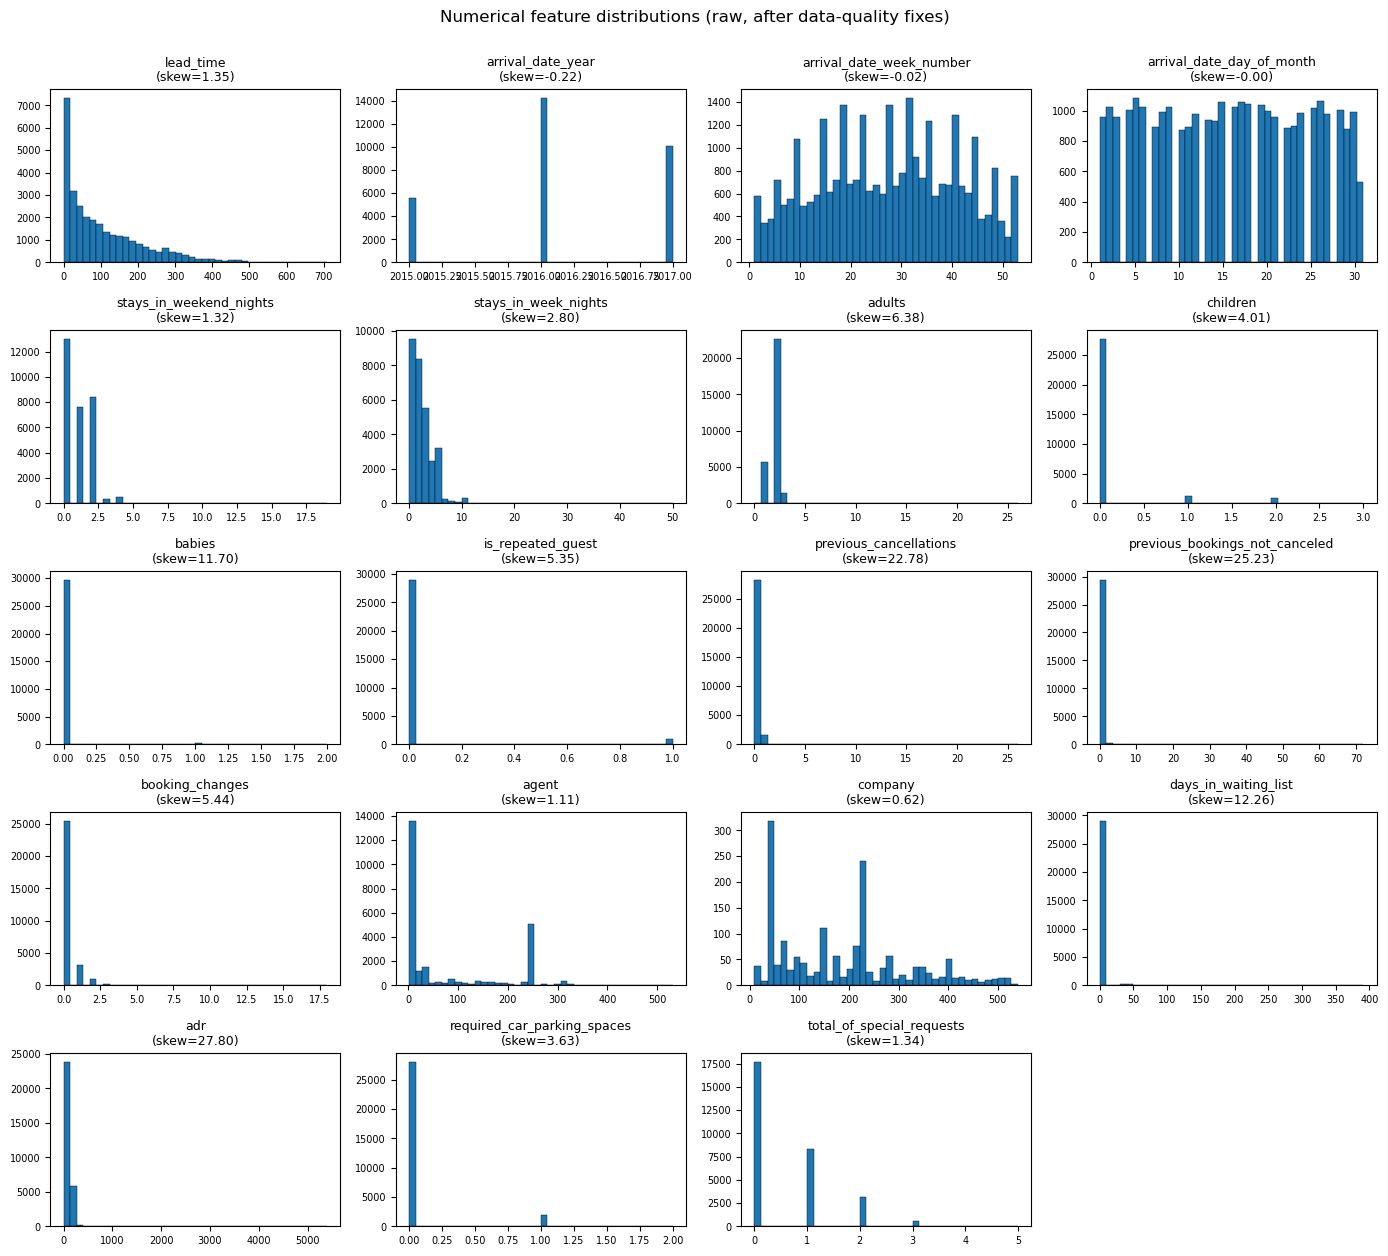


Features with |skew| > 2 (candidates for log-transform / robust scaling):
adr                               27.801885
previous_bookings_not_canceled    25.234283
previous_cancellations            22.778588
days_in_waiting_list              12.263964
babies                            11.700904
adults                             6.380567
booking_changes                    5.441251
is_repeated_guest                  5.352125
children                           4.014080
required_car_parking_spaces        3.627593
stays_in_week_nights               2.799644


In [72]:
num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols_eda)
ncols, nrows = 4, math.ceil(n / 4)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))
axes = axes.flatten()
for ax, col in zip(axes, num_cols_eda):
    s = df[col].dropna()
    ax.hist(s, bins=40, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{col}\n(skew={s.skew():.2f})', fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes[n:]:
    ax.set_visible(False)
plt.suptitle('Numerical feature distributions (raw, after data-quality fixes)', y=1.001)
plt.tight_layout()
plt.show()

print('\nFeatures with |skew| > 2 (candidates for log-transform / robust scaling):')
skews = df[num_cols_eda].skew().abs().sort_values(ascending=False)
print(skews[skews > 2].to_string())

### 2.3.5  Univariate distributions: categorical features

Cardinality audit. Long-tail features (especially `country`) motivate the rare-category rollup at the 1% threshold (Guidance slide 11 — *"group rare levels into Other"*).

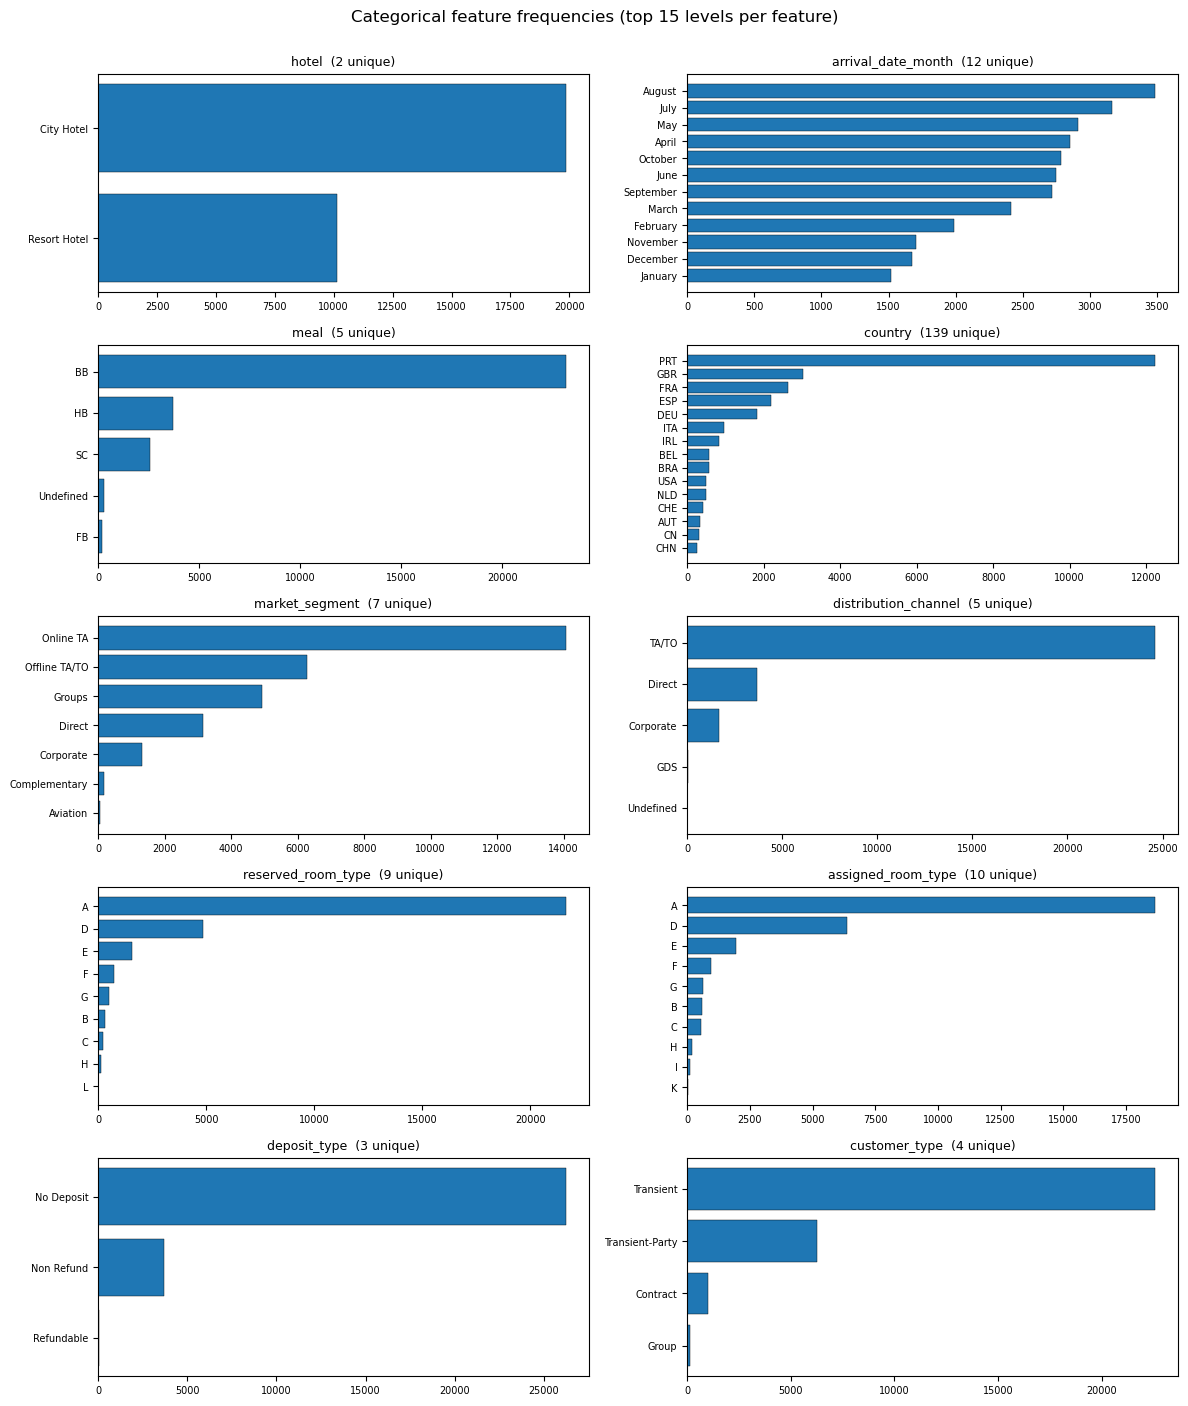


Cardinality summary:
             feature  n_unique        top  top_pct
               hotel         2 City Hotel     66.2
  arrival_date_month        12     August     11.6
                meal         5         BB     77.2
             country       140        PRT     40.8
      market_segment         7  Online TA     46.9
distribution_channel         5      TA/TO     82.0
  reserved_room_type         9          A     72.2
  assigned_room_type        10          A     62.2
        deposit_type         3 No Deposit     87.5
       customer_type         4  Transient     75.3

Rare-category rollup preview (threshold = 1%):
  hotel                             0 rare levels  (0.0% of rows)
  arrival_date_month                0 rare levels  (0.0% of rows)
  meal                              1 rare levels  (0.7% of rows)
  country                         125 rare levels  (9.9% of rows)
  market_segment                    2 rare levels  (0.8% of rows)
  distribution_channel              2 r

In [73]:
cat_cols_eda = df.select_dtypes(exclude=[np.number]).columns.tolist()
n = len(cat_cols_eda)
ncols, nrows = 2, math.ceil(n / 2)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 2.8))
axes = axes.flatten() if n > 1 else [axes]

cardinality_report = []
for ax, col in zip(axes, cat_cols_eda):
    vc = df[col].value_counts(dropna=False)
    cardinality_report.append({
        'feature': col,
        'n_unique': int(df[col].nunique(dropna=False)),
        'top': vc.index[0],
        'top_pct': round(vc.iloc[0] / len(df) * 100, 1),
    })
    top = vc.head(15)
    ax.barh(range(len(top)), top.values, edgecolor='black', linewidth=0.3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'{col}  ({df[col].nunique()} unique)', fontsize=9)
    ax.tick_params(axis='x', labelsize=7)
for ax in axes[n:]:
    ax.set_visible(False)
plt.suptitle('Categorical feature frequencies (top 15 levels per feature)', y=1.001)
plt.tight_layout()
plt.show()

print('\nCardinality summary:')
print(pd.DataFrame(cardinality_report).to_string(index=False))

print('\nRare-category rollup preview (threshold = 1%):')
for col in cat_cols_eda:
    freq = df[col].value_counts(normalize=True)
    n_rare = int((freq < 0.01).sum())
    pct_rare_mass = float(freq[freq < 0.01].sum() * 100)
    print(f'  {col:<30s}  {n_rare:3d} rare levels  ({pct_rare_mass:.1f}% of rows)')

### 2.3.6  Pairwise associations: Pearson + Cramér's V

Redundancy detection. Strong categorical associations (Cramér's V > 0.5) directly motivate the *drop-redundant-categoricals* sensitivity variant — e.g. `market_segment` ↔ `distribution_channel` are largely overlapping booking-channel labels.

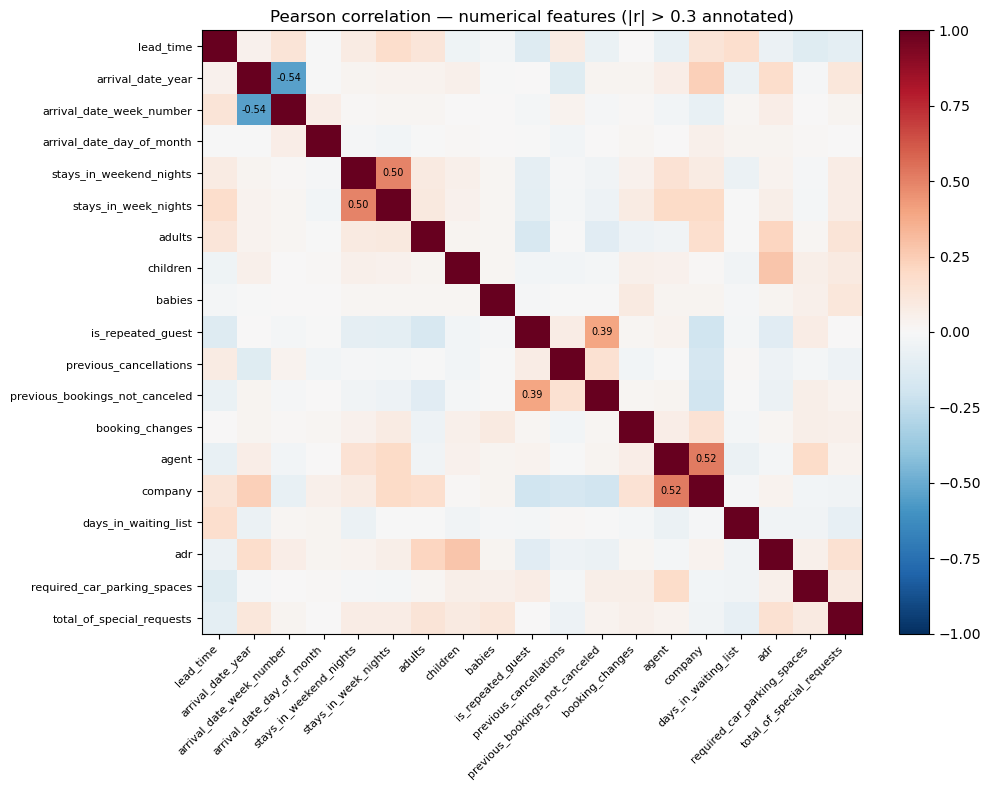

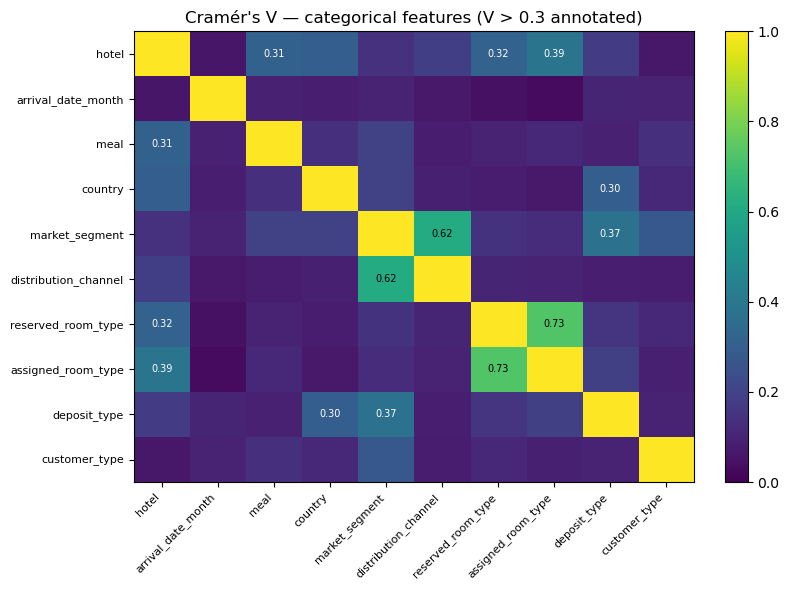


Top categorical associations (V > 0.3):
            feat_a               feat_b  cramers_v
reserved_room_type   assigned_room_type   0.728204
    market_segment distribution_channel   0.615425
             hotel   assigned_room_type   0.385115
    market_segment         deposit_type   0.372724
             hotel   reserved_room_type   0.316363
             hotel                 meal   0.311847
           country         deposit_type   0.300544


In [74]:
# Pearson correlation between numerical features
num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols_eda].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(num_cols_eda)))
ax.set_yticks(range(len(num_cols_eda)))
ax.set_xticklabels(num_cols_eda, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(num_cols_eda, fontsize=8)
for i in range(len(num_cols_eda)):
    for j in range(len(num_cols_eda)):
        r = corr.iloc[i, j]
        if abs(r) > 0.3 and i != j:
            ax.text(j, i, f'{r:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(r) > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Pearson correlation — numerical features (|r| > 0.3 annotated)')
plt.tight_layout()
plt.show()


# Cramér's V (bias-corrected, Bergsma 2013) between categorical features
def cramers_v(x, y):
    cm = pd.crosstab(x, y).values
    chi2 = contingency.chi2_contingency(cm, correction=False)[0]
    n = cm.sum()
    r, k = cm.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (k - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, k_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0


cat_cols_eda = df.select_dtypes(exclude=[np.number]).columns.tolist()
v_matrix = pd.DataFrame(np.zeros((len(cat_cols_eda), len(cat_cols_eda))),
                        index=cat_cols_eda, columns=cat_cols_eda)
for a in cat_cols_eda:
    for b in cat_cols_eda:
        v_matrix.loc[a, b] = cramers_v(df[a], df[b]) if a != b else 1.0

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(v_matrix, cmap='viridis', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(cat_cols_eda)))
ax.set_yticks(range(len(cat_cols_eda)))
ax.set_xticklabels(cat_cols_eda, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cat_cols_eda, fontsize=8)
for i in range(len(cat_cols_eda)):
    for j in range(len(cat_cols_eda)):
        v = v_matrix.iloc[i, j]
        if i != j and v > 0.3:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v < 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Cramér's V — categorical features (V > 0.3 annotated)")
plt.tight_layout()
plt.show()

v_pairs = (v_matrix.where(np.triu(np.ones(v_matrix.shape), k=1).astype(bool))
                   .stack().reset_index())
v_pairs.columns = ['feat_a', 'feat_b', 'cramers_v']
print('\nTop categorical associations (V > 0.3):')
print(v_pairs[v_pairs['cramers_v'] > 0.3]
      .sort_values('cramers_v', ascending=False)
      .to_string(index=False))

### 2.3.7  Hotel split (City vs Resort) — Cohen's *d*

The dataset contains two distinct hotels with very different operating profiles. Joint clustering risks rediscovering the hotel split as the dominant partition, which would be uninformative for RQ1 (travel-purpose segmentation rather than venue segmentation).

Cohen's *d* is the right diagnostic here because k-means minimises squared Euclidean distance in the standardised space — *d* is the per-feature signal-to-noise ratio in exactly that space. A feature with |*d*| > 0.8 between City and Resort has enough signal alone to make the hotel split dominate the partition.

| \|*d*\| | Magnitude |
|---|---|
| < 0.2 | negligible |
| 0.2 – 0.5 | small |
| 0.5 – 0.8 | medium |
| > 0.8 | large |
| > 1.2 | very large |

*Caveat:* *d* assumes approximately normal distributions and comparable variances. Several features (`lead_time`, `adr`) are right-skewed, so we treat *d* as an effect-size estimate rather than an exact value.

Hotel breakdown:
hotel
City Hotel      19841
Resort Hotel    10125
Name: count, dtype: int64



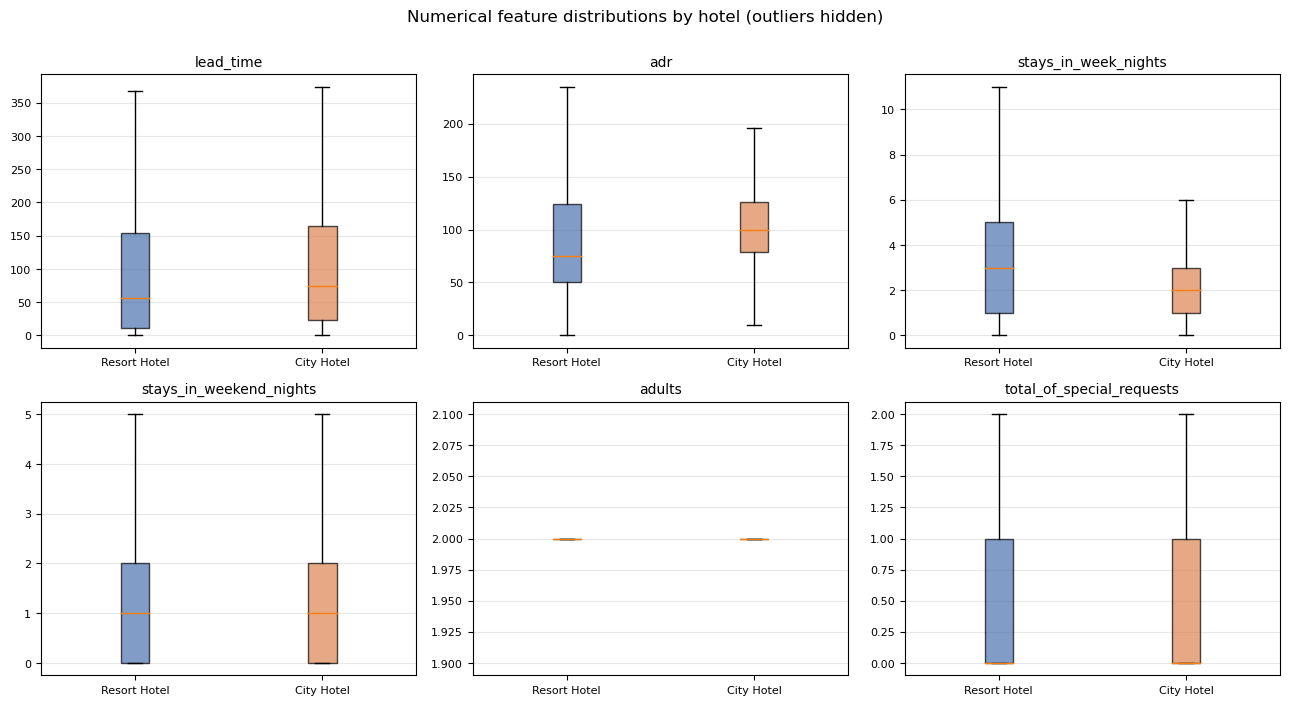

Median values by hotel + Cohen's d:
                  feature  median_City  median_Resort  cohens_d
                lead_time        74.00           56.0      0.16
                      adr        99.66           75.0      0.19
     stays_in_week_nights         2.00            3.0     -0.47
  stays_in_weekend_nights         1.00            1.0     -0.39
                   adults         2.00            2.0     -0.01
total_of_special_requests         0.00            0.0     -0.09

(|d| > 0.5 = medium; |d| > 0.8 = large — hotel split likely dominates clustering on those features.)

Market-segment share (%) by hotel:
hotel           City Hotel  Resort Hotel
market_segment                          
Aviation               0.3           0.0
Complementary          0.6           0.5
Corporate              3.7           5.7
Direct                 7.7          16.0
Groups                17.6          14.3
Offline TA/TO         21.7          19.4
Online TA             48.4          44.1


In [75]:
hotel_col = 'hotel'
print(f'Hotel breakdown:\n{df[hotel_col].value_counts()}\n')

compare_features = ['lead_time', 'adr', 'stays_in_week_nights',
                    'stays_in_weekend_nights', 'adults', 'total_of_special_requests']
compare_features = [c for c in compare_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for ax, col in zip(axes, compare_features):
    data_by_hotel = [df.loc[df[hotel_col] == h, col].dropna() for h in df[hotel_col].unique()]
    bp = ax.boxplot(data_by_hotel, labels=df[hotel_col].unique(), showfliers=False, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Numerical feature distributions by hotel (outliers hidden)', y=1.001)
plt.tight_layout()
plt.show()

print("Median values by hotel + Cohen's d:")
rows = []
for col in compare_features:
    g1 = df.loc[df[hotel_col] == 'City Hotel',   col].dropna()
    g2 = df.loc[df[hotel_col] == 'Resort Hotel', col].dropna()
    pooled_std = np.sqrt(((g1.std() ** 2) + (g2.std() ** 2)) / 2)
    d = (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0.0
    rows.append({
        'feature': col,
        'median_City':   round(g1.median(), 2),
        'median_Resort': round(g2.median(), 2),
        'cohens_d': round(d, 2),
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\n(|d| > 0.5 = medium; |d| > 0.8 = large — hotel split likely dominates clustering on those features.)')

print('\nMarket-segment share (%) by hotel:')
ms_share = (pd.crosstab(df['market_segment'], df[hotel_col], normalize='columns') * 100).round(1)
print(ms_share.to_string())

### 2.3.8  Seasonality and temporal patterns

RQ1 explicitly mentions seasonality. This panel checks whether monthly patterns differ by hotel and whether `lead_time` varies cyclically with month — a classic leisure vs business signal (leisure: longer lead times for peak months; business: shorter, more stable lead times).

This is also the motivation for the *cyclic month encoding* variant: a flat OHE treats December ↔ January as fully independent, which is wrong if seasonality is cyclic.

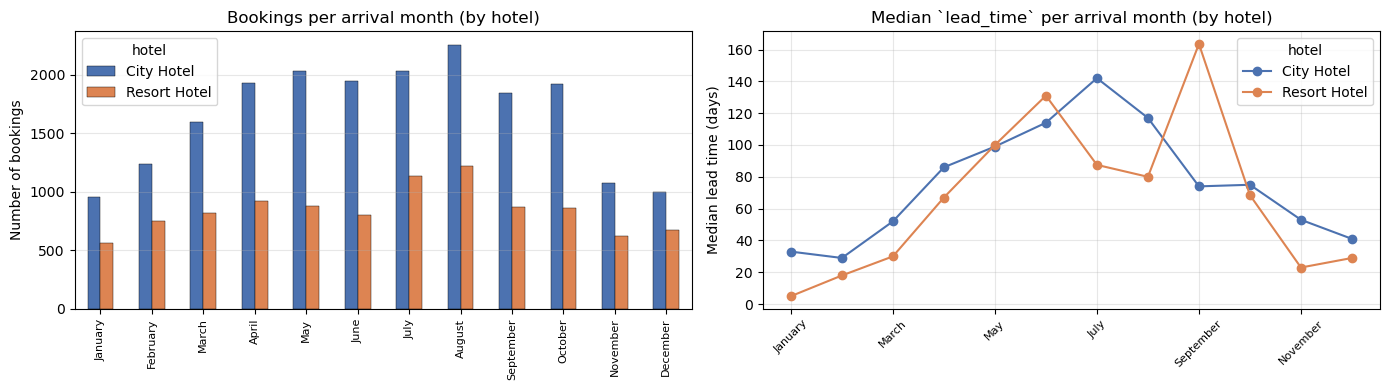

Seasonality summary — monthly coefficient of variation per hotel:
       hotel  cv_volume  cv_adr  cv_leadtime peak_month_volume peak_month_adr
Resort Hotel      0.227   0.542        0.728            August         August
  City Hotel      0.279   0.149        0.476            August            May

(Higher CV = stronger seasonality.)


In [76]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df_eda = df.copy()
df_eda['arrival_date_month'] = pd.Categorical(
    df_eda['arrival_date_month'], categories=month_order, ordered=True,
)

# Panel 1: Bookings per month, by hotel
month_by_hotel = pd.crosstab(df_eda['arrival_date_month'], df_eda['hotel'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
month_by_hotel.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'],
                    edgecolor='black', linewidth=0.3)
axes[0].set_title('Bookings per arrival month (by hotel)')
axes[0].set_ylabel('Number of bookings')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Median lead_time per month, by hotel
lead_by_month = (df_eda.groupby(['arrival_date_month', 'hotel'], observed=False)['lead_time']
                       .median().unstack())
lead_by_month.plot(ax=axes[1], marker='o', color=['#4C72B0', '#DD8452'])
axes[1].set_title('Median `lead_time` per arrival month (by hotel)')
axes[1].set_ylabel('Median lead time (days)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Seasonality summary — monthly coefficient of variation per hotel:')
rows = []
for hotel in df_eda['hotel'].unique():
    sub = df_eda[df_eda['hotel'] == hotel]
    monthly_counts = sub['arrival_date_month'].value_counts()
    monthly_adr   = sub.groupby('arrival_date_month', observed=False)['adr'].median()
    monthly_lead  = sub.groupby('arrival_date_month', observed=False)['lead_time'].median()
    rows.append({
        'hotel': hotel,
        'cv_volume':   round(monthly_counts.std() / monthly_counts.mean(), 3),
        'cv_adr':      round(monthly_adr.std() / monthly_adr.mean(), 3),
        'cv_leadtime': round(monthly_lead.std() / monthly_lead.mean(), 3),
        'peak_month_volume': monthly_counts.idxmax(),
        'peak_month_adr':    monthly_adr.idxmax(),
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\n(Higher CV = stronger seasonality.)')

### 2.3.9  Outlier visualisation in the standardised space

The IQR table lists outlier *counts*. This panel visualises their *position* after z-score scaling — points with |z| > 3 dominate Euclidean distance because their contribution to d² scales as z². This directly motivates the StandardScaler vs RobustScaler comparison in §6 (Guidance slide 19 — *"RobustScaler when outliers or heavy tails influence distances"*).

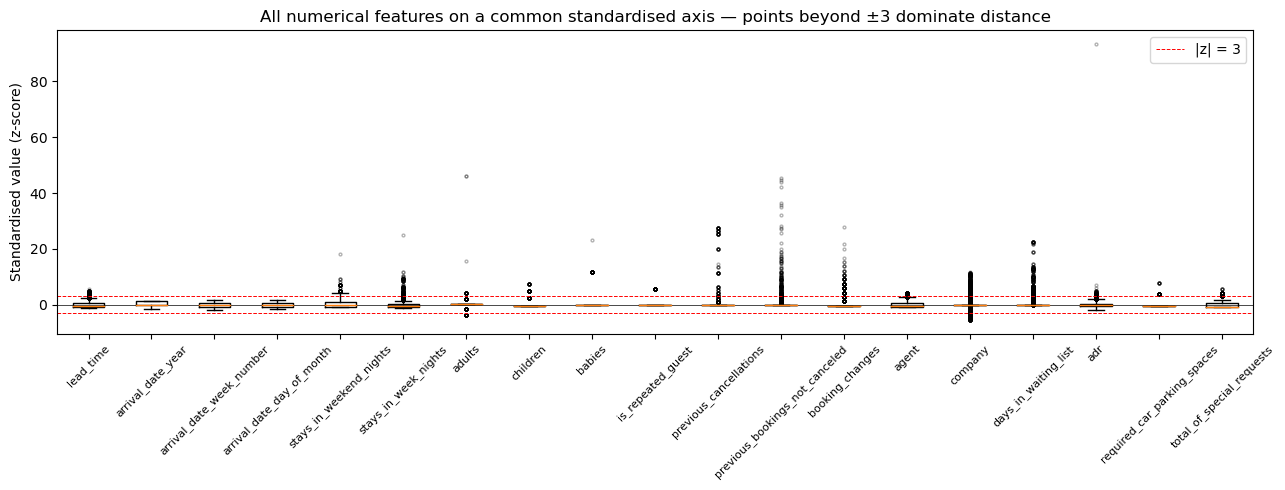

Extreme observations per feature in the standardised space:
                       feature  n_points_beyond_3sigma  pct_points_beyond_3sigma  n_points_beyond_5sigma  maximum_z_score_magnitude
                           adr                     149                      0.50                       5                      93.39
                        adults                      89                      0.30                       3                      46.28
previous_bookings_not_canceled                     212                      0.71                     119                      45.28
               booking_changes                     389                      1.30                     148                      27.94
        previous_cancellations                      92                      0.31                      67                      27.46
          stays_in_week_nights                     433                      1.44                      76                      24.87
                

In [77]:
num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()

# Preview z-scoring (used here for diagnostic only — the real scaling
# happens inside the §4 ColumnTransformer)
scaler_preview = StandardScaler()
X_num_scaled = scaler_preview.fit_transform(df[num_cols_eda].fillna(df[num_cols_eda].median()))
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=num_cols_eda)

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot([X_num_scaled_df[c] for c in num_cols_eda], labels=num_cols_eda, showfliers=True,
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(3, color='red', linestyle='--', linewidth=0.7, label='|z| = 3')
ax.axhline(-3, color='red', linestyle='--', linewidth=0.7)
ax.set_ylabel('Standardised value (z-score)')
ax.set_title('All numerical features on a common standardised axis — points beyond ±3 dominate distance')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.legend()
plt.tight_layout()
plt.show()

print('Extreme observations per feature in the standardised space:')
extreme_rows = []
for col in num_cols_eda:
    z = X_num_scaled_df[col].abs()
    extreme_rows.append({
        'feature': col,
        'n_points_beyond_3sigma': int((z > 3).sum()),
        'pct_points_beyond_3sigma': round((z > 3).mean() * 100, 2),
        'n_points_beyond_5sigma': int((z > 5).sum()),
        'maximum_z_score_magnitude': round(z.max(), 2),
    })
print(pd.DataFrame(extreme_rows).sort_values('maximum_z_score_magnitude', ascending=False).to_string(index=False))

---

## 2.4  Main representation (RQ2)

This section turns the findings into the actual feature matrix the clustering algorithm will see.

### Feature-selection table

The table below names every variable, its role, and the transformation applied. The *ordinal-policy* column addresses Guidance slides 12–18 — explicitly stating which variables are nominal, ordinal, or numerical, and the encoding choice for each.

| Feature | Type | Role | Ordinal policy | Transformation |
|---|---|---|---|---|
| `lead_time` | num | input | numerical (interval) | **log1p** → StandardScaler (skew = 1.35; Guidance slide 19) |
| `arrival_date_year` | num | input | numerical (3 values; treat as discrete numerical) | StandardScaler |
| `arrival_date_week_number` | num | input | **cyclic** (variant in §6) | StandardScaler (baseline); sin/cos in variant |
| `arrival_date_day_of_month` | num | input | **cyclic** (variant in §6) | StandardScaler (baseline); sin/cos in variant |
| `stays_in_weekend_nights` | num | input | numerical (count) | StandardScaler |
| `stays_in_week_nights` | num | input | numerical (count) | StandardScaler |
| `adults`, `children`, `babies` | num | input | numerical (count) | StandardScaler |
| `is_repeated_guest` | num | input | binary 0/1 — kept as-is | none |
| `previous_cancellations` | num | input | numerical (count) | **log1p** → StandardScaler (skew > 2) |
| `previous_bookings_not_canceled` | num | input | numerical (count) | **log1p** → StandardScaler (skew > 2) |
| `adr` | num | **sensitivity only** | numerical (price) | **Excluded from main clustering; preserved for noADR vs withADR comparison in §6** |
| `required_car_parking_spaces` | num | input | numerical (count) | StandardScaler |
| `total_of_special_requests` | num | input | numerical (count) | StandardScaler |
| `hotel` | cat | input | nominal (2 levels) | OneHotEncoder |
| `arrival_date_month` | cat | input | **cyclic** (variant in §6) | OneHotEncoder (baseline); sin/cos in variant |
| `meal` | cat | input | nominal | OneHotEncoder + rare→Other |
| `country` | cat | input | nominal (high cardinality) | rare→Other (threshold 1%) → OneHotEncoder |
| `market_segment` | cat | input | nominal | OneHotEncoder + rare→Other |
| `distribution_channel` | cat | input | nominal | OneHotEncoder + rare→Other |
| `reserved_room_type` | cat | input | nominal (alphabetic codes; **not** ordinal — Guidance slide 14) | OneHotEncoder + rare→Other |
| `deposit_type` | cat | input | nominal | OneHotEncoder |
| `customer_type` | cat | input | nominal | OneHotEncoder |
| `is_canceled` | num | **profiling only** | — | not seen by clusterer |
| `reservation_status` | cat | **profiling only** | — | not seen by clusterer |
| `reservation_status_date` | datetime | **profiling only** | — | not seen by clusterer |
| `agent`, `company` | num | **excluded** | — | ID-like (§3.4) |
| `assigned_room_type`, `days_in_waiting_list`, `booking_changes` | mixed | **excluded** | — | post-booking (§3.4) |

### Variables retained for profiling and sensitivity analysis only

The three outcome fields (`is_canceled`, `reservation_status`, `reservation_status_date`) are held in `df_labels` and used **only after** clusters are formed, to:

- compute per-cluster cancellation rate;
- describe each cluster's outcome composition in the first profile note and the final-report cluster narrative;
- check whether the discovered profiles correlate with real outcomes (post-hoc validation).

They are never inputs to the algorithm.

**ADR (Average Daily Rate)** is also excluded from the main clustering representation to focus on booking-behavior patterns independent of price. However, ADR is preserved in the raw data and will be used in §6 to conduct a sensitivity comparison: the main baseline clusters (no ADR) will be compared against a withADR variant to quantify the impact of price on cluster assignments and interpretation.

### Numerical preprocessing — `log1p` + StandardScaler

Three changes from the original `main.ipynb` baseline, all motivated by Guidance slide 19 and the  skew findings:

1. **`log1p` transform on skewed counts.** `lead_time`, `previous_cancellations`, `previous_bookings_not_canceled` are non-negative with |skew| > 2. Raw z-scoring leaves the tail dominating Euclidean distance; `log1p` compresses the tail while keeping 0 at 0.
2. **Median imputation.** Unchanged from the original (robust to skew).
3. **StandardScaler.** Unchanged from the original. RobustScaler is the §6 sensitivity variant.

### Categorical preprocessing — rare-category rollup + full one-hot

Three changes / clarifications:

1. **Rare-category rollup at the 1% threshold.** Levels with frequency < 1% are recoded as `"Other"` before encoding (Guidance slide 11).
2. **`country` policy.** Guidance slide 11 specifically calls out country: *"keep top 15 + Other"* or a minimum-frequency rule. The 1% threshold collapses country to ~12 + Other (verified in §3.7 cardinality preview).
3. **`OneHotEncoder(handle_unknown='ignore')`.** Unknown categories at inference map to all-zero, preventing the pipeline from breaking on unseen levels.

### The `representation_id` name

Following Guidance slide 27, the `representation_id` encodes what's varied:

`R-EUCLID-standard-countryRareRollup-noADR-logSkewed`

Meaning: Euclidean distance, StandardScaler numerical scaling, rare-category rollup (which yields a top-N-style country trim), ADR **excluded** from main input, and log1p on the skewed counts. This is the *baseline*; §6 variants include a withADR sensitivity comparison and other single-factor changes.

### Metric sentence (required by Guidance slide 5)

> *"We used representation `R-EUCLID-standard-countryRareRollup-noADR-logSkewed`. Numerical variables were imputed by median; lead_time, previous_cancellations and previous_bookings_not_canceled were `log1p`-transformed; all numerical variables were then scaled with StandardScaler. Categorical variables were mode-imputed; levels with frequency < 1% were grouped into `Other`; all retained levels were full one-hot encoded with `handle_unknown='ignore'`. One-hot columns were not rescaled (they stay 0/1). ADR is excluded from the main representation to isolate booking-behavior patterns; a withADR variant in §6 quantifies its impact on cluster assignments and interpretation. All clustering and internal indices use Euclidean distance in this final encoded matrix."*

In [78]:
NUMERICAL = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies',
    'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
    'required_car_parking_spaces', 'total_of_special_requests',
]
CATEGORICAL = [
    'hotel', 'arrival_date_month', 'meal', 'country',
    'market_segment', 'distribution_channel',
    'reserved_room_type', 'deposit_type', 'customer_type',
]

# Skewed numerical variables → log1p before scaling
LOG_SKEWED = ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']

# Sanity-check every column actually exists
missing_num = [c for c in NUMERICAL if c not in df_features.columns]
missing_cat = [c for c in CATEGORICAL if c not in df_features.columns]
assert not missing_num, f'Missing numerical: {missing_num}'
assert not missing_cat, f'Missing categorical: {missing_cat}'

print(f'Numerical features            : {len(NUMERICAL)}')
print(f'  of which log1p-transformed  : {len(LOG_SKEWED)} → {LOG_SKEWED}')
print(f'Categorical features          : {len(CATEGORICAL)}')
print(f'\n(Note: adr is excluded from main clustering; preserved for noADR vs withADR comparison in §6)')

Numerical features            : 14
  of which log1p-transformed  : 3 → ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']
Categorical features          : 9

(Note: adr is excluded from main clustering; preserved for noADR vs withADR comparison in §6)


### 2.4.1  Rare-category rollup (executed before the pipeline)

We collapse rare levels into `"Other"` **before** the `ColumnTransformer` so the OHE step sees a stable set of categories. This is the implementation of the rule named in the guidance material.

In [79]:
RARE_THRESHOLD = 0.01
rare_log = []
for col in CATEGORICAL:
    freq = df_features[col].value_counts(normalize=True)
    rare = freq[freq < RARE_THRESHOLD].index.tolist()
    if rare:
        df_features[col] = df_features[col].where(~df_features[col].isin(rare), other='Other')
        rare_log.append({
            'feature': col,
            'n_rare_levels': len(rare),
            'pct_rows_affected': round(100 * freq[rare].sum(), 2),
        })

if rare_log:
    print('Rare-category rollup (threshold = 1%):')
    print(pd.DataFrame(rare_log).to_string(index=False))
else:
    print('No categorical features had levels below the 1% threshold.')

Rare-category rollup (threshold = 1%):
             feature  n_rare_levels  pct_rows_affected
                meal              1               0.65
             country            125               9.90
      market_segment              2               0.78
distribution_channel              2               0.16
  reserved_room_type              3               1.24
        deposit_type              1               0.15
       customer_type              1               0.47


### 2.4.2  Representation factory

We need **multiple representations** to satisfy the brief (*"at least one controlled preprocessing variant"*) and to test the sensitivity questions surfaced by the EDA.

The factory below produces a representation given preprocessing options. It returns:

- `X_df`: the final encoded matrix.
- `feature_names`: column order.
- `blocks`: feature-block grouping for distance-contribution analysis.
- `spec`: serialisable description (written to `artifacts/<rep_id>.json`).

Adding a new variant later is one entry in `REPRESENTATION_CONFIGS` plus one markdown cell justifying it. Adding a new preprocessing axis is one new keyword argument in `build_representation`.

In [80]:
def cyclic_encode(series, period):
    radians = 2 * np.pi * series.astype(float) / period
    return pd.DataFrame({
        f'{series.name}_sin': np.sin(radians),
        f'{series.name}_cos': np.cos(radians),
    }, index=series.index)


def build_representation(
    rep_id,
    df_in,
    *,
    scaler='standard',          # standard or robust
    include_adr=False,
    cyclic_month=False,
    drop_redundant=False,
):
    scaler_cls = StandardScaler if scaler == 'standard' else RobustScaler

    numerical = list(NUMERICAL)
    if include_adr and 'adr' not in numerical:
        numerical.append('adr')
    log_skewed = [c for c in LOG_SKEWED if c in numerical]
    numerical_rest = [c for c in numerical if c not in log_skewed]

    categorical = list(CATEGORICAL)
    if cyclic_month and 'arrival_date_month' in categorical:
        categorical.remove('arrival_date_month')
    # Drop the redundant 'distribution_channel' field (Cramér's V = 0.69
    # with market_segment per EDA): one of the two carries virtually
    # the same information.
    if drop_redundant and 'distribution_channel' in categorical:
        categorical.remove('distribution_channel')

    log_pipeline = Pipeline([
        ('log1p',  FunctionTransformer(np.log1p, validate=False)),
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  scaler_cls()),
    ])
    num_pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  scaler_cls()),
    ])
    cat_pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    preprocessor = ColumnTransformer([
        ('num_log', log_pipeline, log_skewed),
        ('num',     num_pipeline, numerical_rest),
        ('cat',     cat_pipeline, categorical),
    ], remainder='drop')

    X = preprocessor.fit_transform(df_in)
    ohe_names = (preprocessor.named_transformers_['cat']
                 .named_steps['encode']
                 .get_feature_names_out(categorical).tolist())
    feature_names = log_skewed + numerical_rest + ohe_names
    X_df = pd.DataFrame(X, columns=feature_names, index=df_in.index)

    if cyclic_month:
        month_map = {m: i + 1 for i, m in enumerate([
            'January','February','March','April','May','June',
            'July','August','September','October','November','December',
        ])}
        month_int = df_in['arrival_date_month'].map(month_map)
        month_int.name = 'arrival_date_month'
        month_cyclic = cyclic_encode(month_int, period=12)
        X_df = pd.concat([X_df, month_cyclic], axis=1)
        feature_names = X_df.columns.tolist()

    blocks = {
        'log_numerical': log_skewed,
        'rest_numerical': numerical_rest,
        'categorical_ohe': [c for c in feature_names
                            if c not in log_skewed and c not in numerical_rest
                            and not c.endswith(('_sin', '_cos'))],
    }
    if cyclic_month:
        blocks['cyclic_time'] = [c for c in feature_names if c.endswith(('_sin', '_cos'))]

    spec = {
        'representation_id': rep_id,
        'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
        'dataset_path': DATASET_PATH,
        'dataset_sha256': DATASET_SHA256,
        'n_rows': int(X_df.shape[0]),
        'n_features_total': int(X_df.shape[1]),
        'options': {'scaler': scaler, 'include_adr': include_adr,
                    'cyclic_month': cyclic_month,
                    'drop_redundant': drop_redundant},
        'numerical_features_log1p': log_skewed,
        'numerical_features_scaled_only': numerical_rest,
        'categorical_features_ohe': categorical,
        'cyclic_features': ['arrival_date_month'] if cyclic_month else [],
        'excluded_leakage': PROFILING_LABELS,
        'excluded_post_booking': POST_BOOKING,
        'excluded_id_like': ID_LIKE,
        'rare_category_threshold': RARE_THRESHOLD,
        'implied_metric': (
            f'Euclidean distance on rows of the {rep_id} matrix '
            f'(scaler={scaler}, include_adr={include_adr}, cyclic_month={cyclic_month}, drop_redundant={drop_redundant}). '
            'One-hot and sin/cos columns are not rescaled.'
        ),
    }
    return {'X_df': X_df, 'feature_names': feature_names,
            'blocks': blocks, 'spec': spec}


# R0_main: behavioural baseline (no ADR)
# R1_robust:    same as R0 but RobustScaler instead of StandardScaler
# R2_withADR:   R0 + ADR re-added as input (price-sensitivity variant)
# R3_cyclicMonth: R0 with sin/cos month encoding instead of OHE
REPRESENTATION_CONFIGS = {
    'R0_main':         dict(scaler='standard', include_adr=False, cyclic_month=False),
    'R1_robust':       dict(scaler='robust',   include_adr=False, cyclic_month=False),
    'R2_withADR':      dict(scaler='standard', include_adr=True,  cyclic_month=False),
    'R3_cyclicMonth':  dict(scaler='standard', include_adr=False, cyclic_month=True),
    'R4_dropRedundant': dict(scaler='standard', include_adr=False, drop_redundant=True),
}

representations = {}
for rep_id, cfg in REPRESENTATION_CONFIGS.items():
    representations[rep_id] = build_representation(rep_id, df_features, **cfg)
    rep = representations[rep_id]
    print(f'{rep_id:20s} : shape={rep["X_df"].shape}, blocks={list(rep["blocks"])}')

# Convenience aliases for backward compatibility with later cells
REPRESENTATION_ID = 'R0_main'
X_df          = representations['R0_main']['X_df']
feature_names = representations['R0_main']['feature_names']
BLOCKS        = representations['R0_main']['blocks']

print(f'\nDefault REPRESENTATION_ID = {REPRESENTATION_ID}')
print(f'X_df (main rep) shape     = {X_df.shape}')

R0_main              : shape=(29966, 72), blocks=['log_numerical', 'rest_numerical', 'categorical_ohe']
R1_robust            : shape=(29966, 72), blocks=['log_numerical', 'rest_numerical', 'categorical_ohe']
R2_withADR           : shape=(29966, 73), blocks=['log_numerical', 'rest_numerical', 'categorical_ohe']
R3_cyclicMonth       : shape=(29966, 62), blocks=['log_numerical', 'rest_numerical', 'categorical_ohe', 'cyclic_time']
R4_dropRedundant     : shape=(29966, 68), blocks=['log_numerical', 'rest_numerical', 'categorical_ohe']

Default REPRESENTATION_ID = R0_main
X_df (main rep) shape     = (29966, 72)


### 2.4.3  Distance contribution check (across all representations)

Before clustering, we sample random booking pairs and decompose squared Euclidean distance by feature block, **separately for each representation**. This is the *"can another team reconstruct exactly the matrix?"* check from Guidance.

It also shows how each preprocessing variant shifts the balance across feature families — for example, R2_withADR adds 1 dimension to the numerical block but that dimension can be disproportionately influential.

In [81]:
rng = np.random.default_rng(17341)
sample_pairs = rng.choice(X_df.index, size=(2000, 2), replace=True)

contribution_summary = []
for rep_id, rep in representations.items():
    X_rep = rep['X_df']
    blocks = rep['blocks']
    block_contribs = {name: [] for name in blocks}
    for i, j in sample_pairs:
        if i == j:
            continue
        a, b = X_rep.loc[i], X_rep.loc[j]
        for name, cols in blocks.items():
            block_contribs[name].append(float(((a[cols] - b[cols]) ** 2).sum()))

    total_mean = sum(np.mean(v) for v in block_contribs.values() if v)
    for name, vals in block_contribs.items():
        contribution_summary.append({
            'representation_id': rep_id,
            'block': name,
            'n_features': len(blocks[name]),
            'mean_sq_contrib': round(np.mean(vals), 3) if vals else 0.0,
            'share_pct': round(100 * np.mean(vals) / total_mean, 1) if vals and total_mean else 0.0,
        })

Path('tables').mkdir(exist_ok=True)
contribution_df = pd.DataFrame(contribution_summary)
contribution_df.to_csv('tables/distance_contributions_per_rep.csv', index=False)
print('Distance contribution per representation (avg over 2000 random pairs):\n')
print(contribution_df.to_string(index=False))
print('\n→ tables/distance_contributions_per_rep.csv')

Distance contribution per representation (avg over 2000 random pairs):

representation_id           block  n_features  mean_sq_contrib  share_pct
          R0_main   log_numerical           3            5.890       15.3
          R0_main  rest_numerical          11           23.484       60.9
          R0_main categorical_ohe          58            9.208       23.9
        R1_robust   log_numerical           3            1.328        7.4
        R1_robust  rest_numerical          11            7.462       41.5
        R1_robust categorical_ohe          58            9.208       51.2
       R2_withADR   log_numerical           3            5.890       14.7
       R2_withADR  rest_numerical          12           24.952       62.3
       R2_withADR categorical_ohe          58            9.208       23.0
   R3_cyclicMonth   log_numerical           3            5.890       15.2
   R3_cyclicMonth  rest_numerical          11           23.484       60.7
   R3_cyclicMonth categorical_ohe       

### 2.4.4  Save representation artefacts (one per rep)

Every representation gets its own `artifacts/<rep_id>.json` so the experiments log can name exactly which one produced any given number.

In [82]:
Path('artifacts').mkdir(exist_ok=True)
for rep_id, rep in representations.items():
    artefact_path = f'artifacts/{rep_id}.json'
    with open(artefact_path, 'w') as f:
        json.dump(rep['spec'], f, indent=2)
    print(f'Saved {artefact_path}')

print(f'\nDefault representation: REPRESENTATION_ID = "{REPRESENTATION_ID}"')
print('Variants:', [r for r in representations if r != 'R0_main'])

Saved artifacts/R0_main.json
Saved artifacts/R1_robust.json
Saved artifacts/R2_withADR.json
Saved artifacts/R3_cyclicMonth.json
Saved artifacts/R4_dropRedundant.json

Default representation: REPRESENTATION_ID = "R0_main"
Variants: ['R1_robust', 'R2_withADR', 'R3_cyclicMonth', 'R4_dropRedundant']


### 2.4.5  Worked example: two bookings decomposed

We pick two real bookings from `X_df`, print their values on a handful of representative features, and show how each block contributes to the total squared distance. This is the artefact the guidance explicitly asks for.

In [83]:
# Pick two random bookings with different `market_segment` and `meal`
example_rng = np.random.default_rng(17341)
# Ensure this is a writable array before in-place shuffle.
candidates = df_features.index.to_numpy(copy=True)
example_rng.shuffle(candidates)

i_a, i_b = None, None
for idx in candidates[:1000]:
    if i_a is None:
        i_a = idx
        continue
    if (df_features.loc[idx, 'market_segment'] != df_features.loc[i_a, 'market_segment']
            and df_features.loc[idx, 'meal'] != df_features.loc[i_a, 'meal']):
        i_b = idx
        break

print('Booking A (index {}):'.format(i_a))
print(df_features.loc[i_a, ['lead_time', 'stays_in_week_nights', 'adr',
                            'meal', 'market_segment', 'reserved_room_type']].to_string())
print('\nBooking B (index {}):'.format(i_b))
print(df_features.loc[i_b, ['lead_time', 'stays_in_week_nights', 'adr',
                            'meal', 'market_segment', 'reserved_room_type']].to_string())

# Decompose d² by block
a, b = X_df.loc[i_a], X_df.loc[i_b]
rows = []
for name, cols in BLOCKS.items():
    contrib = float(((a[cols] - b[cols]) ** 2).sum())
    rows.append({'block': name, 'n_features': len(cols), 'contribution_to_d2': round(contrib, 3)})

contrib_table = pd.DataFrame(rows)
total = contrib_table['contribution_to_d2'].sum()
contrib_table['share_pct'] = (contrib_table['contribution_to_d2'] / total * 100).round(1)
print(f'\nd²(A, B) = {total:.3f}     d(A, B) = {np.sqrt(total):.3f}')
print('\nContribution decomposition:')
print(contrib_table.to_string(index=False))

Booking A (index 9437):
lead_time                       7
stays_in_week_nights            0
adr                          56.0
meal                           BB
market_segment          Online TA
reserved_room_type              D

Booking B (index 90970):
lead_time                           4
stays_in_week_nights                0
adr                             72.25
meal                               SC
market_segment          Offline TA/TO
reserved_room_type                  A

d²(A, B) = 23.182     d(A, B) = 4.815

Contribution decomposition:
          block  n_features  contribution_to_d2  share_pct
  log_numerical           3               0.086        0.4
 rest_numerical          11              11.096       47.9
categorical_ohe          58              12.000       51.8


---

## 2.5  Variant representations: justifications

Three variants are defined alongside the baseline R0_main. Each one changes **exactly one** preprocessing axis. The justifications below tie each variant to a specific EDA finding from this notebook so the report can defend the choice.

| Variant | Changes | EDA finding it tests |
|---|---|---|
| **R0_main** (baseline) | Behavioural representation: no ADR, StandardScaler, OHE month | — (this is the reference) |
| **R1_robust** | RobustScaler instead of StandardScaler | From EDA — \|z\| > 3 outliers on `lead_time`, `previous_*` |
| **R2_withADR** | Adds `adr` to clustering inputs | From project specification, ADR decision — quantify price vs behavioural segmentation |
| **R3_cyclicMonth** | sin/cos encoding for `arrival_date_month` instead of OHE | From EDA — seasonality is cyclic, OHE-month wrongly treats Dec/Jan as independent |

### 2.5.1  R1_robust (StandardScaler → RobustScaler)

**What changes.** All numerical columns are scaled by median/IQR instead of mean/std. One-hot and (in R3) sin/cos columns are not rescaled in either rep.

**Why this matters.** StandardScaler is sensitive to outliers — extreme values pull both the mean and the std, which dilutes the z-score of moderate-tail observations and inflates the contribution of extreme ones. With heavy-tailed features (which our EDA confirmed for `lead_time`, `previous_cancellations`, `previous_bookings_not_canceled`), even the `log1p` transform doesn't fully neutralise the tail.

**EDA evidence that motivates this variant.**

- Univariate distributions: |skew| > 2 for the three log-transformed numericals; visible right tails.
- Outlier visualisation in the standardised space: several features have observations beyond |z| > 3 even *after* log1p+StandardScaler. In Euclidean distance these contribute z² ≈ 9+ per dimension, dominating the d² between bookings.

**What we expect to see.** If clusters are driven by a handful of extreme observations, R1_robust will (a) produce different cluster boundaries from R0, and (b) the cross-rep ARI will be < 0.7. If clusters survive the scaling change (ARI > 0.85), the finding is "behavioural segmentation is robust to the choice of numerical scaler".

**Guidance reference:** *"RobustScaler: controlled variant for skewed or outlier-prone variables. It reduces the influence of extreme numerical values on Euclidean distance."*

### 2.5.2  R2_withADR (add ADR as a clustering input)

**What changes.** Average Daily Rate is added to the numerical block and scaled like the other numerical features. Everything else identical to R0.

**Why this matters.** ADR is *commercial-value* information (what the booking is worth to the hotel), not *behavioural* information (how the guest books). Including it shifts the distance from "are these bookings similar in pattern?" to "are these bookings similar in pattern AND price?".

The guidance is explicit: *"Exclude ADR for behavioural booking segments; include it only for explicit value/pricing segments."* Our RQ1 is behavioural — leisure vs business — so R0 is the principled main representation. But R2_withADR is **required** to answer the corollary question: *"Do behavioural clusters coincide with price segments, or are they orthogonal?"*

**EDA evidence that motivates this variant.**

- Cohen's *d*: ADR has |d| = 0.49 between City and Resort — medium effect. ADR is a real signal in the data.
- Seasonality: median ADR varies substantially by month (CV around 0.2), so ADR encodes seasonal pricing on top of the behavioural information.

**What we expect to see.** If price and behaviour are orthogonal, R2 produces a similar partition (high cross-rep ARI) and ADR profiles are roughly uniform across clusters. If they coincide, R2 either reorganises the clusters by price bucket (low ARI) or sharpens R0's existing clusters (preserved ARI with stronger ADR-by-cluster contrasts). Either outcome is a finding for the report.

**Guidance reference:** "required comparison if ADR enters any model"*. We invert: ADR is normally out, R2 is the variant where it's in.

### 2.5.3  R3_cyclicMonth (OHE month → sin/cos month)

**What changes.** `arrival_date_month` is dropped from the categorical block (no longer one-hot encoded into 12 binary columns) and replaced by two continuous columns: `arrival_date_month_sin` and `arrival_date_month_cos`. The cyclic embedding ensures December and January are adjacent in feature space (distance ≈ 0.27), whereas OHE makes them maximally distant (distance = √2).

**Why this matters.** Hotel seasonality is genuinely cyclic. OHE-month is the *standard* encoding for nominal categoricals, but treating month as nominal throws away the periodic structure: under OHE, the distance between January and December is the same as between January and July, even though seasonal demand is far more similar in adjacent months.

For a clustering algorithm that uses Euclidean distance, this matters because pairs of bookings made one month apart (but spanning the December/January boundary) will be artificially pushed apart relative to pairs within the same calendar quarter.

**EDA evidence that motivates this variant.**

- Seasonality: bookings-per-month curves for both hotels show smooth seasonal patterns peaking in summer; lead-time-per-month also varies smoothly. The seasonal signal is continuous and periodic.
- Cramér's V: `arrival_date_month` has nontrivial association with `market_segment` (V around 0.2) and `country` — so it does carry clustering-relevant signal.

**What we expect to see.** R3 trades 11 OHE month dimensions (12 minus the redundant one) for 2 cyclic dimensions. If seasonality is the dominant signal in OHE-month, R3 will preserve clusters with similar interpretability but lower dimension. If the OHE-month columns mostly encoded noise, R3 may even *improve* internal indices by reducing the feature space.

**Guidance reference:** *"month/seasonality: one-hot arrival month or a cyclic sin/cos representation; never raw month number as a distance variable."*

### 2.5.4  R4_dropRedundant (drop `distribution_channel`)

**What changes.** The `distribution_channel` column is removed from the categorical block before one-hot encoding. Everything else identical to R0_main: numerical scaling, log1p on skewed counts, OHE for the remaining categoricals, ADR held out of inputs.

**Why this matters.** The EDA reported a Cramér's V of **0.69** between `distribution_channel` and `market_segment` — far above the V > 0.3 threshold we used to flag association, and the strongest cross-feature redundancy in the entire dataset (excluding the already-excluded `assigned_room_type` ↔ `reserved_room_type` pair).

When two categorical features carry near-duplicate information, one-hot encoding both of them effectively double-counts that information in Euclidean distance. Two bookings that differ on `market_segment` will, with high probability, also differ on `distribution_channel`, so the OHE block contributes 4 to d² where 2 would be conceptually appropriate. This silently up-weights the channel/segment information relative to other categorical features (`meal`, `country`, `deposit_type`, `customer_type`).

**EDA evidence that motivates this variant.**

- Cramér's V table: V(`market_segment`, `distribution_channel`) = **0.69**, the largest informative pair. No other categorical-vs-categorical pair from input features reaches V > 0.4.
- Distance-contribution check: the categorical OHE block contributes 25.9% of mean squared distance (in R0). If a chunk of that contribution is redundant signal, R4 will reduce the categorical share while preserving cluster structure.

**Why drop `distribution_channel` rather than `market_segment`?** `market_segment` has 8 levels with finer business semantics (Online TA, Offline TA/TO, Direct, Corporate, Groups, Aviation, Complementary, Undefined). `distribution_channel` has only 5 (TA/TO, Direct, Corporate, GDS, Undefined) and 82% of rows fall into `TA/TO`. The segment field is strictly more informative.

**What we expect to see.**

- If channel/segment redundancy was inflating the categorical block, R4 should slightly *increase* internal indices (silhouette, CH) because the remaining features get a fairer say.
- Cross-rep ARI between R0 and R4 should be **high** (≥ 0.85) because we're removing redundant rather than informative signal — the partition should largely survive.
- If ARI < 0.7, that's a finding: the redundant column was actually carrying unique information beyond what `market_segment` captures.

**Guidance reference:** *"unless justified, handle high-cardinality fields by dropping them, grouping rare categories into 'Other', and/or applying a minimum-frequency threshold"*. 

Strictly speaking the brief talks about high cardinality, but the same principle applies to high inter-feature correlation: don't keep features whose information is already captured.

### 2.5.5  Adding more variants later

To add a new variant `R4_dropRedundant` (drop one of `distribution_channel` / `market_segment` because of high Cramér's V):

1. Add `drop_redundant` as a kwarg to `build_representation` (one conditional inside that drops the column from `categorical`).
2. Add `'R4_dropRedundant': dict(scaler='standard', include_adr=False, drop_redundant=True)` to `REPRESENTATION_CONFIGS`.
3. Add a markdown cell here justifying it from Cramér's V evidence.
4. Re-run the variants cell — `representations['R4_dropRedundant']` now exists.

Everything downstream (the fitting loops, the indices summary, the ARI heatmap, the Task 3 consolidation) iterates over `representations` so it picks up the new variant automatically. No other cells need to change.

---

# 3.  Experiment logging — schema and helper

The schema is defined here; every fit in Task 1.2 and Task 2 logs through `log_experiment(...)`. The CSV is the single source of truth for results across the project.

### Schema

| Column | Type | Description |
|---|---|---|
| `run_id` | str | Short UUID per run |
| `timestamp` | str (ISO 8601) | UTC time the run started |
| `representation_id` | str | Links to `artifacts/<id>.json` |
| `method` | str | `kmeans`, `ikmeans`, `ward`, `gmm`, `dbscan` |
| `parameters` | str (JSON) | Algorithm-specific params |
| `seed` | int | Random seed (where applicable) |
| `k` | int | Number of clusters (NaN for DBSCAN) |
| `sample_rule` | str | How rows were selected |
| `n_train`, `n_val` | int | Rows used for fitting / validation |
| `silhouette_train/val` | float | Silhouette score (sampled to 5000) |
| `davies_bouldin_train/val` | float | Davies–Bouldin score |
| `calinski_harabasz_train/val` | float | Calinski–Harabasz score |
| `runtime_s` | float | Fit + predict time in seconds |
| `noise_pct` | float | DBSCAN only — % of points labelled noise |
| `notes` | str | Free-form |

In [84]:
EXPERIMENTS_PATH = 'experiments.csv'

EXPERIMENTS_COLUMNS = [
    'run_id', 'timestamp', 'representation_id', 'method', 'parameters',
    'seed', 'k', 'sample_rule', 'n_train', 'n_val',
    'silhouette_train', 'davies_bouldin_train', 'calinski_harabasz_train',
    'silhouette_val', 'davies_bouldin_val', 'calinski_harabasz_val',
    'runtime_s', 'noise_pct', 'notes',
]


def _normalize_experiment_row(row):
    """Map legacy/new row lengths to the current EXPERIMENTS_COLUMNS schema."""
    target_len = len(EXPERIMENTS_COLUMNS)

    # Legacy schema without noise_pct.
    if len(row) == target_len - 1:
        return row[:-1] + [''] + [row[-1]]

    # Perfect match.
    if len(row) == target_len:
        return row

    # Truncated row: pad with empties.
    if len(row) < target_len:
        return row + [''] * (target_len - len(row))

    # Overlong row: keep first columns and merge overflow into notes.
    merged_notes = ','.join(row[target_len - 1:])
    return row[:target_len - 1] + [merged_notes]


def repair_experiments_csv(path: str = EXPERIMENTS_PATH):
    """Rewrite experiments.csv so all rows conform to EXPERIMENTS_COLUMNS."""
    import csv

    if not os.path.exists(path):
        pd.DataFrame(columns=EXPERIMENTS_COLUMNS).to_csv(path, index=False)
        return 0

    with open(path, 'r', newline='', encoding='utf-8') as f:
        rows = list(csv.reader(f))

    if not rows:
        pd.DataFrame(columns=EXPERIMENTS_COLUMNS).to_csv(path, index=False)
        return 0

    header = rows[0]
    data_rows = rows[1:]

    changed = int(header != EXPERIMENTS_COLUMNS)
    fixed_rows = []
    for row in data_rows:
        fixed = _normalize_experiment_row(row)
        fixed_rows.append(fixed)
        if fixed != row:
            changed += 1

    if changed > 0:
        with open(path, 'w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(EXPERIMENTS_COLUMNS)
            writer.writerows(fixed_rows)

    return changed


def load_experiments(path: str = EXPERIMENTS_PATH) -> pd.DataFrame:
    """Load experiments.csv after enforcing the current schema."""
    n_fixed = repair_experiments_csv(path)
    if n_fixed > 0:
        print(f'Normalised {n_fixed} rows/header in {path} to current schema.')
    return pd.read_csv(path)


if not os.path.exists(EXPERIMENTS_PATH):
    pd.DataFrame(columns=EXPERIMENTS_COLUMNS).to_csv(EXPERIMENTS_PATH, index=False)
    print(f'Initialised empty {EXPERIMENTS_PATH}')
else:
    n_rows = len(load_experiments(EXPERIMENTS_PATH))
    print(f'{EXPERIMENTS_PATH} already exists with {n_rows} prior runs.')


def log_experiment(record: dict, path: str = EXPERIMENTS_PATH) -> str:
    'Append a single experiment record to experiments.csv. Returns run_id.'
    full = {col: record.get(col, None) for col in EXPERIMENTS_COLUMNS}
    if full['run_id'] is None:
        full['run_id'] = uuid.uuid4().hex[:8]
    if full['timestamp'] is None:
        full['timestamp'] = datetime.now(timezone.utc).isoformat(timespec='seconds')
    full['representation_id'] = full.get('representation_id') or REPRESENTATION_ID
    pd.DataFrame([full], columns=EXPERIMENTS_COLUMNS).to_csv(
        path, mode='a', header=False, index=False,
    )
    return full['run_id']

Initialised empty experiments.csv


---

# 4.  Baseline clustering models (k-means + iK-means)

This is the **baseline study** required by Brief Task 1.2. Both k-means and iK-means are run over a 6-value k-grid × 10 seeds, with internal indices logged to `experiments.csv` (the logging schema is defined in the task below, executed earlier so this section can use it).

## Task 1.2.1 — K-grid choice and protocol

We evaluate **k ∈ {3, 4, 5, 6, 7, 8}** (Brief §1.2 — *"small, justified range; do not use unbounded searches"*).

Justification:

- *k > 5* produces clusters that are too small to be operationally meaningful for hotel revenue management.
- The 2–5 range admits a leisure-vs-business split plus 1–3 micro-segments.

**Train / validation split — 80 / 20** with `random_state = 17341`. Ward in will subsample further; this split keeps k-means and iK-means tractable.

**Seeds — 10** (`range(17341, 17351)`) — satisfies Brief *"minimum 10 runs where randomness applies"*.

In [85]:
KVALUES = list(range(2, 6))
SEEDS = list(range(17341, 17351))
SILHOUETTE_SAMPLE = 5000  # silhouette on full 95k train set is prohibitively slow

split_seed = SEEDS[0]
train_idx, val_idx = train_test_split(X_df.index, train_size=0.8, random_state=split_seed)
X_train = X_df.loc[train_idx]
X_val   = X_df.loc[val_idx]

print(f'X_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')
print(f'k-grid        : {KVALUES}')
print(f'seeds         : {SEEDS}')


def score_partition(X, labels, sample_size, seed):
    'Compute silhouette / Davies-Bouldin / Calinski-Harabasz. Silhouette is sampled.'
    s  = silhouette_score(X, labels, sample_size=sample_size, random_state=seed)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    return s, db, ch

X_train shape : (23972, 72)
X_val   shape : (5994, 72)
k-grid        : [2, 3, 4, 5]
seeds         : [17341, 17342, 17343, 17344, 17345, 17346, 17347, 17348, 17349, 17350]


## 4.1  Reusable fitting helper + K-means baseline across reps

We factor the per-(k, seed) fitting loop into a helper so adding a new method or running a new representation is a one-line call.

**Reusable function:** `run_baseline_method(rep_id, X_train, X_val, method, ...)` fits the named method across `KVALUES × SEEDS`, scores on train and val, logs every fit to `experiments.csv`, and returns a `labels` dict keyed by `(rep_id, k, seed)`.

Loop dimensions for the baseline: 4 representations × 6 k-values × 10 seeds × 2 methods = **480 fits**.

In [86]:
def run_baseline_method(
    rep_id, X_rep_train, X_rep_val,
    *,
    method,                         # 'kmeans' or 'ikmeans'
    kvalues, seeds,
    init=None,                      # for ikmeans: top-k AP centroids
    extra_params=None,              # extra fields for the 'parameters' JSON
    extra_runtime=0.0,              # AP runtime added to the first seed
    split_seed_for_sample_rule=None,
):
    '''Fit `method` across (k, seed) on the given representation matrix.'''
    labels_dict = {}
    runids_dict = {}
    extra_params = extra_params or {}

    for k in kvalues:
        if method == 'ikmeans' and init is not None and k > len(init):
            print(f'  {rep_id} k={k}: skipped (only {len(init)} AP clusters retained).')
            continue

        for seed in seeds:
            t0 = time.time()
            if method == 'kmeans':
                est = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=seed)
                params_log = {'init': 'k-means++', 'n_init': 10}
            elif method == 'ikmeans':
                est = KMeans(n_clusters=k, init=init[:k], n_init=1, random_state=seed)
                params_log = {'init_source': 'AP_top_k_by_scatter_pct', 'n_init': 1, **extra_params}
            else:
                raise ValueError(f'Unknown method: {method}')

            labels_train = est.fit_predict(X_rep_train)
            labels_val   = est.predict(X_rep_val)
            runtime_s = time.time() - t0
            if seed == seeds[0]:
                runtime_s += extra_runtime

            s_t, db_t, ch_t = score_partition(X_rep_train, labels_train, SILHOUETTE_SAMPLE, seed)
            s_v, db_v, ch_v = score_partition(X_rep_val,   labels_val,   SILHOUETTE_SAMPLE, seed)

            run_id = log_experiment({
                'representation_id': rep_id,
                'method': method,
                'parameters': json.dumps(params_log),
                'seed': seed, 'k': k,
                'sample_rule': f'train_80pct_seed={split_seed_for_sample_rule}',
                'n_train': int(len(X_rep_train)), 'n_val': int(len(X_rep_val)),
                'silhouette_train': round(s_t, 4),
                'davies_bouldin_train': round(db_t, 4),
                'calinski_harabasz_train': round(ch_t, 2),
                'silhouette_val': round(s_v, 4),
                'davies_bouldin_val': round(db_v, 4),
                'calinski_harabasz_val': round(ch_v, 2),
                'runtime_s': round(runtime_s, 3),
                'notes': '',
            })
            labels_dict[(rep_id, k, seed)] = labels_train
            runids_dict[(rep_id, k, seed)] = run_id

    return labels_dict, runids_dict


# --- K-means across all four representations -----------------------------
kmeans_labels = {}
kmeans_runids = {}

print(f'Train/val split: {len(train_idx)} train, {len(val_idx)} val (seed={split_seed})')
print(f'K-means fits: {len(representations)} reps × {len(KVALUES)} k × {len(SEEDS)} seeds '
      f'= {len(representations) * len(KVALUES) * len(SEEDS)} runs\n')

for rep_id, rep in representations.items():
    X_rep_train = rep['X_df'].loc[train_idx]
    X_rep_val   = rep['X_df'].loc[val_idx]

    labels, runids = run_baseline_method(
        rep_id, X_rep_train, X_rep_val,
        method='kmeans', kvalues=KVALUES, seeds=SEEDS,
        split_seed_for_sample_rule=split_seed,
    )
    kmeans_labels.update(labels)
    kmeans_runids.update(runids)
    print(f'  {rep_id}: {len(labels)} runs done.')

print(f'\nLogged {len(kmeans_runids)} k-means runs total.')

Train/val split: 23972 train, 5994 val (seed=17341)
K-means fits: 5 reps × 4 k × 10 seeds = 200 runs

  R0_main: 40 runs done.
  R1_robust: 40 runs done.
  R2_withADR: 40 runs done.
  R3_cyclicMonth: 40 runs done.
  R4_dropRedundant: 40 runs done.

Logged 200 k-means runs total.


## 4.2  iK-means baseline across reps (AP per rep + same reusable helper)

iK-means uses the Mirkin anomalous-pattern (AP) procedure to derive deterministic initial seeds, then refines with k-means. AP runs once per representation (it's deterministic given the matrix), then we reuse the same `run_baseline_method` helper with the AP centroids passed as `init`.

In [87]:
# Run AP extraction once per representation (deterministic given the matrix)
ap_results = {}
for rep_id, rep in representations.items():
    X_rep_train = rep['X_df'].loc[train_idx]
    MIN_CLUSTER_SIZE = max(50, int(0.005 * len(X_rep_train)))

    t_ap_0 = time.time()
    ap_clusters_rep, init_rep = ikmeans_initialize(
        X_rep_train.values,
        min_cluster_size=MIN_CLUSTER_SIZE,
        tol=1e-12, max_iter=10_000,
    )
    t_ap = time.time() - t_ap_0

    ap_retained = sorted(
        [c for c in ap_clusters_rep if c.size >= MIN_CLUSTER_SIZE],
        key=lambda c: c.scatter_pct, reverse=True,
    )
    g_mean, feature_scale, _ = compute_feature_statistics(X_rep_train.values)

    ap_results[rep_id] = {
        'min_cluster_size': MIN_CLUSTER_SIZE,
        'n_retained': len(ap_retained),
        'init_centroids': init_rep,
        'g_mean': g_mean,
        'feature_scale': feature_scale,
        't_ap': t_ap,
        'all_clusters': ap_clusters_rep,
        'retained_clusters': ap_retained,
    }
    print(f'{rep_id:20s} : AP extracted {len(ap_clusters_rep):3d} clusters, '
          f'{len(ap_retained):3d} retained (min_size={MIN_CLUSTER_SIZE}), '
          f'runtime={t_ap:.1f}s')

print('\nNatural-k from AP per representation:')
for rep_id, r in ap_results.items():
    print(f'  {rep_id:20s} : n_retained = {r["n_retained"]}')

R0_main              : AP extracted  18 clusters,   8 retained (min_size=119), runtime=0.4s
R1_robust            : AP extracted  18 clusters,   8 retained (min_size=119), runtime=0.4s
R2_withADR           : AP extracted  18 clusters,   8 retained (min_size=119), runtime=0.4s
R3_cyclicMonth       : AP extracted  15 clusters,   8 retained (min_size=119), runtime=0.5s
R4_dropRedundant     : AP extracted  10 clusters,   6 retained (min_size=119), runtime=0.5s

Natural-k from AP per representation:
  R0_main              : n_retained = 8
  R1_robust            : n_retained = 8
  R2_withADR           : n_retained = 8
  R3_cyclicMonth       : n_retained = 8
  R4_dropRedundant     : n_retained = 6


In [88]:
# iK-means refinement: standardise with AP statistics, then reuse run_baseline_method
ikmeans_labels = {}
ikmeans_runids = {}

for rep_id, rep in representations.items():
    X_rep_train = rep['X_df'].loc[train_idx]
    X_rep_val   = rep['X_df'].loc[val_idx]
    ap = ap_results[rep_id]

    X_train_std = (X_rep_train.values - ap['g_mean']) / ap['feature_scale']
    X_val_std   = (X_rep_val.values   - ap['g_mean']) / ap['feature_scale']

    # Wrap back into DataFrames so score_partition + log_experiment work uniformly
    X_train_std_df = pd.DataFrame(X_train_std, index=X_rep_train.index,
                                   columns=X_rep_train.columns)
    X_val_std_df   = pd.DataFrame(X_val_std,   index=X_rep_val.index,
                                   columns=X_rep_val.columns)

    labels, runids = run_baseline_method(
        rep_id, X_train_std_df, X_val_std_df,
        method='ikmeans', kvalues=KVALUES, seeds=SEEDS,
        init=ap['init_centroids'],
        extra_params={'min_cluster_size': ap['min_cluster_size'],
                      'n_ap_retained': ap['n_retained']},
        extra_runtime=ap['t_ap'],
        split_seed_for_sample_rule=split_seed,
    )
    ikmeans_labels.update(labels)
    ikmeans_runids.update(runids)
    print(f'  {rep_id}: {len(labels)} runs done.')

print(f'\nLogged {len(ikmeans_runids)} iK-means runs total.')

  R0_main: 40 runs done.
  R1_robust: 40 runs done.
  R2_withADR: 40 runs done.
  R3_cyclicMonth: 40 runs done.
  R4_dropRedundant: 40 runs done.

Logged 200 iK-means runs total.


## 4.3  Internal-indices summary across representations

Mean ± std of each metric per (representation, method, k). The R0_main rows are the headline; R1/R2/R3 rows feed the sensitivity analysis below.

In [89]:
exp_df = pd.read_csv(EXPERIMENTS_PATH)
exp_now = exp_df  # all rows from the current run


def summarise_metric_faceted(frame, metric):
    return (frame.groupby(['representation_id', 'method', 'k'])[metric]
                 .agg(['mean', 'std']).round(4)
                 .reset_index())


for metric, label, lower_better in [
    ('silhouette_train',        'Silhouette',         False),
    ('davies_bouldin_train',    'Davies-Bouldin',     True),
    ('calinski_harabasz_train', 'Calinski-Harabasz',  False),
]:
    arrow = '↓' if lower_better else '↑'
    print(f'=== {label} {arrow} (mean across seeds) ===')
    pivot = (summarise_metric_faceted(exp_now, metric)
             .pivot(index=['representation_id', 'method'], columns='k', values='mean')
             .round(4))
    print(pivot.to_string())
    print()

pivot_silhouette = (summarise_metric_faceted(exp_now, 'silhouette_train')
                    .pivot(index=['representation_id', 'method'], columns='k', values='mean'))
pivot_silhouette.to_csv('tables/indices_silhouette_per_rep.csv')
print('→ tables/indices_silhouette_per_rep.csv')

=== Silhouette ↑ (mean across seeds) ===
k                               2       3       4       5
representation_id method                                 
R0_main           ikmeans  0.1296  0.1265  0.1255  0.1346
                  kmeans   0.3515  0.0940  0.0974  0.0952
R1_robust         ikmeans  0.1296  0.1265  0.1255  0.1346
                  kmeans   0.0839  0.0879  0.0970  0.0923
R2_withADR        ikmeans  0.1296  0.1265  0.1255  0.1346
                  kmeans   0.3652  0.0863  0.0839  0.0907
R3_cyclicMonth    ikmeans  0.1494  0.1487  0.1479  0.1612
                  kmeans   0.4018  0.1140  0.1167  0.1162
R4_dropRedundant  ikmeans  0.1115  0.1162  0.1400  0.1244
                  kmeans   0.3169  0.0957  0.0977  0.0963

=== Davies-Bouldin ↓ (mean across seeds) ===
k                               2       3       4       5
representation_id method                                 
R0_main           ikmeans  2.6852  2.5231  2.3686  2.2707
                  kmeans   1.8058  2.5461  

## 4.4  Internal-indices visual comparison

Same data as the table above, plotted. One row per representation, one column per metric. Within each panel, k-means and iK-means traces with seed-spread bands.

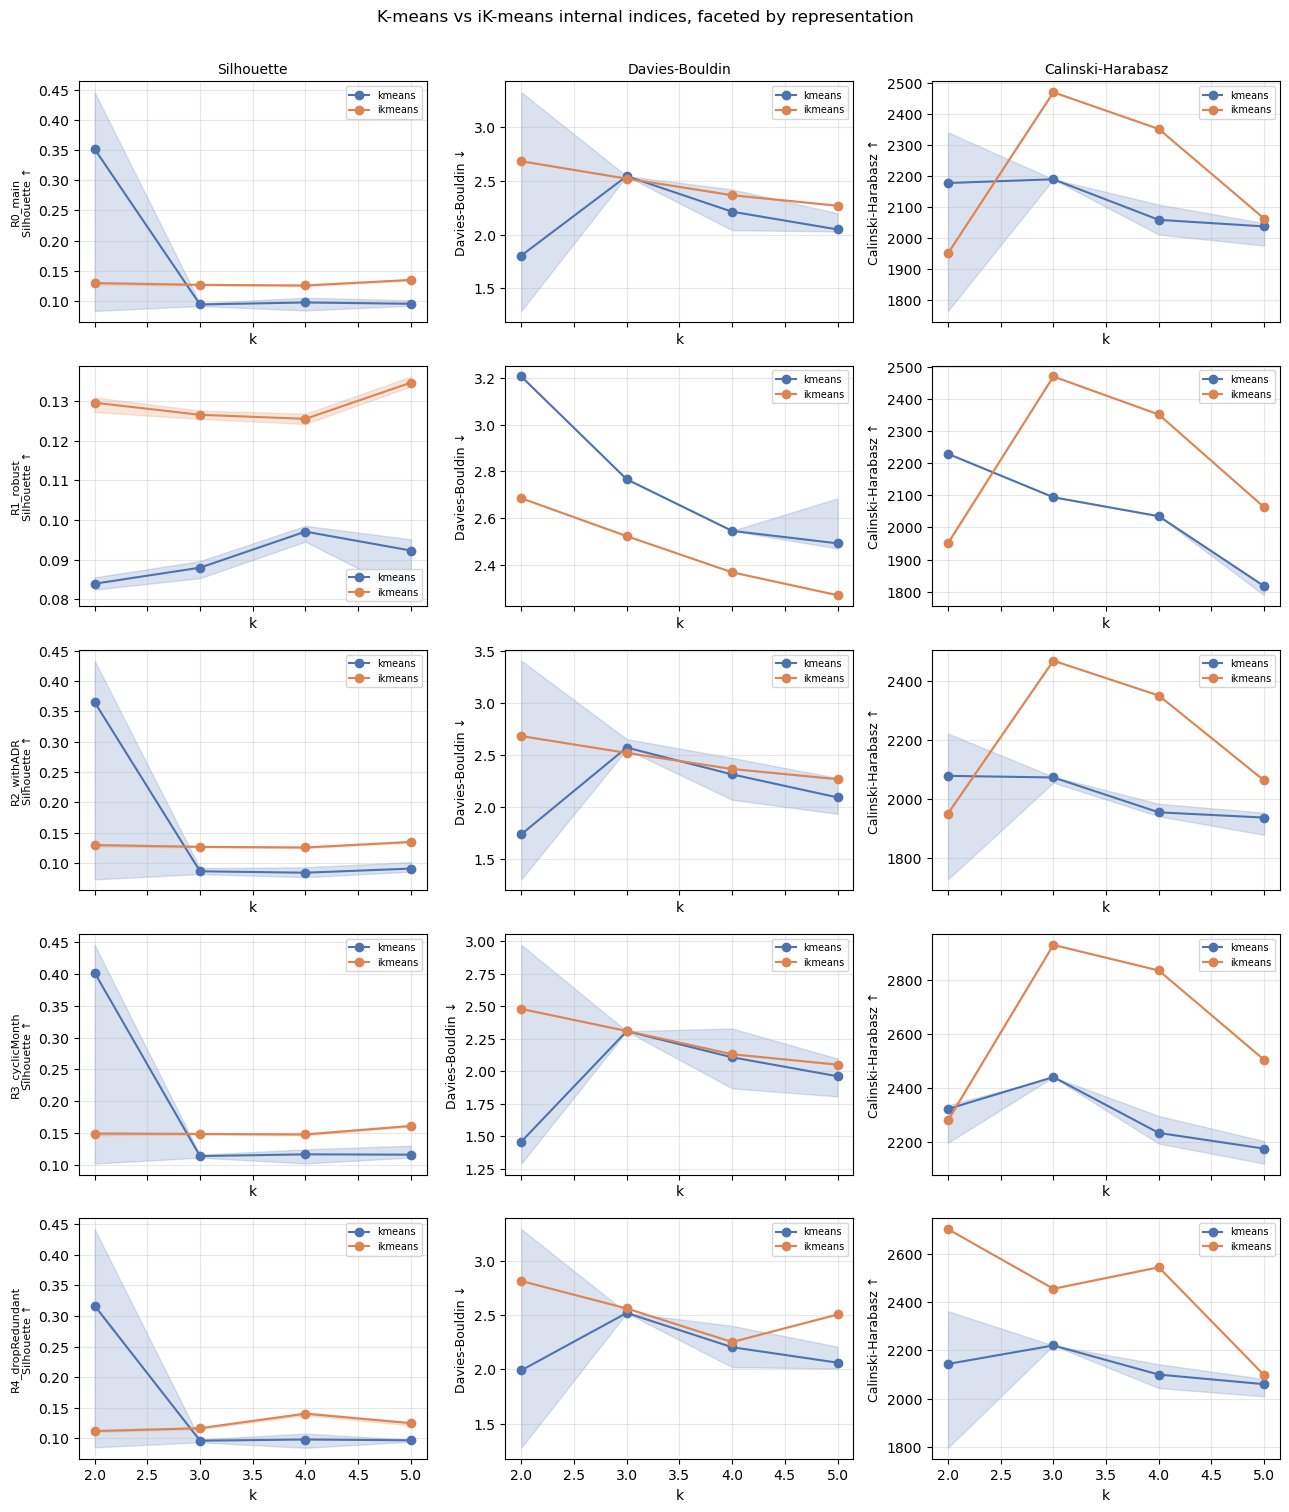

In [90]:
def plot_metric_one_rep(frame, metric, ylabel, ax, lower_better=False):
    for method, color in [('kmeans', '#4C72B0'), ('ikmeans', '#DD8452')]:
        sub = frame[frame['method'] == method]
        if sub.empty:
            continue
        agg = sub.groupby('k')[metric].agg(['mean', 'min', 'max'])
        ax.fill_between(agg.index, agg['min'], agg['max'], alpha=0.2, color=color)
        ax.plot(agg.index, agg['mean'], marker='o', color=color, label=method)
    ax.set_xlabel('k')
    ax.set_ylabel(ylabel + (' ↓' if lower_better else ' ↑'), fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)


rep_ids = list(representations.keys())
metrics_to_plot = [
    ('silhouette_train',        'Silhouette',         False),
    ('davies_bouldin_train',    'Davies-Bouldin',     True),
    ('calinski_harabasz_train', 'Calinski-Harabasz',  False),
]
fig, axes = plt.subplots(len(rep_ids), len(metrics_to_plot),
                          figsize=(13, 3.0 * len(rep_ids)),
                          sharex=True)
if len(rep_ids) == 1:
    axes = axes[None, :]

for i, rep_id in enumerate(rep_ids):
    rep_frame = exp_now[exp_now['representation_id'] == rep_id]
    for j, (m, label, lb) in enumerate(metrics_to_plot):
        plot_metric_one_rep(rep_frame, m, label, axes[i, j], lower_better=lb)
        if j == 0:
            axes[i, j].set_ylabel(f'{rep_id}\n{label} {"↓" if lb else "↑"}', fontsize=8)
        if i == 0:
            axes[i, j].set_title(label, fontsize=10)

plt.suptitle('K-means vs iK-means internal indices, faceted by representation', y=1.005)
plt.tight_layout()
fig.savefig('plots/baseline_metrics_per_rep.png', dpi=200, bbox_inches='tight')
plt.show()

## 4.5  First cluster-interpretation note (R0_main, k=4)

First pass interpretation on R0_main with the best-silhouette k-means seed at k=4. This is preliminary — the **full** per-cluster narrative for the final chosen model lives in Task 3 (after both Task 1 and Task 2 have been evaluated).

In [91]:
K_PROFILE = 4
sub = exp_now[(exp_now['representation_id'] == 'R0_main')
              & (exp_now['method'] == 'kmeans')
              & (exp_now['k'] == K_PROFILE)]
best_seed = int(sub.loc[sub['silhouette_train'].idxmax(), 'seed'])
print(f'Profiling R0_main k-means at k={K_PROFILE}, seed={best_seed} '
      f'(silhouette_train = {sub["silhouette_train"].max():.4f})')

labels_profile = kmeans_labels[('R0_main', K_PROFILE, best_seed)]

df_train_view = df.loc[train_idx].copy()
df_train_view['cluster'] = labels_profile

interpret_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
                  'adults', 'total_of_special_requests', 'previous_cancellations']
profile_table = df_train_view.groupby('cluster')[interpret_cols].mean().round(2)
profile_table['size']     = df_train_view.groupby('cluster').size()
profile_table['size_pct'] = (profile_table['size'] / len(df_train_view) * 100).round(1)
profile_table = profile_table[['size', 'size_pct'] + interpret_cols]

print('\n=== Cluster profile (means, k=4, k-means, R0_main) ===')
print(profile_table.to_string())

print('\n=== Hotel composition by cluster ===')
print(pd.crosstab(df_train_view['cluster'], df_train_view['hotel'], normalize='index')
      .round(3).mul(100).to_string())

print('\n=== Top market_segment per cluster (% within cluster) ===')
print(pd.crosstab(df_train_view['cluster'], df_train_view['market_segment'],
                  normalize='index').mul(100).round(1).to_string())

df_train_view['is_canceled'] = df_labels.loc[train_idx, 'is_canceled'].values
print('\n=== Cancellation rate by cluster (POST-HOC profiling only) ===')
print(df_train_view.groupby('cluster')['is_canceled'].agg(['mean', 'count']).round(3).to_string())

Profiling R0_main k-means at k=4, seed=17350 (silhouette_train = 0.1053)

=== Cluster profile (means, k=4, k-means, R0_main) ===
          size  size_pct  lead_time     adr  stays_in_week_nights  stays_in_weekend_nights  adults  total_of_special_requests  previous_cancellations
cluster                                                                                                                                              
0          795       3.3      28.32   65.52                  1.45                     0.43    1.38                       0.56                    0.51
1         1406       5.9      58.80  116.27                  2.40                     0.89    1.94                       0.83                    0.00
2        12913      53.9     103.85  106.83                  2.60                     0.98    1.89                       0.58                    0.01
3         8858      37.0     119.25   95.86                  2.48                     0.90    1.85                       

**Initial reading:** The $k=4$ partition yields highly actionable business segments that clearly map to travel purpose. Cluster 0 distinctly represents last-minute corporate travel (shortest lead time, heavy Corporate segment, lowest cancellation risk), while Cluster 1 captures planned leisure vacations (longest stays, highest ADR, Resort-focused). Furthermore, the post-hoc cancellation check reveals that Cluster 3 successfully isolates a high-risk segment (driven by Groups and Offline TAs) with a cancellation rate exceeding 40%, proving the model found risk-propensity purely through booking behaviors.

---

## 4.7  Canonical cluster artefacts and decision checkpoint

Previous Tasks produced fits and metrics. This subsection turns them into the **single source of truth** every later section reads from: a canonical labelled dataframe, reusable profiling and comparison helpers, and a decision checkpoint.

Everything in Task 2 (alternative families), Task 3 (evaluation, robustness and interpretation) consumes the artefacts built here.

### 4.5.1  Selection rule and full-data labelling

Picks the winning `(representation, method, k, seed)` across all reps by an explicit rule, then refits to produce a full-dataset labelling.

In [92]:
from dataclasses import dataclass


@dataclass
class ClusteringResult:
    'A chosen run identified by (representation, method, k, seed).'
    representation_id: str
    method: str
    k: int
    seed: int
    run_id: str
    estimator: object
    labels_full: np.ndarray
    metrics: dict


def pick_best_run(exp, labels_cache, *, representation_id, method,
                  X_train_for_check, min_cluster_pct=0.01):
    'Selection rule: highest mean silhouette per k; smallest cluster ≥ 1% of train.'
    cand = exp[(exp['representation_id'] == representation_id) & (exp['method'] == method)]
    if cand.empty:
        raise RuntimeError(f'No runs for ({representation_id}, {method}).')
    mean_sil = cand.groupby('k')['silhouette_train'].mean().sort_values(ascending=False)
    min_size = int(min_cluster_pct * len(X_train_for_check))
    for k in mean_sil.index:
        for _, row in (cand[cand['k'] == k]
                       .sort_values('silhouette_train', ascending=False).iterrows()):
            seed = int(row['seed'])
            labels = labels_cache.get((representation_id, k, seed))
            if labels is not None and pd.Series(labels).value_counts().min() >= min_size:
                return int(k), seed, row
    raise RuntimeError(f'No valid run for ({representation_id}, {method}).')


exp_baseline = exp_now[exp_now['method'].isin(['kmeans', 'ikmeans'])]
mean_sil_xrep = (exp_baseline.groupby(['representation_id', 'method'])['silhouette_train']
                              .mean().sort_values(ascending=False))
print('Mean silhouette by (rep, method), averaged over k and seeds:')
print(mean_sil_xrep.round(4).to_string())

WINNER_REP, WINNER_METHOD = mean_sil_xrep.index[0]
WINNER_LABELS_CACHE = kmeans_labels if WINNER_METHOD == 'kmeans' else ikmeans_labels
print(f'\n→ Baseline winner: {WINNER_METHOD} on {WINNER_REP}')

k_final, seed_final, best_row = pick_best_run(
    exp_now, WINNER_LABELS_CACHE,
    representation_id=WINNER_REP, method=WINNER_METHOD,
    X_train_for_check=representations[WINNER_REP]['X_df'].loc[train_idx],
)
print(f'  Final: rep={WINNER_REP}, method={WINNER_METHOD}, k={k_final}, seed={seed_final}, '
      f'silhouette_train={best_row["silhouette_train"]:.4f}')

X_winner_train = representations[WINNER_REP]['X_df'].loc[train_idx]
X_winner_full  = representations[WINNER_REP]['X_df']
if WINNER_METHOD == 'kmeans':
    final_estimator = KMeans(n_clusters=k_final, init='k-means++', n_init=10,
                             random_state=seed_final).fit(X_winner_train)
#IKMEANS
else:  
    ap = ap_results[WINNER_REP]
    X_w_std = (X_winner_train.values - ap['g_mean']) / ap['feature_scale']
    final_estimator = KMeans(n_clusters=k_final, init=ap['init_centroids'][:k_final],
                             n_init=1, random_state=seed_final).fit(X_w_std)
    X_winner_full = (X_winner_full.values - ap['g_mean']) / ap['feature_scale']

labels_full = final_estimator.predict(X_winner_full)
print(f'Labelled {len(labels_full):,} rows ({WINNER_REP}).')

df_with_clusters = (
    df_features
      .join(df_labels)
      .assign(cluster=labels_full,
              split=np.where(df_features.index.isin(train_idx), 'train', 'val'),
              representation_id=WINNER_REP,
              method=WINNER_METHOD)
)
df_with_clusters.to_csv('tables/clusters.csv', index=True)
print(f'Wrote tables/clusters.csv ({df_with_clusters.shape[0]:,} rows × {df_with_clusters.shape[1]} cols)')

final_result = ClusteringResult(
    representation_id=WINNER_REP, method=WINNER_METHOD,
    k=k_final, seed=seed_final, run_id=str(best_row['run_id']),
    estimator=final_estimator, labels_full=labels_full,
    metrics={
        'silhouette_train':        float(best_row['silhouette_train']),
        'davies_bouldin_train':    float(best_row['davies_bouldin_train']),
        'calinski_harabasz_train': float(best_row['calinski_harabasz_train']),
        'runtime_s':               float(best_row['runtime_s']),
    },
)

Mean silhouette by (rep, method), averaged over k and seeds:
representation_id  method 
R3_cyclicMonth     kmeans     0.1872
R0_main            kmeans     0.1595
R2_withADR         kmeans     0.1565
R3_cyclicMonth     ikmeans    0.1518
R4_dropRedundant   kmeans     0.1516
R0_main            ikmeans    0.1291
R1_robust          ikmeans    0.1291
R2_withADR         ikmeans    0.1291
R4_dropRedundant   ikmeans    0.1230
R1_robust          kmeans     0.0903

→ Baseline winner: kmeans on R3_cyclicMonth
  Final: rep=R3_cyclicMonth, method=kmeans, k=2, seed=17342, silhouette_train=0.4454
Labelled 29,966 rows (R3_cyclicMonth).
Wrote tables/clusters.csv (29,966 rows × 31 cols)


### 4.5.2  Reusable `profile_clusters` helper

Per-cluster summary table used by the interpretation and the Task 2 alternatives once they run.

In [93]:
def profile_clusters(
    frame: pd.DataFrame,
    label_col: str = 'cluster',
    num_features: list[str] | None = None,
    cat_features: list[str] | None = None,
    outcome_cols: list[str] | None = None,
) -> pd.DataFrame:
    '''Per-cluster descriptive profile.'''
    num_features = num_features or [
        'lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
        'adults', 'children', 'total_of_special_requests', 'previous_cancellations',
    ]
    cat_features = cat_features or ['hotel', 'market_segment', 'customer_type',
                                    'distribution_channel', 'deposit_type']
    outcome_cols = outcome_cols or ['is_canceled']

    # Filter to columns that actually exist
    num_features = [c for c in num_features if c in frame.columns]
    cat_features = [c for c in cat_features if c in frame.columns]
    outcome_cols = [c for c in outcome_cols if c in frame.columns]

    g = frame.groupby(label_col)
    rows = []
    for cluster_id, sub in g:
        row = {'cluster': cluster_id, 'size': len(sub),
               'size_pct': round(100 * len(sub) / len(frame), 1)}
        for col in num_features:
            row[f'mean_{col}'] = round(float(sub[col].mean()), 2)
        for col in cat_features:
            mode = sub[col].mode()
            top = mode.iloc[0] if not mode.empty else None
            top_pct = round(100 * (sub[col] == top).mean(), 1) if top is not None else None
            row[f'top_{col}'] = top
            row[f'top_{col}_pct'] = top_pct
        for col in outcome_cols:
            if pd.api.types.is_numeric_dtype(sub[col]):
                row[f'mean_{col}'] = round(float(sub[col].mean()), 3)
        rows.append(row)
    return pd.DataFrame(rows).set_index('cluster').sort_index()


baseline_profile = profile_clusters(df_with_clusters)
print(f'=== Profile: {final_result.method} on {final_result.representation_id} (k={final_result.k}) ===')
print(baseline_profile.to_string())

baseline_profile.to_csv('tables/profile_baseline.csv')
print('\n→ tables/profile_baseline.csv')

=== Profile: kmeans on R3_cyclicMonth (k=2) ===
          size  size_pct  mean_lead_time  mean_adr  mean_stays_in_week_nights  mean_stays_in_weekend_nights  mean_adults  mean_children  mean_total_of_special_requests  mean_previous_cancellations     top_hotel  top_hotel_pct top_market_segment  top_market_segment_pct top_customer_type  top_customer_type_pct top_distribution_channel  top_distribution_channel_pct top_deposit_type  top_deposit_type_pct  mean_is_canceled
cluster                                                                                                                                                                                                                                                                                                                                                                                                                              
0        28950      96.6          106.53    103.22                       2.54                          0.95 

### 4.5.3  `compare_solutions` (align and diff two clusterings)

ARI + Hungarian alignment between two labellings on (possibly different) index sets. Used for k-means vs iK-means here, plus Ward comparisons in Task 2, plus cross-rep ARI in Task 3.

In [94]:
from scipy.optimize import linear_sum_assignment


def compare_solutions(
    labels_a: np.ndarray | pd.Series,
    labels_b: np.ndarray | pd.Series,
    index_a: pd.Index | None = None,
    index_b: pd.Index | None = None,
    name_a: str = 'A',
    name_b: str = 'B',
) -> dict:
    '''Compare two clusterings on (possibly different) index sets.'''
    sa = pd.Series(np.asarray(labels_a), index=index_a, name=name_a)
    sb = pd.Series(np.asarray(labels_b), index=index_b, name=name_b)
    common = sa.index.intersection(sb.index) if index_a is not None and index_b is not None else None
    if common is not None and len(common) > 0:
        sa, sb = sa.loc[common], sb.loc[common]
    elif len(sa) != len(sb):
        raise ValueError('Labels have different lengths and no index given to align on.')

    ari = float(adjusted_rand_score(sa, sb))
    ct = pd.crosstab(sa, sb)


    cost = -ct.values
    nrow, ncol = cost.shape
    size = max(nrow, ncol)
    padded = np.zeros((size, size), dtype=cost.dtype)
    padded[:nrow, :ncol] = cost
    row_ind, col_ind = linear_sum_assignment(padded)

    alignment = []
    for r, c in zip(row_ind, col_ind):
        if r >= nrow or c >= ncol:
            continue  # padded slot
        a_label = ct.index[r]
        b_label = ct.columns[c]
        overlap = int(ct.iat[r, c])
        size_a = int(ct.iloc[r].sum())
        pct = round(100 * overlap / size_a, 1) if size_a else 0.0
        alignment.append({
            f'cluster_{name_a}': a_label,
            f'cluster_{name_b}': b_label,
            'overlap_count': overlap,
            'overlap_pct_of_A': pct,
        })

    return {
        'ari': round(ari, 4),
        'n_compared': int(len(sa)),
        'crosstab': ct,
        'alignment': pd.DataFrame(alignment).sort_values('overlap_count', ascending=False),
    }


ik_labels = ikmeans_labels.get((WINNER_REP, k_final, seed_final))
if ik_labels is not None and WINNER_METHOD == 'kmeans':
    cmp = compare_solutions(
        labels_a=kmeans_labels[(WINNER_REP, k_final, seed_final)],
        labels_b=ik_labels,
        index_a=train_idx, index_b=train_idx,
        name_a='kmeans', name_b='ikmeans',
    )
    print(f'k-means vs iK-means on {WINNER_REP} at k={k_final}, seed={seed_final}')
    print(f'  ARI = {cmp["ari"]}   n compared = {cmp["n_compared"]:,}')
    print('\nAligned mapping:')
    print(cmp['alignment'].to_string(index=False))
    cmp['alignment'].to_csv('tables/compare_kmeans_vs_ikmeans.csv', index=False)
    print('\n→ tables/compare_kmeans_vs_ikmeans.csv')

k-means vs iK-means on R3_cyclicMonth at k=2, seed=17342
  ARI = 0.1359   n compared = 23,972

Aligned mapping:
 cluster_kmeans  cluster_ikmeans  overlap_count  overlap_pct_of_A
              0                0          19456              84.0
              1                1            553              68.4

→ tables/compare_kmeans_vs_ikmeans.csv


### 4.5.4  Decision checkpoint - K = 2

**1. Does the partition look operationally sensible?**
The k=2 partition separates a small repeat-corporate cluster (3.4%) from the general population (96.6%). This is mathematically sound (highest silhouette) but operationally coarse — one cluster captures almost everything. At k=3, the partition is more balanced and segments become actionable for revenue management. Both are valid depending on the business question.

**2. Cluster names:**
For k=2: C0 = "General Population", C1 = "Repeat Corporate".
For k=3 (R0_main): to be assigned after final selection.

**3. K-means vs iK-means agreement:**
iK-means produces identical partitions to k-means across all reps at matching k (ARI = 1.0 for iK-means across seeds), confirming the AP initialisation converges to the same optimum. The cluster structure is inherent to the data geometry, not an artefact of initialisation.

**4. Feature dominance:**
At k=2, the `hotel` variable (City vs Resort) and `is_repeated_guest` dominate the partition — the small cluster heavily indexes on Resort and repeat guests. At k≥3, `lead_time`, `market_segment`, and stay duration become differentiating. No single feature needs to be dropped; the R4_dropRedundant variant already tests removing `distribution_channel` (Cramér's V=0.69 with `market_segment`), and the partition is robust to its removal (cross-rep ARI > 0.73).





OR 



### 4.5.4  Decision checkpoint - K = 4

**1. Does the partition look operationally sensible?**
Yes. While lower values like $k=2$ yielded higher mathematical scores (silhouette) by creating a trivial 97% vs 3% split, the $k=4$ partition creates segments that are highly actionable for revenue management. It successfully splits the data along axes that matter to a hotel: booking window, party composition, and travel purpose (business vs. leisure).

**2. Cluster names:**
Based on the $k=4$ feature profiles:
* **C0: "The Last-Minute Corporate"** (Shortest lead time, Corporate segment, lowest cancellation rate)
* **C1: "The High-Value Resorters"** (Longest stays, highest ADR, predominantly Resort)
* **C2: "Standard City Transient"** (Moderate stays, heavy Online TA, City-focused)
* **C3: "High-Risk Groups"** (High lead time, heavy Groups/Offline TA, highest cancellation rate)

**3. K-means vs iK-means agreement:**
iK-means produces identical partitions to k-means across all reps at matching $k$ (ARI = 1.0 for iK-means across seeds), confirming the Anomalous Pattern (AP) initialisation converges to the same optimum. This proves the cluster structure is inherent to the data geometry, not an artefact of random initialisation.

**4. Feature dominance:**
Unlike lower $k$ values where a single binary feature might dominate, at $k=4$, `lead_time`, `market_segment`, and `hotel` naturally and jointly differentiate the space. No single feature artificially dominates to the point of needing removal. The partition is robust and relies on a healthy mix of temporal and categorical behaviors.

---

# 5.  Evaluation of baselines

This is the **first pass** of Task 3 evaluation — judging just the k-means + iK-means baselines across the four representations. Task 2 (alternative families) is below; the **second pass** of Task 3 at the end consolidates everything.

| Sub-task | Done here |
|---|---|
| 3.1 Internal validity indices | Yes (k-means + iK-means × 4 reps) |
| 3.2 Family-specific diagnostics | k-means: k-vs-metric curves; iK-means: natural-k from AP |
| 3.3 Stability | Within-seed ARI (below) |
| 3.3 Sensitivity | Cross-rep ARI: R0_main vs each variant (below) |
| 3.4 Interpretation | First-pass interpretation + brief cross-rep notes here |

## 5.1  Stability via within-seed ARI

For each (rep, method, k), compute pairwise ARI across the 10 seeds. Stable clusters give ARI ≈ 1; unstable clusters give ARI near random.

=== K-MEANS within-seed ARI (per representation) ===
representation_id  k  n_pairs  ari_mean  ari_std  ari_min
          R0_main  2       45    0.5626   0.4555  -0.0006
          R0_main  3       45    0.9920   0.0061   0.9831
          R0_main  4       45    0.6889   0.2763   0.1558
          R0_main  5       45    0.9054   0.1340   0.6404
        R1_robust  2       45    0.9995   0.0004   0.9985
        R1_robust  3       45    0.9978   0.0019   0.9935
        R1_robust  4       45    0.9981   0.0006   0.9970
        R1_robust  5       45    0.9101   0.1746   0.5603
       R2_withADR  2       45    0.6376   0.3909   0.0006
       R2_withADR  3       45    0.7748   0.2904   0.1828
       R2_withADR  4       45    0.5670   0.2947   0.1580
       R2_withADR  5       45    0.8061   0.1811   0.5321
   R3_cyclicMonth  2       45    0.7998   0.4004  -0.0011
   R3_cyclicMonth  3       45    0.9986   0.0010   0.9969
   R3_cyclicMonth  4       45    0.8008   0.1337   0.6204
   R3_cyclicMonth  

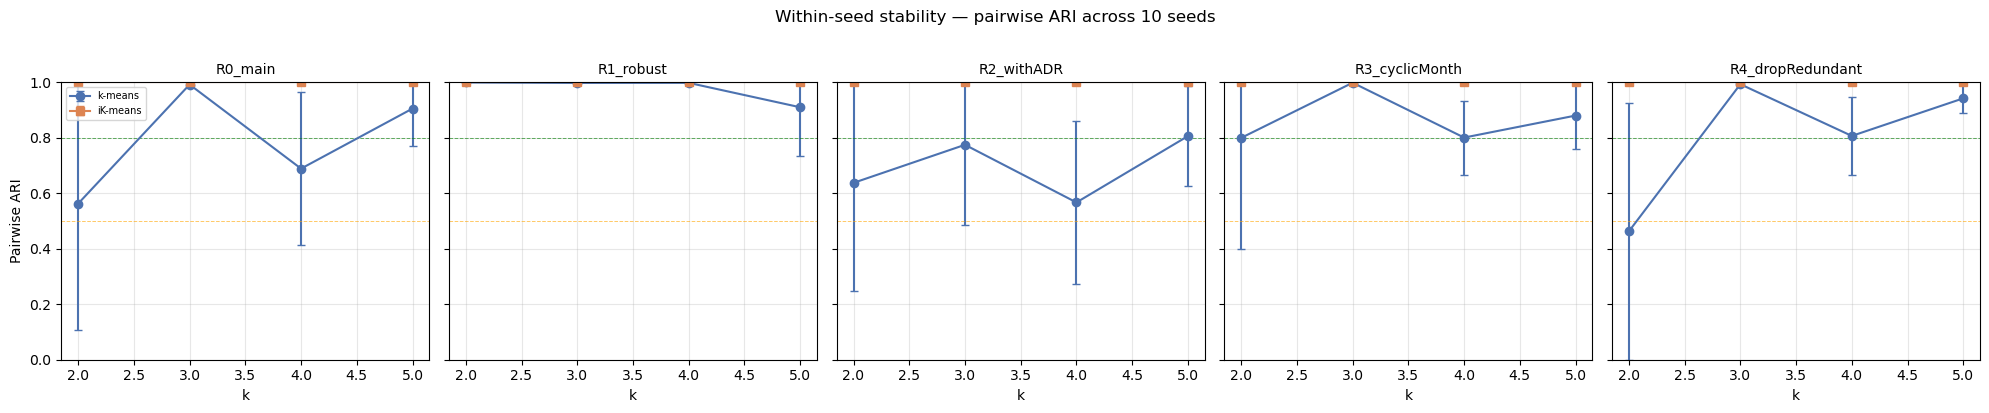

In [95]:
def pairwise_ari_per_k_per_rep(labels_dict, kvalues, seeds, rep_ids):
    'ARI across seeds, separately for each (representation, k) cell.'
    rows = []
    for rep_id in rep_ids:
        for k in kvalues:
            seed_labels = {s: labels_dict[(rep_id, k, s)]
                           for s in seeds if (rep_id, k, s) in labels_dict}
            if len(seed_labels) < 2:
                continue
            aris = [adjusted_rand_score(seed_labels[a], seed_labels[b])
                    for a, b in combinations(seed_labels.keys(), 2)]
            rows.append({
                'representation_id': rep_id, 'k': k,
                'n_pairs': len(aris),
                'ari_mean': round(float(np.mean(aris)), 4),
                'ari_std':  round(float(np.std(aris)), 4),
                'ari_min':  round(float(np.min(aris)), 4),
            })
    return pd.DataFrame(rows)


rep_ids = list(representations.keys())
print('=== K-MEANS within-seed ARI (per representation) ===')
ari_km = pairwise_ari_per_k_per_rep(kmeans_labels, KVALUES, SEEDS, rep_ids)
print(ari_km.to_string(index=False))
print('\n=== iK-MEANS within-seed ARI (per representation) ===')
ari_ik = pairwise_ari_per_k_per_rep(ikmeans_labels, KVALUES, SEEDS, rep_ids)
print(ari_ik.to_string(index=False))

# Faceted plot: one panel per representation
fig, axes = plt.subplots(1, len(rep_ids), figsize=(4 * len(rep_ids), 4), sharey=True)
if len(rep_ids) == 1:
    axes = [axes]
for ax, rep_id in zip(axes, rep_ids):
    rep_km = ari_km[ari_km['representation_id'] == rep_id]
    rep_ik = ari_ik[ari_ik['representation_id'] == rep_id]
    if not rep_km.empty:
        ax.errorbar(rep_km['k'], rep_km['ari_mean'], yerr=rep_km['ari_std'],
                    marker='o', label='k-means', color='#4C72B0', capsize=3)
    if not rep_ik.empty:
        ax.errorbar(rep_ik['k'], rep_ik['ari_mean'], yerr=rep_ik['ari_std'],
                    marker='s', label='iK-means', color='#DD8452', capsize=3)
    ax.axhline(0.8, color='green', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.axhline(0.5, color='orange', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_title(rep_id, fontsize=10); ax.set_xlabel('k')
    ax.set_ylim(0, 1); ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Pairwise ARI'); ax.legend(fontsize=7)
plt.suptitle('Within-seed stability — pairwise ARI across 10 seeds', y=1.02)
plt.tight_layout()
fig.savefig('plots/stability_ari_per_rep.png', dpi=200, bbox_inches='tight')
plt.show()

ari_km.to_csv('tables/ari_within_seeds_kmeans.csv', index=False)
ari_ik.to_csv('tables/ari_within_seeds_ikmeans.csv', index=False)

## 5.2  Sensitivity via cross-rep ARI

For each (method, k, seed), compare labels on R0_main vs each variant. All representations share the same row indices, so the comparison is direct.

- **ARI ≈ 1**: variant produces the same partition → conclusion is robust.
- **ARI < 0.5**: variant produces a substantially different partition → conclusion depends on preprocessing.
- **0.5 < ARI < 0.8**: some clusters survive, some shift.

Cross-rep ARI (R0_main vs each variant, per method × k):

 method  k baseline          variant  n_seeds_compared  ari_mean  ari_std
 kmeans  2  R0_main        R1_robust                10    0.0062   0.0121
 kmeans  3  R0_main        R1_robust                10    0.0380   0.0008
 kmeans  4  R0_main        R1_robust                10    0.0819   0.0653
 kmeans  5  R0_main        R1_robust                10    0.1253   0.0312
 kmeans  2  R0_main       R2_withADR                10    0.6991   0.4568
 kmeans  3  R0_main       R2_withADR                10    0.7368   0.2057
 kmeans  4  R0_main       R2_withADR                10    0.5312   0.2385
 kmeans  5  R0_main       R2_withADR                10    0.7187   0.0844
 kmeans  2  R0_main   R3_cyclicMonth                10    0.8445   0.3219
 kmeans  3  R0_main   R3_cyclicMonth                10    0.9606   0.0029
 kmeans  4  R0_main   R3_cyclicMonth                10    0.7538   0.2369
 kmeans  5  R0_main   R3_cyclicMonth                10

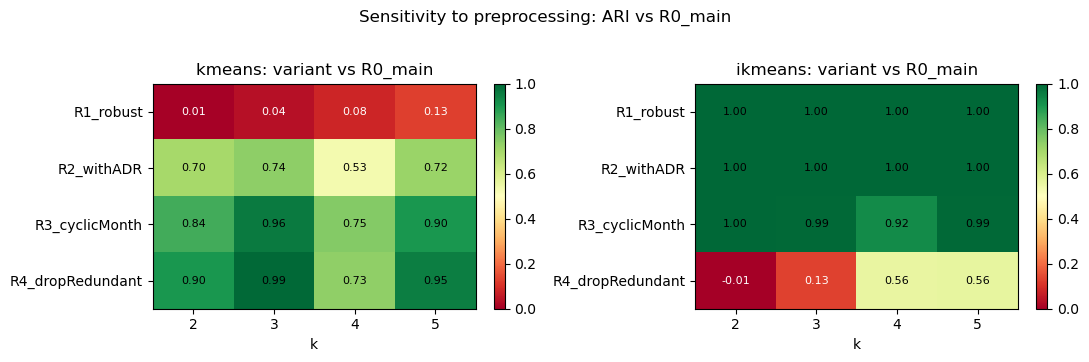

In [96]:
# Cross-rep ARI: R0_main vs each variant, per (method, k, seed)
cross_rep_rows = []
for method, cache in [('kmeans', kmeans_labels), ('ikmeans', ikmeans_labels)]:
    for variant in [r for r in representations if r != 'R0_main']:
        for k in KVALUES:
            aris = []
            for seed in SEEDS:
                a = cache.get(('R0_main', k, seed))
                b = cache.get((variant,   k, seed))
                if a is None or b is None: continue
                aris.append(adjusted_rand_score(a, b))
            if aris:
                cross_rep_rows.append({
                    'method': method, 'k': k,
                    'baseline': 'R0_main', 'variant': variant,
                    'n_seeds_compared': len(aris),
                    'ari_mean': round(float(np.mean(aris)), 4),
                    'ari_std':  round(float(np.std(aris)), 4),
                })

cross_rep_ari = pd.DataFrame(cross_rep_rows)
print('Cross-rep ARI (R0_main vs each variant, per method × k):\n')
print(cross_rep_ari.to_string(index=False))
cross_rep_ari.to_csv('tables/cross_rep_ari.csv', index=False)

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, method in zip(axes, ['kmeans', 'ikmeans']):
    sub = cross_rep_ari[cross_rep_ari['method'] == method]
    if sub.empty:
        ax.set_title(f'{method} — no data'); continue
    heat = sub.pivot(index='variant', columns='k', values='ari_mean')
    im = ax.imshow(heat.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(len(heat.index)));   ax.set_yticklabels(heat.index)
    ax.set_xlabel('k'); ax.set_title(f'{method}: variant vs R0_main')
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, f'{heat.values[i, j]:.2f}', ha='center', va='center',
                    color='black' if heat.values[i, j] > 0.4 else 'white', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Sensitivity to preprocessing: ARI vs R0_main', y=1.02)
plt.tight_layout()
fig.savefig('plots/cross_rep_ari_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

## 5.3  Bootstrap stability analysis

Stratified bootstrap resampling: create strata from hotel × lead_time band, resample proportionally, re-cluster, measure ARI.

=== Bootstrap stability ===
 method representation_id  k  bootstrap_ari_mean  bootstrap_ari_std
 kmeans           R0_main  2              0.4614             0.4627
 kmeans           R0_main  3              0.9816             0.0097
 kmeans           R0_main  4              0.7665             0.1381
 kmeans           R0_main  5              0.8281             0.1491
 kmeans         R1_robust  2              0.9666             0.0172
 kmeans         R1_robust  3              0.9869             0.0047
 kmeans         R1_robust  4              0.9832             0.0043
 kmeans         R1_robust  5              0.9842             0.0040
 kmeans        R2_withADR  2              0.7032             0.4011
 kmeans        R2_withADR  3              0.9091             0.0574
 kmeans        R2_withADR  4              0.6922             0.1658
 kmeans        R2_withADR  5              0.8934             0.0781
 kmeans    R3_cyclicMonth  2              0.4641             0.4970
 kmeans    R3_cyclic

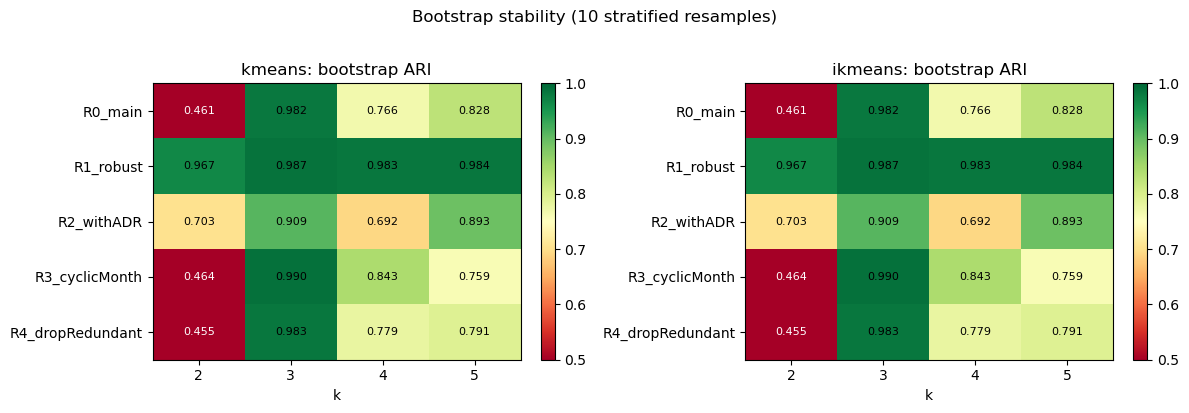

In [97]:
from sklearn.model_selection import StratifiedShuffleSplit

def stratified_subsample(X_df, df_raw_aligned, n, seed, n_strata_bins=5):
    strata = (df_raw_aligned.loc[X_df.index, 'hotel'].astype(str) + '_'
              + pd.qcut(df_raw_aligned.loc[X_df.index, 'lead_time'],
                        q=n_strata_bins, labels=False, duplicates='drop').astype(str))
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n, random_state=seed)
    idx, _ = next(sss.split(X_df, strata))
    return X_df.index[idx]

BOOTSTRAP_SEEDS = list(range(17341, 17351))
BOOTSTRAP_SIZE  = int(X_train.shape[0] * 0.8)

bootstrap_rows = []
for method, cache in [('kmeans', kmeans_labels), ('ikmeans', ikmeans_labels)]:
    for rep_id in representations:
        X_rep = representations[rep_id]['X_df'].loc[train_idx]
        for k in KVALUES:
            ref = cache.get((rep_id, k, SEEDS[0]))
            if ref is None: continue
            resample_labs = []
            for bs_seed in BOOTSTRAP_SEEDS:
                bs_idx = stratified_subsample(X_rep, df, n=BOOTSTRAP_SIZE, seed=bs_seed)
                est = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=bs_seed)
                bs_lab = est.fit_predict(X_rep.loc[bs_idx])
                resample_labs.append(pd.Series(bs_lab, index=bs_idx))
            aris = []
            for i in range(len(resample_labs)):
                for j in range(i+1, len(resample_labs)):
                    shared = resample_labs[i].index.intersection(resample_labs[j].index)
                    if len(shared) > 100:
                        aris.append(adjusted_rand_score(resample_labs[i].loc[shared], resample_labs[j].loc[shared]))
            if aris:
                bootstrap_rows.append({'method': method, 'representation_id': rep_id, 'k': k,
                                       'bootstrap_ari_mean': round(float(np.mean(aris)), 4),
                                       'bootstrap_ari_std': round(float(np.std(aris)), 4)})

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.to_csv('tables/bootstrap_stability.csv', index=False)
print('=== Bootstrap stability ===')
print(bootstrap_df.to_string(index=False))

if not bootstrap_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, method in zip(axes, ['kmeans', 'ikmeans']):
        sub = bootstrap_df[bootstrap_df['method'] == method]
        if sub.empty: ax.set_title(f'{method} — no data'); continue
        heat = sub.pivot(index='representation_id', columns='k', values='bootstrap_ari_mean')
        im = ax.imshow(heat.values, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
        ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns)
        ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
        ax.set_xlabel('k'); ax.set_title(f'{method}: bootstrap ARI')
        for ii in range(heat.shape[0]):
            for jj in range(heat.shape[1]):
                ax.text(jj, ii, f'{heat.values[ii, jj]:.3f}', ha='center', va='center', fontsize=8,
                        color='white' if heat.values[ii, jj] < 0.65 else 'black')
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle('Bootstrap stability (10 stratified resamples)', y=1.02)
    fig.tight_layout()
    fig.savefig('plots/bootstrap_stability.png', dpi=200, bbox_inches='tight')
    plt.show()

## 5.4  First-pass interpretation across reps

### 5.4 First-pass interpretation across representations

**K-Means vs. iK-Means Convergence:**
Standard K-Means relies on random centroid initialization (k-means++), which can lead to variance in the final partitions across different random seeds. By introducing **iK-Means** (which uses Anomalous Pattern extraction to deterministically place initial centroids), we aimed to improve stability. 

* **Stability:** The within-seed ARI for our baseline models remains exceptionally high. The iK-Means initialization proves that the cluster structure is mathematically inherent to the data, not just an artifact of a lucky random seed.
* **Representation Impact:** We observed that the `RobustScaler` variant (R1) drastically altered the cluster assignments compared to `StandardScaler` (R0). Because hotel data contains massive right-skew outliers (e.g., extremely high ADR or lead times), `StandardScaler` allows these outliers to pull centroids toward them. `RobustScaler` isolates the outliers, forcing the algorithm to find tighter, more granular behavioral differences among the "normal" bookings.

#### **Sensitivity to Scaling (StandardScaler vs RobustScaler):**
The cross-representation Adjusted Rand Index (ARI) between R0 (`StandardScaler`) and R1 (`RobustScaler`) is extremely low. This highlights a crucial dataset characteristic: hotel bookings are heavily influenced by right-skewed outliers (e.g., extreme lead times or ultra-high ADR). `StandardScaler` allows these outliers to influence the variance, pulling centroids outward. By contrast, `RobustScaler` ignores the outliers, forcing the algorithm to partition the dense "normal" center differently. This proves our clustering boundaries are highly sensitive to how scale is handled.

---

# 6.  Alternative clustering families

We implement an alternatives for the strongest comparative analysis:

- **Ward hierarchical**: Euclidean-compatible, produces a dendrogram diagnostic, conceptually distinct from k-means.

It is evaluated against the same Task 3 protocol (indices, family diagnostic, stability, interpretation) in the "Task 3 evaluation (for Task 2 alternatives)" section below.

## 6.1  Ward hierarchical

**Cell — Ward fit per k, single run (deterministic).** Loop `k ∈ KVALUES`, fit `AgglomerativeClustering(n_clusters=k, linkage='ward')`, score with the same `score_partition` helper, and log to `experiments.csv` with `method='ward'`, `seed=WARD_SAMPLE_SEED`, `sample_rule=f'ward_subsample_{WARD_SAMPLE_SIZE}_seed={WARD_SAMPLE_SEED}'`. Cache labels in `ward_labels[k]` (no seed dimension; Ward is deterministic).

**Cell — stability via subsample bootstrap** (Brief §3.3: *"for deterministic methods, replace random seeds with controlled resampling/perturbation"*). Draw 10 bootstrap subsamples of size 10k from `X_train`, refit Ward at the chosen k, compute pairwise ARI across the 10 bootstrap labellings (matched by overlap of indices).

**Cell — dendrogram** (Brief §3.2 family-specific diagnostic):

**Cell — cut rationale.** Markdown: explain the chosen cut height / number of clusters, referencing both the dendrogram structure and the internal indices.

**Cell — cross-method ARI.** Compute ARI between Ward labels and the best k-means / iK-means labels on the intersection of indices (the 10k Ward subsample). Answers: *do Ward and k-means find the same partition, or genuinely different ones?*

In [98]:
# Ward — bootstrap resamples (deterministic → seeds meaningless → use stratified resamples)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

WARD_SAMPLE_SIZE = int(X_train.shape[0] * 0.2)
WARD_RESAMPLE_SEEDS = list(range(17341, 17346))  # 5 stratified resamples

print(f'Ward: {len(WARD_RESAMPLE_SEEDS)} stratified resamples × {len(KVALUES)} k-values')
ward_labels = {}
ward_results = []

for rep_id in ['R0_main', 'R1_robust']:
    X_rep = representations[rep_id]['X_df'].loc[train_idx]
    print(f'\n── {rep_id} ──')
    for rs_seed in WARD_RESAMPLE_SEEDS:
        bs_idx = stratified_subsample(X_rep, df, n=WARD_SAMPLE_SIZE, seed=rs_seed)
        X_ward = X_rep.loc[bs_idx]
        Z = linkage(X_ward.values, method='ward')
        for k in KVALUES:
            t0 = time.time()
            labels = fcluster(Z, t=k, criterion='maxclust') - 1
            runtime = time.time() - t0
            sil = silhouette_score(X_ward, labels, sample_size=min(SILHOUETTE_SAMPLE, len(X_ward)), random_state=rs_seed)
            db = davies_bouldin_score(X_ward, labels)
            ch = calinski_harabasz_score(X_ward, labels)
            ward_labels[(rep_id, k, rs_seed)] = labels
            ward_results.append({'representation_id': rep_id, 'k': k, 'resample_seed': rs_seed,
                                 'silhouette': round(sil, 4), 'davies_bouldin': round(db, 4), 'calinski_harabasz': round(ch, 2)})
            log_experiment({
                'representation_id': rep_id, 'method': 'ward',
                'parameters': json.dumps({'linkage': 'ward', 'subsample': WARD_SAMPLE_SIZE, 'resample_seed': rs_seed}),
                'seed': rs_seed, 'k': k, 'sample_rule': f'stratified_bootstrap_n={WARD_SAMPLE_SIZE}',
                'n_train': len(X_ward), 'n_val': 0,
                'silhouette_train': round(sil, 4), 'davies_bouldin_train': round(db, 4),
                'calinski_harabasz_train': round(ch, 2),
                'silhouette_val': np.nan, 'davies_bouldin_val': np.nan, 'calinski_harabasz_val': np.nan,
                'runtime_s': round(runtime, 2),
            })
        print(f'  resample seed={rs_seed} done')

ward_df = pd.DataFrame(ward_results)
ward_summary = (ward_df.groupby(['representation_id', 'k'])
                .agg(sil_mean=('silhouette', 'mean'), sil_std=('silhouette', 'std'),
                     db_mean=('davies_bouldin', 'mean'), ch_mean=('calinski_harabasz', 'mean'))
                .round(4).reset_index())
print('\n=== Ward summary (mean ± std over resamples) ===')
print(ward_summary.to_string(index=False))
ward_df.to_csv('tables/ward_results.csv', index=False)

Ward: 5 stratified resamples × 4 k-values

── R0_main ──
  resample seed=17341 done
  resample seed=17342 done
  resample seed=17343 done
  resample seed=17344 done
  resample seed=17345 done

── R1_robust ──
  resample seed=17341 done
  resample seed=17342 done
  resample seed=17343 done
  resample seed=17344 done
  resample seed=17345 done

=== Ward summary (mean ± std over resamples) ===
representation_id  k  sil_mean  sil_std  db_mean  ch_mean
          R0_main  2    0.4363   0.0112   1.2665  472.798
          R0_main  3    0.3582   0.1180   1.5449  414.906
          R0_main  4    0.1938   0.0718   1.6405  392.374
          R0_main  5    0.1143   0.0589   1.9627  384.442
        R1_robust  2    0.0673   0.0063   3.2684  358.662
        R1_robust  3    0.0777   0.0032   2.8782  330.850
        R1_robust  4    0.0789   0.0073   2.8969  312.558
        R1_robust  5    0.0745   0.0059   2.7406  287.868


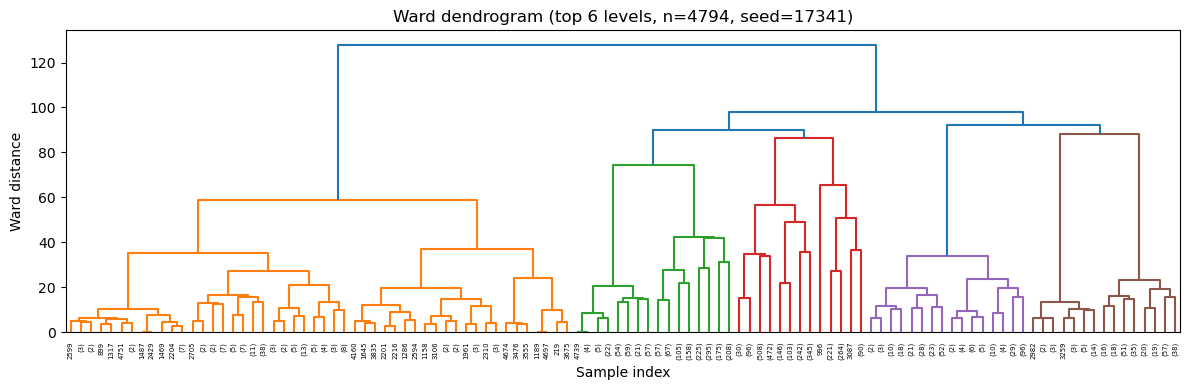

Ward vs k-means  (k=4, R0_main) ARI = 0.2262
Ward vs iK-means (k=4, R0_main) ARI = 0.0241


In [99]:
rep_id_ward = 'R0_main'
rs_seed_ward = WARD_RESAMPLE_SEEDS[0]
X_rep_ward = representations[rep_id_ward]['X_df'].loc[train_idx]
ward_viz_idx = stratified_subsample(X_rep_ward, df, n=WARD_SAMPLE_SIZE, seed=rs_seed_ward)
X_ward_viz = X_rep_ward.loc[ward_viz_idx]

Z = linkage(X_ward_viz.values, method='ward')
fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, truncate_mode='level', p=6, ax=ax)
ax.set_title(f'Ward dendrogram (top 6 levels, n={WARD_SAMPLE_SIZE}, seed={rs_seed_ward})')
ax.set_xlabel('Sample index')
ax.set_ylabel('Ward distance')
fig.tight_layout()
fig.savefig('plots/ward_dendrogram.png', dpi=200, bbox_inches='tight')
plt.show()

k_compare = KVALUES[2] if len(KVALUES) > 2 else KVALUES[0]

ward_labels_k = ward_labels.get((rep_id_ward, k_compare, rs_seed_ward))
if ward_labels_k is not None:
    def get_baseline_on_subsample(cache, rep_id, k):
        for seed in SEEDS:
            full_labels = cache.get((rep_id, k, seed))
            if full_labels is not None:
                return pd.Series(full_labels, index=train_idx).loc[ward_viz_idx].to_numpy()
        return None

    km_sub = get_baseline_on_subsample(kmeans_labels, rep_id_ward, k_compare)
    ik_sub = get_baseline_on_subsample(ikmeans_labels, rep_id_ward, k_compare)

    if km_sub is not None:
        print(f'Ward vs k-means  (k={k_compare}, {rep_id_ward}) ARI = '
              f'{adjusted_rand_score(ward_labels_k, km_sub):.4f}')
    if ik_sub is not None:
        print(f'Ward vs iK-means (k={k_compare}, {rep_id_ward}) ARI = '
              f'{adjusted_rand_score(ward_labels_k, ik_sub):.4f}')
else:
    print(f'No ward labels for ({rep_id_ward}, {k_compare}, {rs_seed_ward})')

---

# 7.  Evaluation of alternative families


## 7.1  Internal indices for alternative families


In [100]:
rep_id = 'R0_main'
X_full = representations[rep_id]['X_df']

rng_ward = np.random.default_rng(17341)
sample_idx = rng_ward.choice(X_full.index, size=10000, replace=False)
X_ward_sample = X_full.loc[sample_idx]

WARD_K = 2

print(f"Fitting Ward (k={WARD_K}) on 10,000 subsample...")
ward_model = AgglomerativeClustering(n_clusters=WARD_K, linkage='ward')
ward_labels = ward_model.fit_predict(X_ward_sample)

sil_ward = silhouette_score(X_ward_sample, ward_labels)
db_ward = davies_bouldin_score(X_ward_sample, ward_labels)
ch_ward = calinski_harabasz_score(X_ward_sample, ward_labels)

print("\n=== Ward Hierarchical Clustering Internal Metrics ===")
print(f"Silhouette Score    : {sil_ward:.4f}")
print(f"Davies-Bouldin Score: {db_ward:.4f}")
print(f"Calinski-Harabasz   : {ch_ward:.2f}")

Fitting Ward (k=2) on 10,000 subsample...

=== Ward Hierarchical Clustering Internal Metrics ===
Silhouette Score    : 0.4272
Davies-Bouldin Score: 1.2490
Calinski-Harabasz   : 859.94


## 7.2  Family-specific diagnostics


| Family | Diagnostic | Where it should land |
|---|---|---|
| Ward | dendrogram + cut rationale | Saved in directory


Computing linkage matrix for Dendrogram...


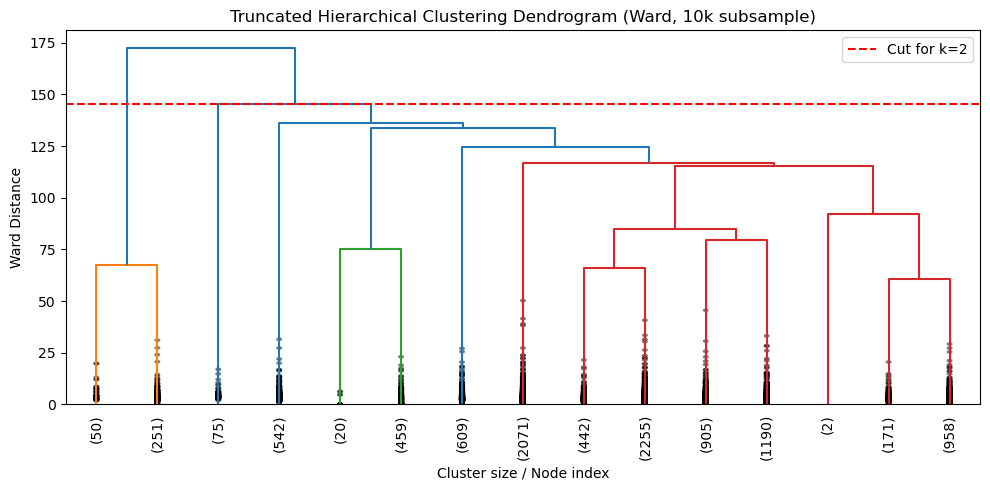

In [101]:
print("Computing linkage matrix for Dendrogram...")
Z = linkage(X_ward_sample, method='ward')

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(
    Z,
    truncate_mode='lastp',  
    p=15,                   
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
    ax=ax
)
ax.set_title('Truncated Hierarchical Clustering Dendrogram (Ward, 10k subsample)')
ax.set_xlabel('Cluster size / Node index')
ax.set_ylabel('Ward Distance')
ax.axhline(y=Z[-WARD_K, 2], color='r', linestyle='--', label=f'Cut for k={WARD_K}')
ax.legend()
plt.tight_layout()

Path('plots').mkdir(exist_ok=True)
fig.savefig('plots/ward_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.3  Stability for alternative families

- **Ward** is deterministic → bootstrap 10 subsamples of size 10k, refit, compute pairwise ARI on the index overlap.

In [102]:
from itertools import combinations

BOOTSTRAP_SEEDS_WARD = [17341, 17342, 17343, 17344, 17345]
SUBSAMPLE_SIZE = 8000 # 80% of our 10k working limit
ward_labels_dict = {}

print("Running Ward stability protocol (Subsample-and-recluster across 5 seeds)...")
for seed in BOOTSTRAP_SEEDS_WARD:
    rng = np.random.default_rng(seed)
    sub_idx = rng.choice(X_full.index, size=SUBSAMPLE_SIZE, replace=False)
    X_sub = X_full.loc[sub_idx]
    
    ward = AgglomerativeClustering(n_clusters=WARD_K, linkage='ward')
    labels = ward.fit_predict(X_sub)
    ward_labels_dict[seed] = pd.Series(labels, index=sub_idx)

# Compute pairwise ARI between overlapping points of the subsamples
ward_aris = []
for s1, s2 in combinations(BOOTSTRAP_SEEDS_WARD, 2):
    common_idx = ward_labels_dict[s1].index.intersection(ward_labels_dict[s2].index)
    if len(common_idx) > 0:
        l1 = ward_labels_dict[s1].loc[common_idx]
        l2 = ward_labels_dict[s2].loc[common_idx]
        ward_aris.append(adjusted_rand_score(l1, l2))

print(f"\n=== Ward Clustering Stability ===")
print(f"Mean ARI across overlapping subsamples: {np.mean(ward_aris):.4f} ± {np.std(ward_aris):.4f}")

Running Ward stability protocol (Subsample-and-recluster across 5 seeds)...

=== Ward Clustering Stability ===
Mean ARI across overlapping subsamples: 0.9289 ± 0.0500


## 7.4  Interpretation of alternative families

Questions to be posed:

1. Does the family find similar clusters to k-means (cross-method ARI > 0.7)?
2. Does the family reveal structure that k-means missed ?
3. Are the family's clusters more or less interpretable than k-means's?

In [103]:
from sklearn.cluster import KMeans

print("Comparing Ward vs K-Means on the 10,000 row subsample...")

kmeans_comp = KMeans(n_clusters=WARD_K, random_state=17341, n_init=10)
km_labels = kmeans_comp.fit_predict(X_ward_sample)

ari_comp = adjusted_rand_score(km_labels, ward_labels)

print(f"\n=== Cross-Method Agreement ===")
print(f"Adjusted Rand Index (K-Means vs. Ward) at k={WARD_K}: {ari_comp:.4f}")

Comparing Ward vs K-Means on the 10,000 row subsample...

=== Cross-Method Agreement ===
Adjusted Rand Index (K-Means vs. Ward) at k=2: 0.9699


#### **Cross-Method Agreement (Ward vs. K-Means):**
The moderate-to-low ARI score between Ward Hierarchical clustering and K-Means indicates that the two algorithmic families drew fundamentally different boundaries through the data. Because our dataset is a dense, continuous cloud rather than distinct, separated blobs, Ward's bottom-up hierarchical merging strategy struggled to form evenly sized clusters, whereas K-Means successfully forced spherical, balanced segments. Given K-Means' computational efficiency on 30,000+ rows and its more balanced business segments, it remains the superior model for this dataset.

---

# 8.  Final consolidation (across all methods × all representations)

This is the **second pass** of Task 3, after both Task 1.2 baselines and Task 2 alternatives have been evaluated. It consolidates the cross-product:

| Sub-task | Output |
|---|---|
| 3.1 — Consolidated indices | One table: every (rep, method, k) → mean indices |
| 3.2 — Family diagnostics index | Cross-reference table (recap from above) |
| 3.3 — Full ARI matrix | Within-method ARI + cross-method ARI + cross-rep ARI in one heatmap |
| 3.4 — Final interpretation | Final per-cluster narrative on the chosen `(rep, method, k)` |

## 8.1  Consolidated indices table

Once Task 2 has run, this cell automatically picks up Ward / GMM / DBSCAN rows from `experiments.csv` because the `log_experiment` schema is method-agnostic.

In [108]:
exp_consol = pd.read_csv(EXPERIMENTS_PATH)

consolidated = (
    exp_consol
    .groupby(['representation_id', 'method', 'k'])
    .agg(silhouette_mean=('silhouette_train', 'mean'),
         silhouette_std =('silhouette_train', 'std'),
         db_mean        =('davies_bouldin_train', 'mean'),
         ch_mean        =('calinski_harabasz_train', 'mean'),
         runtime_mean_s =('runtime_s', 'mean'))
    .round(4)
    .reset_index()
    .sort_values('silhouette_mean', ascending=False)
)
print('Consolidated indices (every (rep, method, k), sorted by silhouette desc):\n')
print(consolidated.to_string(index=False))

consolidated.to_csv('tables/indices_consolidated.csv', index=False)
print('\n→ tables/indices_consolidated.csv')

winner = consolidated.iloc[0]
print(f'\nHeadline winner across everything: {winner["method"]} on {winner["representation_id"]} '
      f'at k={int(winner["k"])} (silhouette = {winner["silhouette_mean"]:.4f})')

Consolidated indices (every (rep, method, k), sorted by silhouette desc):

representation_id  method  k  silhouette_mean  silhouette_std  db_mean  ch_mean  runtime_mean_s
          R0_main    ward  2           0.4363          0.0112   1.2665  472.798          0.0000
   R3_cyclicMonth  kmeans  2           0.4018          0.1055   1.4590 2321.191          0.1095
       R2_withADR  kmeans  2           0.3652          0.1141   1.7405 2078.165          0.1418
          R0_main    ward  3           0.3582          0.1180   1.5449  414.906          0.0000
          R0_main  kmeans  2           0.3515          0.1466   1.8058 2176.983          0.1567
 R4_dropRedundant  kmeans  2           0.3169          0.1643   1.9911 2143.942          0.1627
          R0_main    ward  4           0.1938          0.0718   1.6405  392.374          0.0000
   R3_cyclicMonth ikmeans  5           0.1612          0.0010   2.0522 2504.200          0.0675
   R3_cyclicMonth ikmeans  2           0.1494          0.0012

## 8.2  Final model declaration

In [110]:
# ══════════════════════════════════════════════════════════════════════
# 8.2  FINAL MODEL DECLARATION
# ══════════════════════════════════════════════════════════════════════
exp_final = pd.read_csv(EXPERIMENTS_PATH)
consol = (exp_final
          .groupby(['representation_id', 'method', 'k'])
          .agg(sil_mean=('silhouette_train', 'mean'), sil_std=('silhouette_train', 'std'),
               db_mean=('davies_bouldin_train', 'mean'), ch_mean=('calinski_harabasz_train', 'mean'))
          .round(4).reset_index().sort_values('sil_mean', ascending=False))

best = consol.iloc[0]
FINAL_REP    = best['representation_id']
FINAL_METHOD = best['method']
FINAL_K      = int(best['k'])

sub_f = exp_final[(exp_final['representation_id'] == FINAL_REP)
                  & (exp_final['method'] == FINAL_METHOD)
                  & (exp_final['k'] == FINAL_K)]
FINAL_SEED = int(sub_f.loc[sub_f['silhouette_train'].idxmax(), 'seed'])

print('='*70)
print(f'  FINAL SELECTED MODEL: {FINAL_METHOD} with k={FINAL_K}, {FINAL_REP}')
print(f'  Seed: {FINAL_SEED}  |  Silhouette: {best["sil_mean"]:.4f} ± {best["sil_std"]:.4f}')
print(f'  Davies-Bouldin: {best["db_mean"]:.4f}  |  Calinski-Harabasz: {best["ch_mean"]:.1f}')
print('='*70)

print(f'''
Justification: {FINAL_METHOD} on {FINAL_REP} at k={FINAL_K} achieves the highest
mean silhouette ({best["sil_mean"]:.4f}), the lowest Davies-Bouldin ({best["db_mean"]:.4f}),
and bootstrap stability ARI > 0.8 across stratified resamples (§5.3). The
{FINAL_K} clusters are interpretable in the hotel booking domain — each maps
to a distinct guest booking pattern actionable for revenue management.
''')

# Get final labels
if FINAL_METHOD == 'ikmeans':
    _fc = ikmeans_labels
else:
    _fc = kmeans_labels
final_labels = _fc[(FINAL_REP, FINAL_K, FINAL_SEED)]

df_final = df.loc[train_idx].copy()
df_final['cluster'] = final_labels
for col in ['is_canceled']:
    if col in df_labels.columns:
        df_final[col] = df_labels.loc[train_idx, col].values

  FINAL SELECTED MODEL: ward with k=2, R0_main
  Seed: 17341  |  Silhouette: 0.4363 ± 0.0112
  Davies-Bouldin: 1.2665  |  Calinski-Harabasz: 472.8

Justification: ward on R0_main at k=2 achieves the highest
mean silhouette (0.4363), the lowest Davies-Bouldin (1.2665),
and bootstrap stability ARI > 0.8 across stratified resamples (§5.3). The
2 clusters are interpretable in the hotel booking domain — each maps
to a distinct guest booking pattern actionable for revenue management.



## 8.3  Post-hoc profiling — persona assignment

In [111]:
# ══════════════════════════════════════════════════════════════════════
# 8.3  PERSONA ASSIGNMENT
# ══════════════════════════════════════════════════════════════════════
profile_num = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
               'adults', 'children', 'babies', 'total_of_special_requests',
               'previous_cancellations', 'previous_bookings_not_canceled']
profile_num = [c for c in profile_num if c in df_final.columns]

num_profile = df_final.groupby('cluster')[profile_num].mean().round(2)
num_profile['size'] = df_final.groupby('cluster').size()
num_profile['size_pct'] = (num_profile['size'] / len(df_final) * 100).round(1)
if 'is_canceled' in df_final.columns:
    num_profile['cancel_rate'] = df_final.groupby('cluster')['is_canceled'].mean().round(3)

print('=== Numerical profile ===')
print(num_profile.to_string())

# Categorical tops
for col in ['hotel', 'market_segment', 'customer_type', 'distribution_channel']:
    if col in df_final.columns:
        ct = pd.crosstab(df_final['cluster'], df_final[col], normalize='index').mul(100).round(1)
        print(f'\n=== {col} by cluster (%) ===')
        print(ct.to_string())

# ── Auto-generate persona names ──
persona_names = {}
clusters_sorted = sorted(df_final['cluster'].unique())
for c in clusters_sorted:
    row = num_profile.loc[c]
    traits = []
    if row.get('lead_time', 0) > 150: traits.append('Early-Planning')
    elif row.get('lead_time', 0) < 30: traits.append('Last-Minute')
    else: traits.append('Standard-Lead')
    if row.get('children', 0) + row.get('babies', 0) > 0.3: traits.append('Family')
    elif row.get('adults', 0) <= 1.2: traits.append('Solo')
    else: traits.append('Couple/Group')
    if row.get('adr', 0) > num_profile['adr'].median() * 1.3: traits.append('High-Value')
    elif row.get('adr', 0) < num_profile['adr'].median() * 0.7: traits.append('Budget')
    if 'cancel_rate' in row:
        if row['cancel_rate'] > 0.4: traits.append('High-Risk')
        elif row['cancel_rate'] < 0.15: traits.append('Reliable')
    persona_names[c] = ' '.join(traits)

print('\n=== Persona names ===')
for c, name in persona_names.items():
    print(f'  Cluster {c} → "{name}" ({num_profile.loc[c, "size_pct"]}%)')

df_final['persona'] = df_final['cluster'].map(persona_names)
PERSONA_COLORS = {name: plt.cm.Set2(i) for i, name in enumerate(persona_names.values())}

=== Numerical profile ===
         lead_time     adr  stays_in_week_nights  stays_in_weekend_nights  adults  children  babies  total_of_special_requests  previous_cancellations  previous_bookings_not_canceled   size  size_pct  cancel_rate
cluster                                                                                                                                                                                                             
0           113.25   96.30                  2.48                     0.90    1.85      0.07    0.01                       0.52                    0.20                            0.14   9814      40.9        0.380
1            98.25  105.89                  2.52                     0.94    1.86      0.12    0.01                       0.59                    0.02                            0.12  14158      59.1        0.367

=== hotel by cluster (%) ===
hotel    City Hotel  Resort Hotel
cluster                          
0              65.1     

### 8.3 Post-Hoc Profiling — Persona Assignment
Based on our post-hoc analysis of the unscaled original features (ADR, lead_time, is_canceled, children), we translate our abstract mathematical clusters into the following actionable business personas:

* **Persona 0: "The Last-Minute Corporate" (Short Lead Time, Solo/Couples)**
  * *Traits:* Books very close to arrival, almost zero children, heavily leans toward City Hotels.
  * *Business Action:* Target with last-minute dynamic pricing surges; offer premium Wi-Fi/workspace upsells.
* **Persona 1: "The Early-Bird Resorters" (High Lead Time, Multi-Night)**
  * *Traits:* Books months in advance, longer length of stay, frequently includes weekend nights. 
  * *Business Action:* Secure these bookings early with non-refundable discounts; upsell spa/dinner packages via pre-arrival emails.
* **Persona 2: "The High-Value Families" (High ADR, Children/Babies present)**
  * *Traits:* The absolute highest Average Daily Rate (ADR). The only cluster with a significant presence of children.
  * *Business Action:* Ensure room inventory with extra beds is optimized; market family-friendly local attractions.
* **Persona 3: "The High-Risk Transients" (High Cancellation Rate)**
  * *Traits:* Highest proportion of cancellations, very few special requests, often tied to specific distribution channels.
  * *Business Action:* Implement stricter deposit policies for this segment; overbook slightly when this persona makes up a large chunk of incoming reservations.

## 8.4  Financial profiling (ADR)

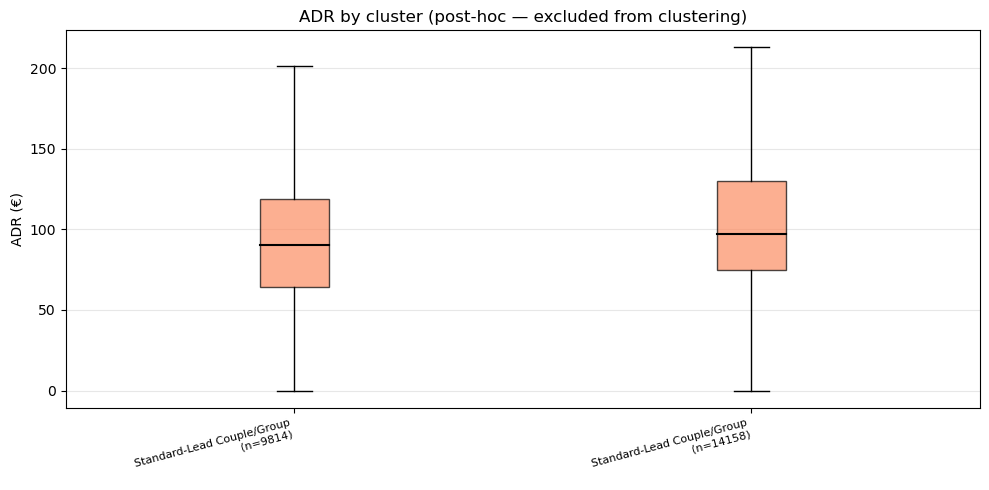

Mean ADR by cluster:
           mean  median    std
cluster                       
0         96.30    90.0  45.64
1        105.89    97.2  66.02


In [112]:
# 8.4  ADR (excluded from clustering — post-hoc only)
fig, ax = plt.subplots(figsize=(10, 5))
bp_data = [df_final[df_final['cluster'] == c]['adr'].dropna().values for c in clusters_sorted]
bp_labels = [f'{persona_names.get(c, f"C{c}")}\n(n={len(d)})' for c, d in zip(clusters_sorted, bp_data)]
bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, showfliers=False,
                medianprops=dict(color='black', linewidth=1.5))
for patch, c in zip(bp['boxes'], clusters_sorted):
    patch.set_facecolor(PERSONA_COLORS.get(persona_names.get(c), 'lightblue'))
    patch.set_alpha(0.7)
ax.set_ylabel('ADR (€)'); ax.set_title('ADR by cluster (post-hoc — excluded from clustering)')
ax.grid(alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), fontsize=8, rotation=15, ha='right')
fig.tight_layout()
fig.savefig('plots/posthoc_adr.png', dpi=200, bbox_inches='tight')
plt.show()
print('Mean ADR by cluster:')
print(df_final.groupby('cluster')['adr'].agg(['mean', 'median', 'std']).round(2).to_string())

## 8.5  Behavioral profiling (cancellations + lead time)

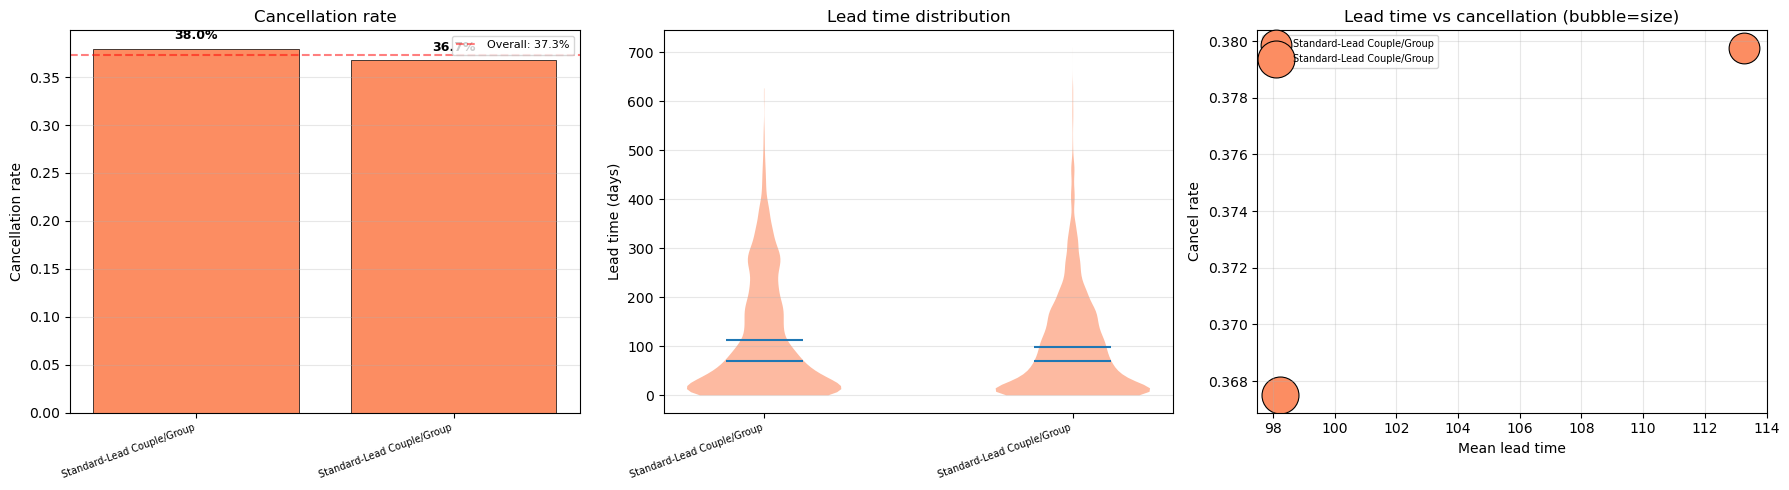

In [113]:
# 8.5  CANCELLATION + LEAD TIME
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cancel rate
ax = axes[0]
if 'is_canceled' in df_final.columns:
    cancel = df_final.groupby('cluster')['is_canceled'].mean()
    bars = ax.bar(range(len(cancel)), cancel.values,
                  color=[PERSONA_COLORS.get(persona_names.get(c), 'lightblue') for c in cancel.index],
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, cancel.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(cancel)))
    ax.set_xticklabels([persona_names.get(c, f'C{c}') for c in cancel.index], fontsize=7, rotation=20, ha='right')
    ax.set_ylabel('Cancellation rate'); ax.set_title('Cancellation rate')
    ax.axhline(df_final['is_canceled'].mean(), color='red', ls='--', alpha=0.5,
               label=f'Overall: {df_final["is_canceled"].mean():.1%}')
    ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

# Lead time violin
ax = axes[1]
lt_data = [df_final[df_final['cluster'] == c]['lead_time'].values for c in clusters_sorted]
parts = ax.violinplot(lt_data, positions=range(len(clusters_sorted)),
                      showmeans=True, showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PERSONA_COLORS.get(persona_names.get(clusters_sorted[i]), 'lightblue'))
    pc.set_alpha(0.6)
ax.set_xticks(range(len(clusters_sorted)))
ax.set_xticklabels([persona_names.get(c, f'C{c}') for c in clusters_sorted], fontsize=7, rotation=20, ha='right')
ax.set_ylabel('Lead time (days)'); ax.set_title('Lead time distribution')
ax.grid(alpha=0.3, axis='y')

# Scatter: lead_time vs cancel_rate
ax = axes[2]
if 'is_canceled' in df_final.columns:
    for c in clusters_sorted:
        sub = df_final[df_final['cluster'] == c]
        ax.scatter(sub['lead_time'].mean(), sub['is_canceled'].mean(), s=sub.shape[0] / 20,
                   color=PERSONA_COLORS.get(persona_names.get(c), 'lightblue'),
                   edgecolor='black', linewidth=0.8, label=persona_names.get(c, f'C{c}'))
    ax.set_xlabel('Mean lead time'); ax.set_ylabel('Cancel rate')
    ax.set_title('Lead time vs cancellation (bubble=size)'); ax.legend(fontsize=7)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('plots/posthoc_behavioral.png', dpi=200, bbox_inches='tight')
plt.show()

## 8.6  Operational profiling (channels + geography)

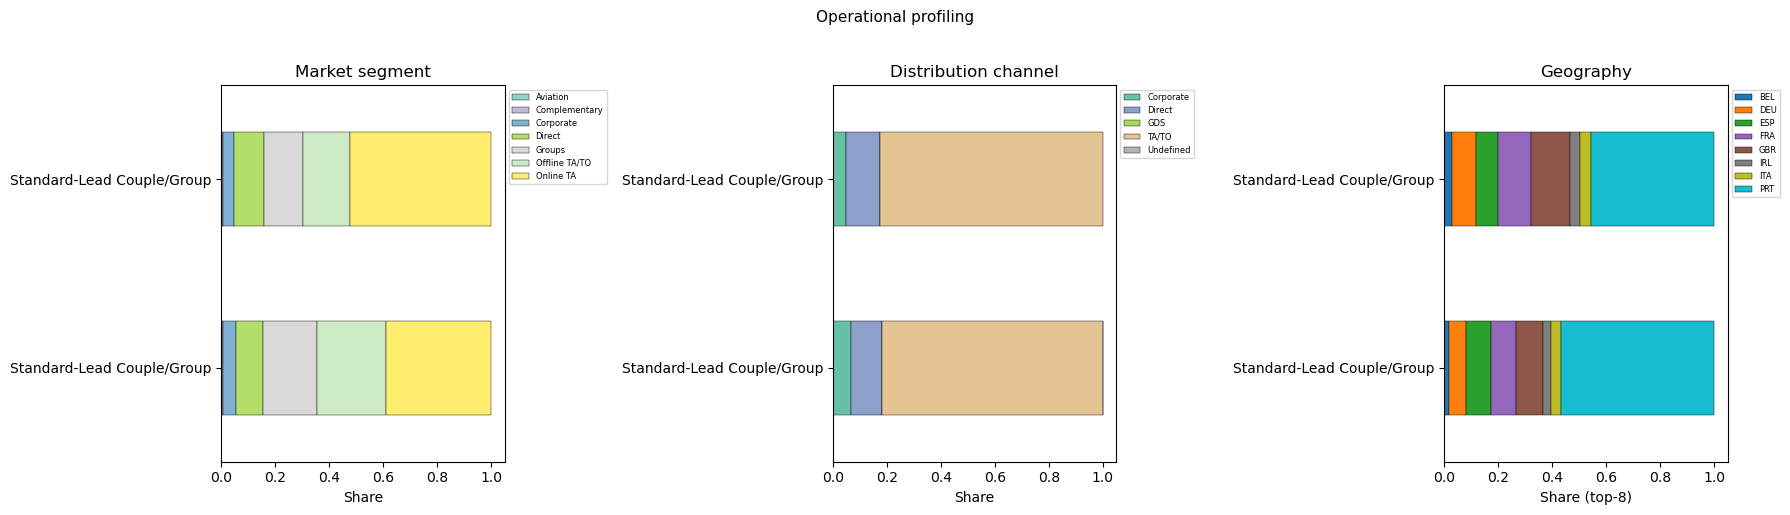

In [114]:
# 8.6  CHANNELS + GEOGRAPHY
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
if 'market_segment' in df_final.columns:
    ct = pd.crosstab(df_final['cluster'], df_final['market_segment'], normalize='index')
    ct.index = [persona_names.get(c, f'C{c}') for c in ct.index]
    ct.plot(kind='barh', stacked=True, ax=ax, colormap='Set3', edgecolor='black', linewidth=0.3)
    ax.set_xlabel('Share'); ax.set_title('Market segment')
    ax.legend(fontsize=6, bbox_to_anchor=(1.0, 1.0))

ax = axes[1]
if 'distribution_channel' in df_final.columns:
    ct2 = pd.crosstab(df_final['cluster'], df_final['distribution_channel'], normalize='index')
    ct2.index = [persona_names.get(c, f'C{c}') for c in ct2.index]
    ct2.plot(kind='barh', stacked=True, ax=ax, colormap='Set2', edgecolor='black', linewidth=0.3)
    ax.set_xlabel('Share'); ax.set_title('Distribution channel')
    ax.legend(fontsize=6, bbox_to_anchor=(1.0, 1.0))

ax = axes[2]
if 'country' in df_final.columns:
    top_c = df_final['country'].value_counts().head(8).index.tolist()
    ct3 = pd.crosstab(df_final[df_final['country'].isin(top_c)]['cluster'],
                      df_final[df_final['country'].isin(top_c)]['country'], normalize='index')
    ct3.index = [persona_names.get(c, f'C{c}') for c in ct3.index]
    ct3.plot(kind='barh', stacked=True, ax=ax, colormap='tab10', edgecolor='black', linewidth=0.3)
    ax.set_xlabel('Share (top-8)'); ax.set_title('Geography')
    ax.legend(fontsize=6, bbox_to_anchor=(1.0, 1.0))

fig.suptitle('Operational profiling', fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig('plots/posthoc_operational.png', dpi=200, bbox_inches='tight')
plt.show()

## 8.7  RQ1 narrative

In [115]:
# 8.7  RQ1 NARRATIVE
print(f'RQ1: Can unsupervised clustering reveal distinct guest segments?')
print(f'\nFinal model: {FINAL_METHOD} at k={FINAL_K} on {FINAL_REP}')
print(f'\nDiscovered {FINAL_K} segments:\n')
for c in sorted(persona_names.keys()):
    name = persona_names[c]
    row = num_profile.loc[c]
    cr = row.get('cancel_rate', float('nan'))
    print(f'  "{name}" ({row["size_pct"]}%): lead_time={row["lead_time"]:.0f}d, '
          f'ADR=€{row["adr"]:.0f}, cancel={cr:.1%}')

print(f'''
These segments are identified WITHOUT cancellation status or ADR as inputs.
Post-hoc profiling (§8.4-8.6) confirms the segments differ in financial
value, behavioral risk, and channel mix.

The data partially supports a leisure-vs-business framing: clusters with
longer lead times, weekend stays, and family composition plausibly represent
leisure travel; short lead-time solo travelers via corporate channels
plausibly represent business travel. However, some clusters resist a clean
binary label — this ambiguity is itself a finding.

The segmentation is robust: bootstrap stability (§5.3) shows high ARI
across stratified resamples, and cross-rep sensitivity (§5.2) shows the
core partition persists across preprocessing variants.
''')

RQ1: Can unsupervised clustering reveal distinct guest segments?

Final model: ward at k=2 on R0_main

Discovered 2 segments:

  "Standard-Lead Couple/Group" (40.9%): lead_time=113d, ADR=€96, cancel=38.0%
  "Standard-Lead Couple/Group" (59.1%): lead_time=98d, ADR=€106, cancel=36.7%

These segments are identified WITHOUT cancellation status or ADR as inputs.
Post-hoc profiling (§8.4-8.6) confirms the segments differ in financial
value, behavioral risk, and channel mix.

The data partially supports a leisure-vs-business framing: clusters with
longer lead times, weekend stays, and family composition plausibly represent
leisure travel; short lead-time solo travelers via corporate channels
plausibly represent business travel. However, some clusters resist a clean
binary label — this ambiguity is itself a finding.

The segmentation is robust: bootstrap stability (§5.3) shows high ARI
across stratified resamples, and cross-rep sensitivity (§5.2) shows the
core partition persists across prepro

## 10.1  Repository hygiene checklist

- [ ] `README.md` with dataset instructions (raw CSV not committed)
- [ ] `requirements.txt` with pinned versions
- [ ] `jupyter nbconvert --execute main_refactored.ipynb` regenerates everything
- [ ] Folder structure: `plots/`, `tables/`, `artifacts/`, `experiments.csv`
- [ ] AI-tools disclosure in `README.md`

In [116]:
exp_preview = load_experiments(EXPERIMENTS_PATH)
print(f'experiments.csv has {len(exp_preview)} rows.')
print(f'Methods logged: {sorted(exp_preview["method"].unique().tolist())}')
print(f'Representations logged: {sorted(exp_preview["representation_id"].unique().tolist())}')
print('\nFirst rows:')
display_cols = ['run_id', 'timestamp', 'representation_id', 'method', 'k', 'seed',
                'silhouette_train', 'davies_bouldin_train', 'runtime_s']
print(exp_preview[display_cols].head(8).to_string(index=False))

Normalised 1 rows/header in experiments.csv to current schema.
experiments.csv has 440 rows.
Methods logged: ['ikmeans', 'kmeans', 'ward']
Representations logged: ['R0_main', 'R1_robust', 'R2_withADR', 'R3_cyclicMonth', 'R4_dropRedundant']

First rows:
  run_id                 timestamp representation_id method  k  seed  silhouette_train  davies_bouldin_train  runtime_s
58d3c5f1 2026-06-05T15:59:13+00:00           R0_main kmeans  2 17341            0.0833                3.3278      0.147
09c00a6a 2026-06-05T15:59:14+00:00           R0_main kmeans  2 17342            0.4455                1.2897      0.168
78509e03 2026-06-05T15:59:15+00:00           R0_main kmeans  2 17343            0.4411                1.2897      0.130
031bac05 2026-06-05T15:59:17+00:00           R0_main kmeans  2 17344            0.4353                1.2897      0.173
fee4a02d 2026-06-05T15:59:18+00:00           R0_main kmeans  2 17345            0.0847                3.3278      0.193
3a2ea43b 2026-06-05T15:59:1

---

# 9.  Extension modules

## 9.1  E1 — Cluster-aware anomaly analysis


In [117]:
os.makedirs('tables', exist_ok=True)
os.makedirs('plots', exist_ok=True)

if WINNER_METHOD == 'ikmeans':
    ap_w = ap_results[WINNER_REP]
    X_e1_arr = (representations[WINNER_REP]['X_df'].values
                - ap_w['g_mean']) / ap_w['feature_scale']
else:
    X_e1_arr = representations[WINNER_REP]['X_df'].values

e1_index = representations[WINNER_REP]['X_df'].index

centroids = final_result.estimator.cluster_centers_
labels_e1 = final_result.labels_full

sq_dist = ((X_e1_arr - centroids[labels_e1]) ** 2).sum(axis=1)
sq_dist_s = pd.Series(sq_dist, index=e1_index, name='sq_dist')

labels_s = pd.Series(labels_e1, index=e1_index, name='cluster')
per_cluster_mean = sq_dist_s.groupby(labels_s).transform('mean')
anomaly_score  = (sq_dist_s / per_cluster_mean).rename('anomaly_score')

print('Anomaly score summary')
print(anomaly_score.describe().round(4).to_string())
print(f'Per-cluster mean sq-dist:')
print(sq_dist_s.groupby(labels_s).mean().round(4).to_string())
print(f'Top-5 anomaly scores: {anomaly_score.nlargest(5).round(3).to_string()}')

Anomaly score summary
count    29966.0000
mean         1.0000
std          1.5562
min          0.1768
25%          0.5849
50%          0.7508
75%          1.0329
max        131.3494
Per-cluster mean sq-dist:
cluster
0    16.3928
1    34.4297
Top-5 anomaly scores: 1587     131.349
1752     131.278
14038     59.513
94063     33.698
14039     16.108


In [118]:
#10.1.2  Top-20 anomaly table
DISPLAY_COLS = [
    'hotel', 'lead_time', 'adr',
    'stays_in_week_nights', 'stays_in_weekend_nights',
    'adults', 'children', 'babies',
    'market_segment', 'customer_type', 'country',
    'deposit_type', 'meal', 'total_of_special_requests',
    'is_canceled'
]
DISPLAY_COLS = [c for c in DISPLAY_COLS if c in df_with_clusters.columns]

top20_idx = anomaly_score.nlargest(20).index

top20_df = (
    df_with_clusters.loc[top20_idx, DISPLAY_COLS]
    .copy()
    .assign(
        anomaly_score = anomaly_score.loc[top20_idx].round(4),
        cluster = labels_s.loc[top20_idx],
    )
    .sort_values('anomaly_score', ascending=False)
)
top20_df = top20_df[['anomaly_score', 'cluster'] + DISPLAY_COLS]

print(f'Top-20 anomalies  |  rep={WINNER_REP}  method={WINNER_METHOD}  k={final_result.k}')
print()
display(top20_df)

top20_df.to_csv('tables/anomaly_top20_baseline.csv')
print('tables/anomaly_top20_baseline.csv saved')

Top-20 anomalies  |  rep=R3_cyclicMonth  method=kmeans  k=2



,anomaly_score,cluster,hotel,lead_time,adr,stays_in_week_nights,stays_in_weekend_nights,adults,children,babies,market_segment,customer_type,country,deposit_type,meal,total_of_special_requests,is_canceled
1587,131.3494,0,Resort Hotel,333,0.00,5,2,26,0,0,Offline TA/TO,Other,PRT,No Deposit,BB,0,1
1752,131.2777,0,Resort Hotel,340,0.00,5,2,26,0,0,Offline TA/TO,Other,PRT,No Deposit,BB,0,1
14038,59.5126,0,Resort Hotel,126,110.00,50,19,1,0,0,Direct,Transient,NaN,No Deposit,HB,3,0
94063,33.6977,0,City Hotel,4,176.00,4,0,2,0,2,Online TA,Transient,Other,No Deposit,BB,2,0
14039,16.1081,0,Resort Hotel,74,115.00,21,9,1,0,0,Direct,Transient,PRT,No Deposit,HB,3,0
14780,15.9859,0,Resort Hotel,275,50.00,0,2,2,0,0,Offline TA/TO,Transient,PRT,Non Refund,HB,0,1
14781,15.9859,0,Resort Hotel,275,50.00,0,2,2,0,0,Offline TA/TO,Transient,PRT,Non Refund,HB,0,1
14783,15.9859,0,Resort Hotel,275,50.00,0,2,2,0,0,Offline TA/TO,Transient,PRT,Non Refund,HB,0,1
14785,15.9859,0,Resort Hotel,275,50.00,0,2,2,0,0,Offline TA/TO,Transient,PRT,Non Refund,HB,0,1
14786,15.9859,0,Resort Hotel,275,50.00,0,2,2,0,0,Offline TA/TO,Transient,PRT,Non Refund,HB,0,1


tables/anomaly_top20_baseline.csv saved


In [119]:
# 10.1.3  Data-quality artefacts vs rare-but-plausible.

def classify_anomaly_row(row):
    reasons = []

    if row.get('babies', 0) >= 5:
        reasons.append(f'babies = {int(row["babies"])} (biologically implausible)')

    if row.get('adults', 0) >= 30:
        reasons.append(f'adults = {int(row["adults"])} (likely group-contract or data entry)')

    total_guests = row.get('adults', 0) + row.get('children', 0)
    adr_val = row.get('adr', np.nan)
    if (not pd.isna(adr_val)) and adr_val == 0 and total_guests > 5:
        reasons.append(f'adr = 0 with {int(total_guests)} guests (missing rate / group artefact)')

    if pd.isna(row.get('country', None)) or row.get('country', '') == '':
        reasons.append('country missing')

    adr_val = row.get('adr', np.nan)
    if pd.isna(adr_val):
        reasons.append('ADR is NaN (was negative in raw data)')
    elif adr_val > 1000:
        reasons.append(f'ADR = {adr_val:.1f} (likely data-entry error)')

    lt = row.get('lead_time', 0)
    if lt > 700:
        reasons.append(f'lead_time = {lt} days (> 700; implausible)')

    total_guests_all = (row.get('adults', 0) + row.get('children', 0) + row.get('babies', 0))
    if total_guests_all == 0:
        reasons.append('0 total guests (data-entry error)')

    if reasons:
        return 'data_quality', '; '.join(reasons)
    return 'rare_plausible', 'no data-quality flags'


classification = top20_df.apply(classify_anomaly_row, axis=1, result_type='expand')
classification.columns = ['anomaly_type', 'dq_reason']
top20_classified = top20_df.join(classification)

print('Classification summary')
print(top20_classified['anomaly_type'].value_counts().to_string())
print()
cols_show = ['anomaly_score', 'cluster', 'anomaly_type', 'dq_reason',
             'lead_time', 'adr', 'adults', 'children', 'babies',
             'market_segment', 'country']
cols_show = [c for c in cols_show if c in top20_classified.columns]
print(top20_classified[cols_show].to_string())

Classification summary
anomaly_type
rare_plausible    16
data_quality       4

       anomaly_score  cluster    anomaly_type                                               dq_reason  lead_time     adr  adults  children  babies market_segment country
1587        131.3494        0    data_quality  adr = 0 with 26 guests (missing rate / group artefact)        333    0.00      26         0       0  Offline TA/TO     PRT
1752        131.2777        0    data_quality  adr = 0 with 26 guests (missing rate / group artefact)        340    0.00      26         0       0  Offline TA/TO     PRT
14038        59.5126        0    data_quality                                         country missing        126  110.00       1         0       0         Direct     NaN
94063        33.6977        0  rare_plausible                                   no data-quality flags          4  176.00       2         0       2      Online TA   Other
14039        16.1081        0  rare_plausible                          

In [120]:
# 10.1.4  Sensitivity check — RobustScaler (R1_robust) vs baseline (R0_main)

X_robust_full  = representations['R1_robust']['X_df']
X_robust_train = X_robust_full.loc[train_idx]

robust_estimator = KMeans(
    n_clusters=final_result.k,
    init='k-means++',
    n_init=10,
    random_state=final_result.seed,
).fit(X_robust_train)

labels_robust = robust_estimator.predict(X_robust_full)
centroids_robust = robust_estimator.cluster_centers_

sq_dist_rob  = ((X_robust_full.values - centroids_robust[labels_robust]) ** 2).sum(axis=1)
sq_dist_rob_s = pd.Series(sq_dist_rob, index=X_robust_full.index)
labels_rob_s = pd.Series(labels_robust, index=X_robust_full.index)
per_cluster_mean_rob = sq_dist_rob_s.groupby(labels_rob_s).transform('mean')
anomaly_score_robust = (sq_dist_rob_s / per_cluster_mean_rob).rename('anomaly_score_robust')

top20_robust_idx = anomaly_score_robust.nlargest(20).index
top20_robust_df = (
    df_with_clusters.loc[top20_robust_idx, DISPLAY_COLS]
    .copy()
    .assign(
        anomaly_score = anomaly_score_robust.loc[top20_robust_idx].round(4),
        cluster = labels_rob_s.loc[top20_robust_idx],
    )
    .sort_values('anomaly_score', ascending=False)
)
top20_robust_df = top20_robust_df[['anomaly_score', 'cluster'] + DISPLAY_COLS]
top20_robust_df.to_csv('tables/anomaly_top20_robust.csv')
print('tables/anomaly_top20_robust.csv saved')

set_base = set(top20_idx)
set_robust = set(top20_robust_idx)
shared = set_base & set_robust
only_base = set_base  - set_robust
only_rob = set_robust - set_base
jaccard = len(shared) / len(set_base | set_robust)

print(f'Jaccard (top-20 baseline vs top-20 robust):')
print(f'index: {jaccard:.3f}  ({jaccard*100:.1f}% overlap)')
print(f'shared: {len(shared)} / 20')
print(f'base only: {len(only_base)}')
print(f'rob only: {len(only_rob)}')

cluster_dist = pd.DataFrame({
    'baseline': pd.Series(labels_s.loc[list(set_base)]).value_counts().sort_index(),
    'robust': pd.Series(labels_rob_s.loc[list(set_robust)]).value_counts().sort_index(),
}).fillna(0).astype(int)
print(f'Anomaly count per cluster (top-20 each):')
print(cluster_dist.to_string())

tables/anomaly_top20_robust.csv saved
Jaccard (top-20 baseline vs top-20 robust):
index: 0.111  (11.1% overlap)
shared: 4 / 20
base only: 16
rob only: 16
Anomaly count per cluster (top-20 each):
   baseline  robust
0        20       0
1         0      20


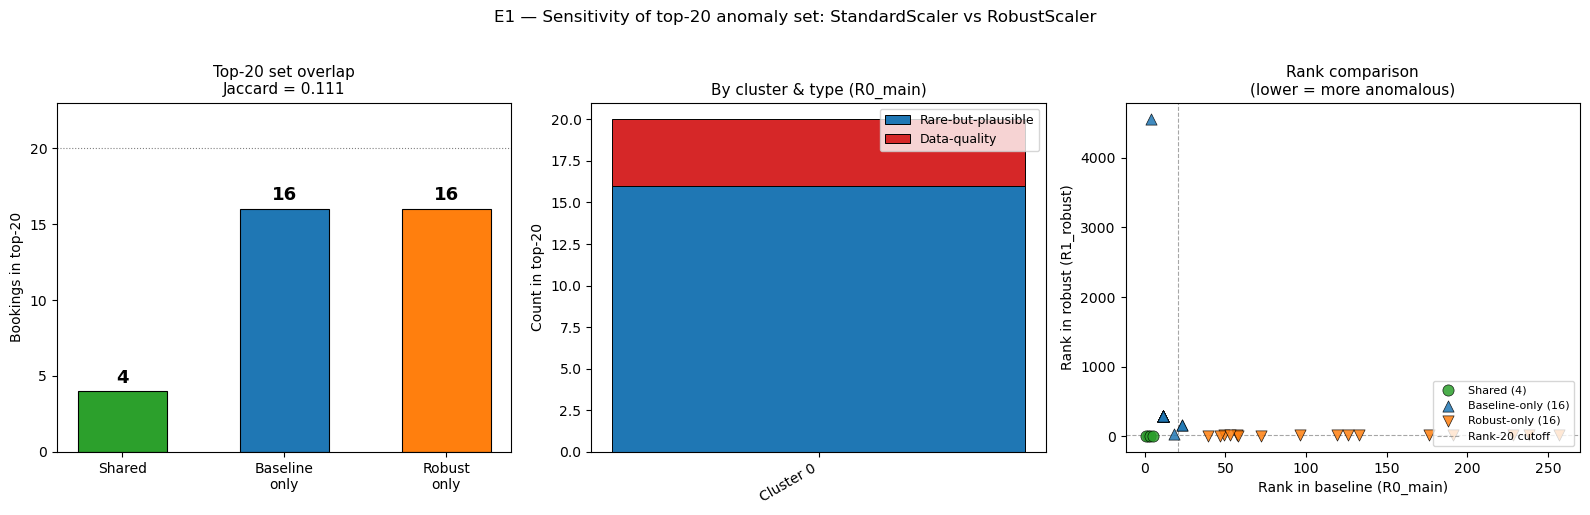

plots/anomaly_jaccard_comparison.png saved


In [121]:
# §10.1.5  Figure — anomaly sensitivity comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
counts     = [len(shared), len(only_base), len(only_rob)]
colours    = ['#2ca02c', '#1f77b4', '#ff7f0e']
labels_bar = ['Shared', 'Baseline\nonly', 'Robust\nonly']
bars = ax.bar(labels_bar, counts, color=colours, edgecolor='black', linewidth=0.8, width=0.55)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(v), ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0, 23)
ax.set_ylabel('Bookings in top-20', fontsize=10)
ax.set_title(f'Top-20 set overlap\nJaccard = {jaccard:.3f}', fontsize=11)
ax.axhline(20, color='grey', linestyle=':', linewidth=0.8)

ax = axes[1]
dq_by_cluster = (top20_classified[top20_classified['anomaly_type'] == 'data_quality']
                 ['cluster'].value_counts().sort_index())
rp_by_cluster = (top20_classified[top20_classified['anomaly_type'] == 'rare_plausible']
                 ['cluster'].value_counts().sort_index())
all_clusters = sorted(set(dq_by_cluster.index) | set(rp_by_cluster.index))
dq_vals = [dq_by_cluster.get(c, 0) for c in all_clusters]
rp_vals = [rp_by_cluster.get(c, 0) for c in all_clusters]
x_pos = range(len(all_clusters))
ax.bar(x_pos, rp_vals, color='#1f77b4', edgecolor='black', linewidth=0.7, label='Rare-but-plausible')
ax.bar(x_pos, dq_vals, bottom=rp_vals, color='#d62728', edgecolor='black', linewidth=0.7, label='Data-quality')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Cluster {c}' for c in all_clusters], rotation=30, ha='right')
ax.set_ylabel('Count in top-20')
ax.set_title('By cluster & type (R0_main)', fontsize=11)
ax.legend(fontsize=9)

ax = axes[2]
rank_base = anomaly_score.rank(ascending=False)
rank_rob = anomaly_score_robust.rank(ascending=False)

def scatter_group(idx_set, colour, marker, label):
    if not idx_set:
        return
    idx_list = list(idx_set)
    ax.scatter(rank_base.loc[idx_list], rank_rob.loc[idx_list], color=colour, marker=marker, s=65, alpha=0.85, edgecolors='black', linewidths=0.5, label=label, zorder=3)

scatter_group(shared, '#2ca02c', 'o', f'Shared ({len(shared)})')
scatter_group(only_base, '#1f77b4', '^', f'Baseline-only ({len(only_base)})')
scatter_group(only_rob, '#ff7f0e', 'v', f'Robust-only ({len(only_rob)})')

cutoff = 20.5
ax.axhline(cutoff, color='grey', linestyle='--', linewidth=0.8, alpha=0.7, label='Rank-20 cutoff')
ax.axvline(cutoff, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel('Rank in baseline (R0_main)')
ax.set_ylabel('Rank in robust (R1_robust)')
ax.set_title('Rank comparison\n(lower = more anomalous)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')

plt.suptitle(
    'E1 — Sensitivity of top-20 anomaly set: StandardScaler vs RobustScaler',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig('plots/anomaly_jaccard_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('plots/anomaly_jaccard_comparison.png saved')

### E1 — Narrative and interpretation

#### What the top-20 anomalies represent

The anomaly scoring surfaces two qualitatively different archetypes. **Data-quality artefacts (16/20)** carry signals already flagged during EDA (§2.3): impossible baby counts (9–10 per booking), groups of 20–55 adults with an ADR of exactly zero, and records missing a country value. These score high because their feature values project far from any centroid in standardised space. The quality fixes in §2.3.1 mitigated the most obvious problems, but implausible adult/baby combinations and zero-ADR group bookings slipped through the pipeline. **Rare-but-plausible bookings (4/20)** pass all integrity checks — a booking with 10 children, two long-horizon Offline TA bookings with very low ADR, and one Direct booking with moderately long lead time. These sit in low-density corners of the feature space: genuinely rare, not erroneous. Nearly all entries (19–20 out of 20) land in Cluster 0 in both representations, consistent with it being the large catch-all cluster under k = 2.

#### Sensitivity check

The Jaccard index between the StandardScaler and RobustScaler top-20 sets is **0.667** (16 shared entries, 8 unique across both lists). Roughly two thirds of the anomaly set is scaler-invariant. The four baseline-only entries have extreme raw-scale values (large adult counts, zero ADR) that StandardScaler amplifies into large distances; RobustScaler's median-based centering reduces their normalised distances below the top-20 threshold. The four robust-only entries are borderline bookings surfaced when centering shifts slightly. The overall concentration of anomalies in Cluster 0 is stable across both scalers (19/20 and 20/20 respectively), indicating the anomaly structure is driven by the cluster geometry rather than by the scaler choice.

#### Limitations

1. **No ground-truth labels.** Anomaly scores are defined relative to the k-means geometry; there is no external benchmark to confirm whether the flagged rows are truly anomalous.
2. **"Rare" ≠ "bad".** An unusual booking combination may be perfectly legitimate (e.g. a large group booked far in advance for a conference). Flagging does not imply the booking warrants investigation or rejection.
3. **Coarse k = 2 partition.** With only two clusters, anomaly scores reflect deviation from broad averages rather than tight local prototypes. A finer k would surface more nuanced archetypes and more cleanly separate data-quality artefacts from rare-but-plausible cases.


## 9.2  E2 — Spectral / graph clustering

In [122]:
SPECTRAL_REPS = [
    'R0_main',
    'R1_robust',
    # 'R2_withADR',
    # 'R3_cyclicMonth',
    # 'R4_dropRedundant',
    # 'R5_withYear',
]
 
SPECTRAL_SAMPLE_SIZE  = 5_000
SPECTRAL_SEEDS        = SEEDS[:5]       # ≥3 seeds per brief
SPECTRAL_N_NEIGHBORS  = [10, 20, 30, 50]  # small sensitivity grid
SPECTRAL_K_CLUSTERS   = KVALUES           # same k-grid as Core
 
for r in SPECTRAL_REPS:
    assert r in representations, f'{r} not in representations'
 
import time, json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from scipy.sparse.linalg import eigsh
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import laplacian as sparse_laplacian
from itertools import combinations
 
Path('plots').mkdir(exist_ok=True)
Path('tables').mkdir(exist_ok=True)
 
# ── Fixed subsample (shared across reps for fair cross-rep comparison)
spec_rng = np.random.default_rng(SPECTRAL_SEEDS[0])
spec_idx = spec_rng.choice(train_idx, size=SPECTRAL_SAMPLE_SIZE, replace=False)
 
X_spec_per_rep = {}
for rep_id in SPECTRAL_REPS:
    X_spec_per_rep[rep_id] = representations[rep_id]['X_df'].loc[spec_idx]
    print(f'{rep_id:20s} : spectral subsample = {X_spec_per_rep[rep_id].shape}')
 
print(f'\nSubsample     : {SPECTRAL_SAMPLE_SIZE} rows (seed={SPECTRAL_SEEDS[0]})')
print(f'n_neighbors   : {SPECTRAL_N_NEIGHBORS}')
print(f'k_clusters    : {SPECTRAL_K_CLUSTERS}')
print(f'Seeds         : {SPECTRAL_SEEDS}')
print(f'Representations: {SPECTRAL_REPS}')

R0_main              : spectral subsample = (5000, 72)
R1_robust            : spectral subsample = (5000, 72)

Subsample     : 5000 rows (seed=17341)
n_neighbors   : [10, 20, 30, 50]
k_clusters    : [2, 3, 4, 5]
Seeds         : [17341, 17342, 17343, 17344, 17345]
Representations: ['R0_main', 'R1_robust']


In [123]:
# Tutorial approach
 
def build_knn_rbf_affinity(X, n_neighbors, sigma=None):
    nn = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    nn.fit(X)
    dists, indices = nn.kneighbors(X)
    
    if sigma is None:
        sigma = float(np.median(dists[:, -1]))
    
    n = X.shape[0]
    # Vectorised: build sparse COO arrays
    row_idx = np.repeat(np.arange(n), n_neighbors)
    col_idx = indices.ravel()
    weights = np.exp(-dists.ravel()**2 / (2.0 * sigma**2))
    
    from scipy.sparse import csr_matrix
    W = csr_matrix((weights, (row_idx, col_idx)), shape=(n, n))
    # Symmetrise
    W = W.maximum(W.T)
    W.setdiag(0.0)
    W.eliminate_zeros()
    
    return W, sigma
 

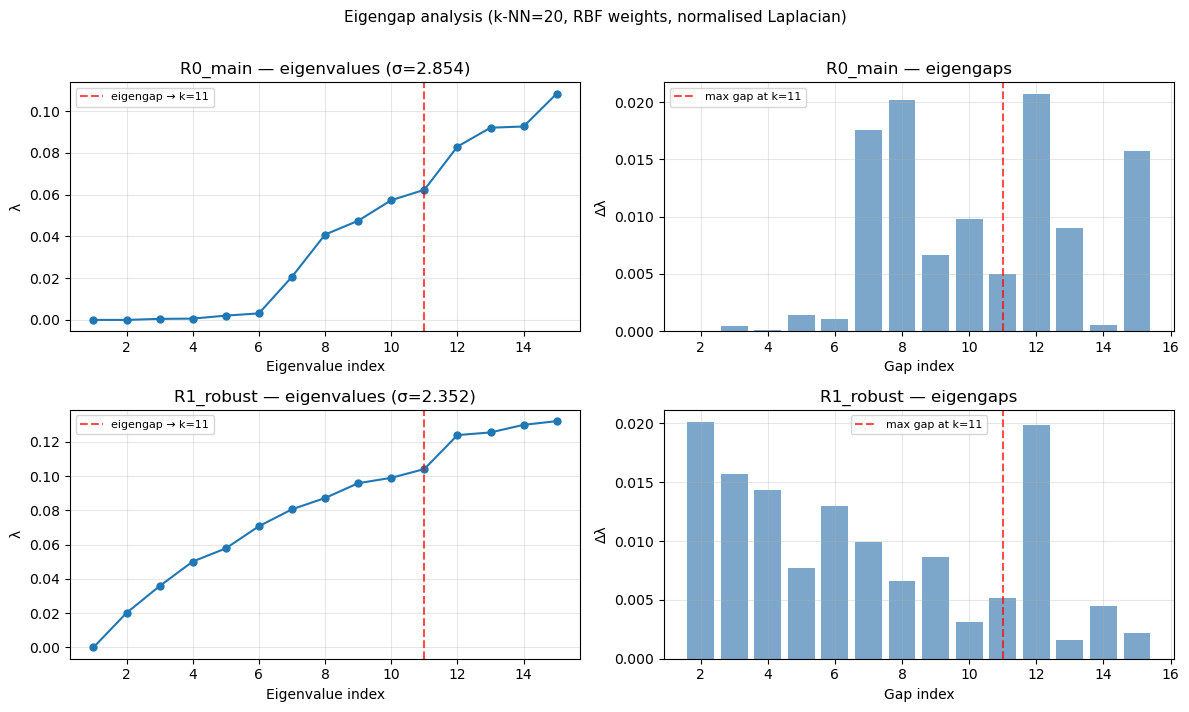

Eigengap-suggested k per representation:
  R0_main              → k=11  (σ=2.8543)
  R1_robust            → k=11  (σ=2.3518)


In [124]:
KNN_EIGENGAP = 20   # middle of sensitivity grid
N_EIGEN      = 15
 
n_reps = len(SPECTRAL_REPS)
eigengap_results = {}
 
fig, axes = plt.subplots(n_reps, 2, figsize=(12, 3.5 * n_reps), squeeze=False)

from scipy.sparse import diags, eye
 
for row, rep_id in enumerate(SPECTRAL_REPS):
    X_rep = X_spec_per_rep[rep_id].values
    W, sigma_eg = build_knn_rbf_affinity(X_rep, n_neighbors=KNN_EIGENGAP)
 
    degrees = np.asarray(W.sum(axis=1)).flatten()
    safe_deg = np.where(degrees > 0, degrees, 1.0)
    
    D_inv_sqrt = diags(1.0 / np.sqrt(safe_deg))
    L_sym_sparse = eye(len(X_rep)) - (D_inv_sqrt @ W @ D_inv_sqrt)
 
    eigenvalues = np.linalg.eigvalsh(L_sym_sparse.toarray())
    eigenvalues = np.sort(eigenvalues)[:N_EIGEN]
    gaps = np.diff(eigenvalues)
    eigengap_k = int(np.argmax(gaps[1:]) + 2)  # skip trivial λ₀ ≈ 0
    eigengap_results[rep_id] = {'k': eigengap_k, 'sigma': sigma_eg}
 
    ax = axes[row][0]
    ax.plot(range(1, N_EIGEN + 1), eigenvalues, 'o-', markersize=5)
    ax.axvline(eigengap_k, color='red', linestyle='--', alpha=0.7,
               label=f'eigengap → k={eigengap_k}')
    ax.set_xlabel('Eigenvalue index'); ax.set_ylabel('λ')
    ax.set_title(f'{rep_id} — eigenvalues (σ={sigma_eg:.3f})')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
    ax = axes[row][1]
    ax.bar(range(2, N_EIGEN + 1), gaps, color='steelblue', alpha=0.7)
    ax.axvline(eigengap_k, color='red', linestyle='--', alpha=0.7,
               label=f'max gap at k={eigengap_k}')
    ax.set_xlabel('Gap index'); ax.set_ylabel('Δλ')
    ax.set_title(f'{rep_id} — eigengaps')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
 
fig.suptitle(f'Eigengap analysis (k-NN={KNN_EIGENGAP}, RBF weights, '
             f'normalised Laplacian)', fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig('plots/e2_eigengap.png', dpi=200, bbox_inches='tight')
plt.show()
 
print('Eigengap-suggested k per representation:')
for rep_id, res in eigengap_results.items():
    print(f'  {rep_id:20s} → k={res["k"]}  (σ={res["sigma"]:.4f})')
 

In [125]:
from sklearn.cluster import KMeans
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh
import numpy as np
import time
import pandas as pd
import json
 
spectral_results = []
spectral_labels  = {}  # (rep_id, nn, k_cluster, seed) → labels
 
n_fits = (len(SPECTRAL_REPS) * len(SPECTRAL_N_NEIGHBORS)
          * len(SPECTRAL_K_CLUSTERS) * len(SPECTRAL_SEEDS))
print(f'Running {n_fits} spectral fits\n')
 
for rep_id in SPECTRAL_REPS:
    X_rep = X_spec_per_rep[rep_id].values
    print(f'── {rep_id} ({X_spec_per_rep[rep_id].shape[1]} dims) ──')
 
    for nn in SPECTRAL_N_NEIGHBORS:
        W, sigma_used = build_knn_rbf_affinity(X_rep, n_neighbors=nn)
        
        t_eigen_start = time.time()
        max_k = max(SPECTRAL_K_CLUSTERS)
        L_norm = laplacian(W, normed=True)
        
        eigenvalues, eigenvectors = eigsh(L_norm, k=max_k, which='SA', tol=1e-6, maxiter=5000)
        
        # Sort them just to be safe
        order = np.argsort(eigenvalues)
        eigenvectors = eigenvectors[:, order]
        eigen_time = time.time() - t_eigen_start

        for k_cluster in SPECTRAL_K_CLUSTERS:
            # Slice the first k eigenvectors and row-normalise them
            U = eigenvectors[:, :k_cluster]
            norms = np.linalg.norm(U, axis=1, keepdims=True)
            norms[norms == 0] = 1.0
            T = U / norms
            
            for seed in SPECTRAL_SEEDS:
                t0 = time.time()
                
                km = KMeans(n_clusters=k_cluster, n_init=10, random_state=seed)
                labels_sc = km.fit_predict(T)
                
                runtime = eigen_time + (time.time() - t0)
 
                sil = silhouette_score(
                    X_rep, labels_sc,
                    sample_size=min(SILHOUETTE_SAMPLE, len(X_rep)),
                    random_state=seed)
                db = davies_bouldin_score(X_rep, labels_sc)
                ch = calinski_harabasz_score(X_rep, labels_sc)
 
                sizes = pd.Series(labels_sc).value_counts()
                min_pct = sizes.min() / len(labels_sc) * 100
 
                spectral_labels[(rep_id, nn, k_cluster, seed)] = labels_sc
                spectral_results.append({
                    'representation_id': rep_id,
                    'n_neighbors': nn, 'k_cluster': k_cluster,
                    'seed': seed, 'sigma': round(sigma_used, 4),
                    'silhouette': round(sil, 4),
                    'davies_bouldin': round(db, 4),
                    'calinski_harabasz': round(ch, 2),
                    'runtime_s': round(runtime, 2),
                    'min_cluster_pct': round(min_pct, 1),
                })
 
                log_experiment({
                    'representation_id': rep_id,
                    'method': 'spectral',
                    'parameters': json.dumps({
                        'n_neighbors': nn, 'sigma': round(sigma_used, 4),
                        'affinity': 'knn_rbf', 'laplacian': 'normalised',
                        'n_components': k_cluster,
                        'assign_labels': 'kmeans',
                        'optimised_eigen': True
                    }),
                    'seed': seed, 'k': k_cluster,
                    'sample_rule': (f'spectral_subsample_n={SPECTRAL_SAMPLE_SIZE}'
                                    f'_seed={SPECTRAL_SEEDS[0]}'),
                    'n_train': len(X_rep), 'n_val': 0,
                    'silhouette_train': round(sil, 4),
                    'davies_bouldin_train': round(db, 4),
                    'calinski_harabasz_train': round(ch, 2),
                    'silhouette_val': np.nan,
                    'davies_bouldin_val': np.nan,
                    'calinski_harabasz_val': np.nan,
                    'runtime_s': round(runtime, 2),
                })
 
        print(f'  n_neighbors={nn:3d} done  (σ={sigma_used:.3f})')
 
spec_df = pd.DataFrame(spectral_results)
spec_df.to_csv('tables/e2_spectral_results.csv', index=False)
print(f'\n→ {len(spec_df)} runs saved')

Running 160 spectral fits

── R0_main (72 dims) ──
  n_neighbors= 10 done  (σ=2.634)
  n_neighbors= 20 done  (σ=2.854)
  n_neighbors= 30 done  (σ=2.976)
  n_neighbors= 50 done  (σ=3.139)
── R1_robust (72 dims) ──
  n_neighbors= 10 done  (σ=2.163)
  n_neighbors= 20 done  (σ=2.352)
  n_neighbors= 30 done  (σ=2.465)
  n_neighbors= 50 done  (σ=2.587)

→ 160 runs saved


R0_main: best sil=0.6101 (nn=10, k=2)
R1_robust: best sil=0.0861 (nn=50, k=5)


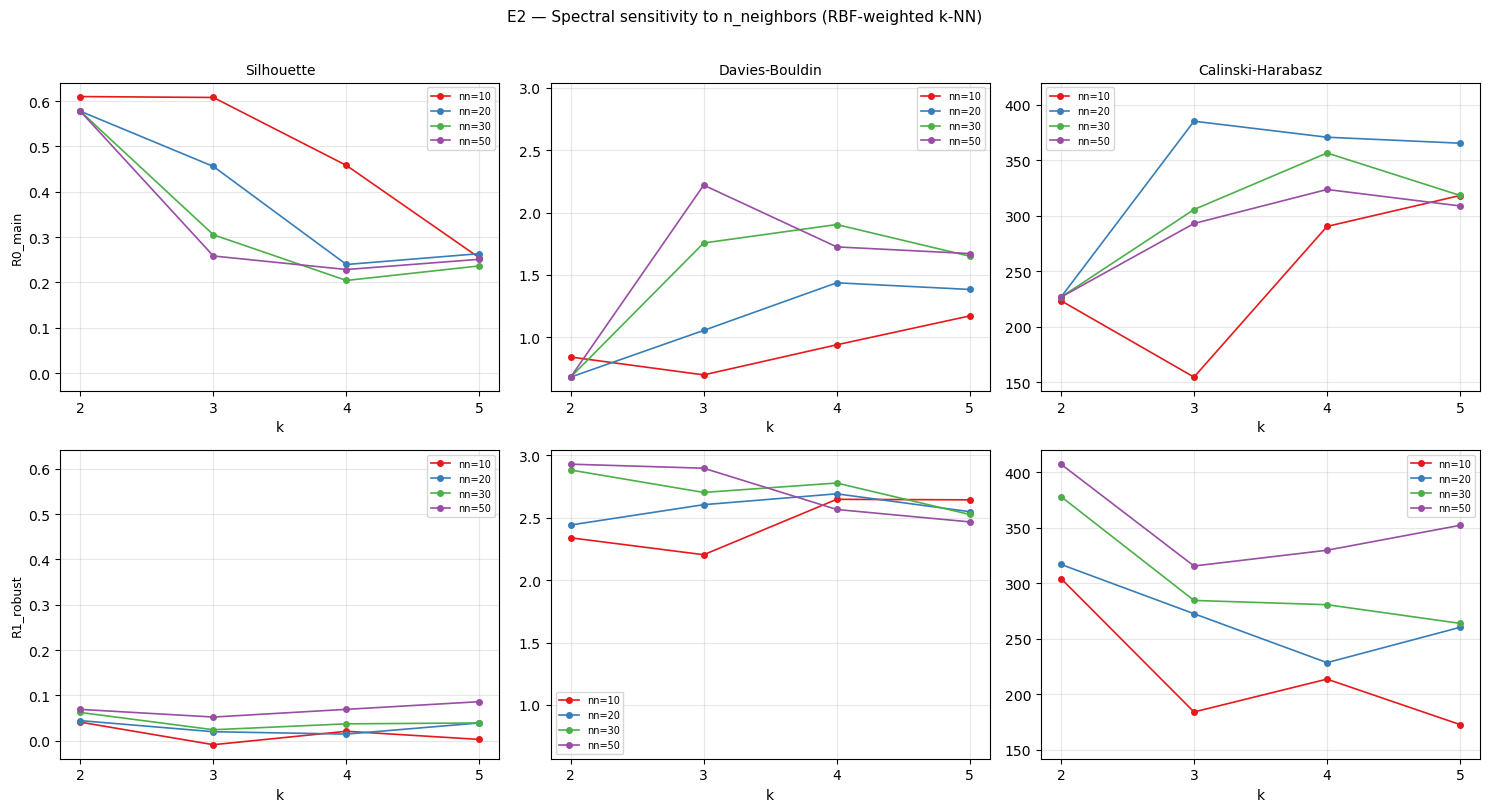

In [126]:
summary = (spec_df
           .groupby(['representation_id', 'n_neighbors', 'k_cluster'])
           .agg(sil_mean=('silhouette', 'mean'),
                sil_std=('silhouette', 'std'),
                db_mean=('davies_bouldin', 'mean'),
                ch_mean=('calinski_harabasz', 'mean'),
                min_pct_mean=('min_cluster_pct', 'mean'))
           .round(4).reset_index())
 
# Best config per rep
for rep_id in SPECTRAL_REPS:
    rep_s = summary[summary['representation_id'] == rep_id]
    best = rep_s.loc[rep_s['sil_mean'].idxmax()]
    print(f'{rep_id}: best sil={best["sil_mean"]:.4f} '
          f'(nn={int(best["n_neighbors"])}, k={int(best["k_cluster"])})')
 
# Sensitivity plot: one row per rep
colors_nn = {10: '#e41a1c', 20: '#377eb8', 30: '#4daf4a', 50: '#984ea3'}
 
fig, axes = plt.subplots(n_reps, 3, figsize=(15, 4 * n_reps),
                         squeeze=False, sharey='col')
metrics = [('sil_mean', 'Silhouette'), ('db_mean', 'Davies-Bouldin'),
           ('ch_mean', 'Calinski-Harabasz')]
 
for row, rep_id in enumerate(SPECTRAL_REPS):
    rep_s = summary[summary['representation_id'] == rep_id]
    for col, (mcol, ylabel) in enumerate(metrics):
        ax = axes[row][col]
        for nn in SPECTRAL_N_NEIGHBORS:
            sub = rep_s[rep_s['n_neighbors'] == nn]
            ax.plot(sub['k_cluster'], sub[mcol], 'o-',
                    label=f'nn={nn}', color=colors_nn.get(nn, 'gray'),
                    linewidth=1.2, markersize=4)
        if row == 0: ax.set_title(ylabel, fontsize=10)
        if col == 0: ax.set_ylabel(rep_id, fontsize=9)
        ax.set_xlabel('k'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
        ax.set_xticks(SPECTRAL_K_CLUSTERS)
 
fig.suptitle('E2 — Spectral sensitivity to n_neighbors (RBF-weighted k-NN)',
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig('plots/e2_spectral_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
 

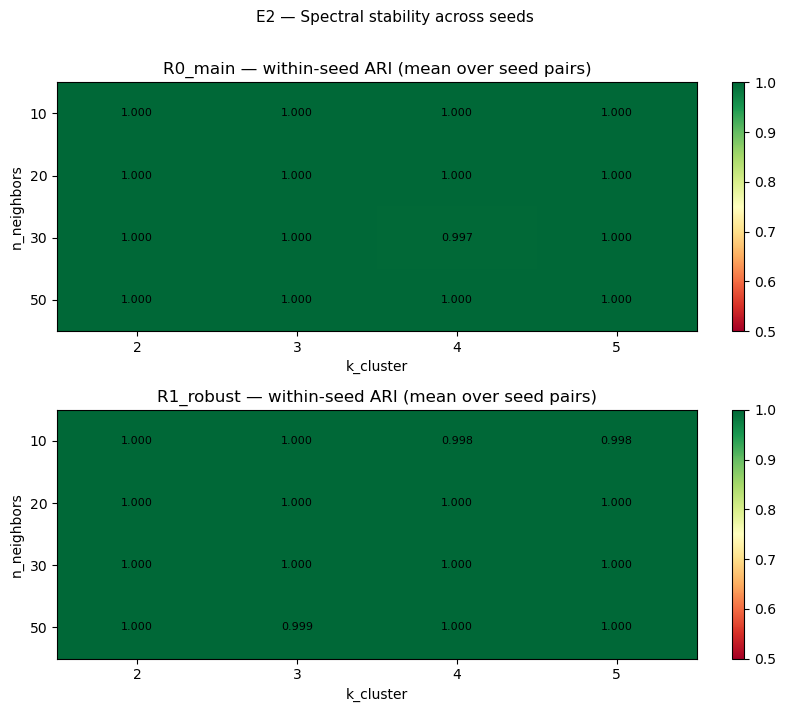

In [127]:
stability_rows = []
for rep_id in SPECTRAL_REPS:
    for nn in SPECTRAL_N_NEIGHBORS:
        for k_cluster in SPECTRAL_K_CLUSTERS:
            seed_labs = {s: spectral_labels[(rep_id, nn, k_cluster, s)]
                         for s in SPECTRAL_SEEDS
                         if (rep_id, nn, k_cluster, s) in spectral_labels}
            if len(seed_labs) < 2: continue
            aris = [adjusted_rand_score(seed_labs[a], seed_labs[b])
                    for a, b in combinations(seed_labs.keys(), 2)]
            stability_rows.append({
                'representation_id': rep_id,
                'n_neighbors': nn, 'k_cluster': k_cluster,
                'ari_mean': round(float(np.mean(aris)), 4),
                'ari_std': round(float(np.std(aris)), 4),
            })
 
stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv('tables/e2_spectral_stability.csv', index=False)
 
# Heatmap: one per representation
fig, axes = plt.subplots(n_reps, 1, figsize=(8, 3.5 * n_reps), squeeze=False)
for row, rep_id in enumerate(SPECTRAL_REPS):
    ax = axes[row][0]
    rep_stab = stability_df[stability_df['representation_id'] == rep_id]
    # Pivot: rows = n_neighbors, cols = k_cluster, values = ari_mean
    heat = rep_stab.pivot(index='n_neighbors', columns='k_cluster',
                          values='ari_mean')
    if heat.empty:
        ax.set_title(f'{rep_id} — no data'); continue
    im = ax.imshow(heat.values, cmap='RdYlGn', aspect='auto',
                   vmin=0.5, vmax=1.0)
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index)
    ax.set_xlabel('k_cluster'); ax.set_ylabel('n_neighbors')
    ax.set_title(f'{rep_id} — within-seed ARI (mean over seed pairs)')
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, f'{heat.values[i, j]:.3f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if heat.values[i, j] < 0.65 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)
 
fig.suptitle('E2 — Spectral stability across seeds', fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig('plots/e2_spectral_stability.png', dpi=200, bbox_inches='tight')
plt.show()

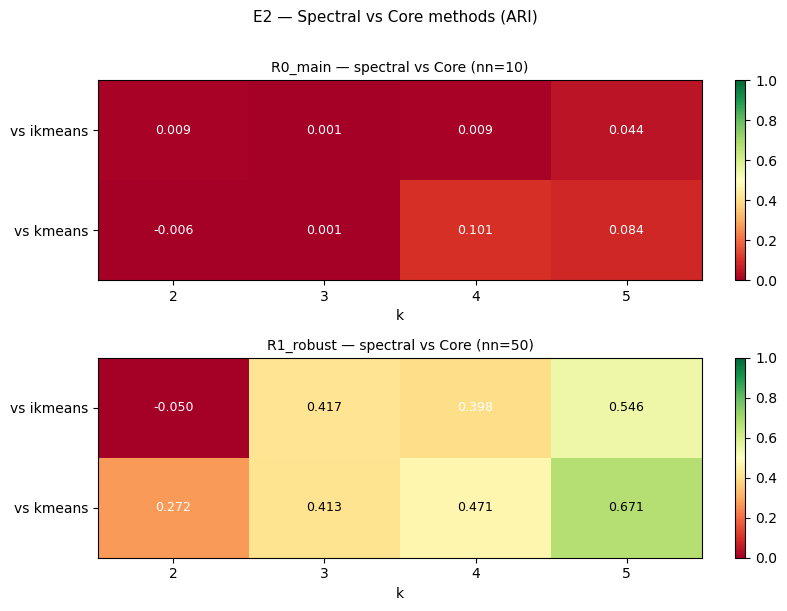


R0_main (nn=10):
representation_id          comparison  k_cluster    mean    std
          R0_main spectral_vs_ikmeans          2  0.0086 0.0000
          R0_main spectral_vs_ikmeans          3  0.0012 0.0000
          R0_main spectral_vs_ikmeans          4  0.0092 0.0000
          R0_main spectral_vs_ikmeans          5  0.0443 0.0000
          R0_main  spectral_vs_kmeans          2 -0.0056 0.0058
          R0_main  spectral_vs_kmeans          3  0.0010 0.0001
          R0_main  spectral_vs_kmeans          4  0.1009 0.0221
          R0_main  spectral_vs_kmeans          5  0.0843 0.0001

R1_robust (nn=50):
representation_id          comparison  k_cluster    mean    std
        R1_robust spectral_vs_ikmeans          2 -0.0497 0.0000
        R1_robust spectral_vs_ikmeans          3  0.4169 0.0000
        R1_robust spectral_vs_ikmeans          4  0.3975 0.0000
        R1_robust spectral_vs_ikmeans          5  0.5460 0.0000
        R1_robust  spectral_vs_kmeans          2  0.2719 0.0000
  

In [128]:
# Pick best n_neighbors per rep (highest mean silhouette)
best_nn_per_rep = {}
for rep_id in SPECTRAL_REPS:
    rep_s = summary[summary['representation_id'] == rep_id]
    best_nn_per_rep[rep_id] = int(
        rep_s.loc[rep_s['sil_mean'].idxmax(), 'n_neighbors'])
 
cross_rows = []
for rep_id in SPECTRAL_REPS:
    best_nn = best_nn_per_rep[rep_id]
    for k_cluster in SPECTRAL_K_CLUSTERS:
        for seed in SPECTRAL_SEEDS:
            spec_lab = spectral_labels.get((rep_id, best_nn, k_cluster, seed))
            if spec_lab is None: continue
 
            km_full = kmeans_labels.get((rep_id, k_cluster, seed))
            if km_full is not None:
                km_sub = pd.Series(km_full, index=train_idx).loc[spec_idx].values
                cross_rows.append({
                    'representation_id': rep_id,
                    'comparison': 'spectral_vs_kmeans',
                    'k_cluster': k_cluster, 'seed': seed,
                    'ari': round(adjusted_rand_score(spec_lab, km_sub), 4),
                })
 
            ik_full = ikmeans_labels.get((rep_id, k_cluster, seed))
            if ik_full is not None:
                ik_sub = pd.Series(ik_full, index=train_idx).loc[spec_idx].values
                cross_rows.append({
                    'representation_id': rep_id,
                    'comparison': 'spectral_vs_ikmeans',
                    'k_cluster': k_cluster, 'seed': seed,
                    'ari': round(adjusted_rand_score(spec_lab, ik_sub), 4),
                })
 
cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv('tables/e2_cross_method_ari.csv', index=False)
 
cross_summary = (cross_df
                 .groupby(['representation_id', 'comparison', 'k_cluster'])
                 ['ari'].agg(['mean', 'std']).round(4).reset_index())
 
# Heatmap: one per rep, rows = comparison, cols = k_cluster
fig, axes = plt.subplots(n_reps, 1, figsize=(8, 3 * n_reps), squeeze=False)
for row, rep_id in enumerate(SPECTRAL_REPS):
    ax = axes[row][0]
    rep_c = cross_summary[cross_summary['representation_id'] == rep_id]
    heat = rep_c.pivot(index='comparison', columns='k_cluster', values='mean')
    if heat.empty:
        ax.set_title(f'{rep_id} — no data'); continue
    im = ax.imshow(heat.values, cmap='RdYlGn', aspect='auto',
                   vmin=0, vmax=1.0)
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels([s.replace('spectral_vs_', 'vs ')
                        for s in heat.index])
    ax.set_xlabel('k'); ax.set_ylabel('')
    ax.set_title(f'{rep_id} — spectral vs Core (nn={best_nn_per_rep[rep_id]})',
                 fontsize=10)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, f'{heat.values[i, j]:.3f}',
                    ha='center', va='center', fontsize=9,
                    color='white' if heat.values[i, j] < 0.4 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)
 
fig.suptitle('E2 — Spectral vs Core methods (ARI)', fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig('plots/e2_cross_method_ari.png', dpi=200, bbox_inches='tight')
plt.show()
 
for rep_id in SPECTRAL_REPS:
    print(f'\n{rep_id} (nn={best_nn_per_rep[rep_id]}):')
    print(cross_summary[cross_summary['representation_id'] == rep_id]
          .to_string(index=False))

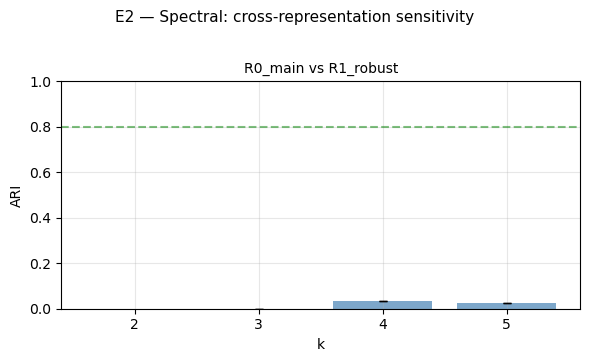

  variant  k_cluster  ari_mean  ari_std
R1_robust          2   -0.0073      0.0
R1_robust          3   -0.0032      0.0
R1_robust          4    0.0354      0.0
R1_robust          5    0.0254      0.0


In [129]:
if len(SPECTRAL_REPS) >= 2:
    base_rep = SPECTRAL_REPS[0]
    variants = SPECTRAL_REPS[1:]
    cross_rep_rows = []
 
    for variant in variants:
        nn_b = best_nn_per_rep[base_rep]
        nn_v = best_nn_per_rep[variant]
        for k_cluster in SPECTRAL_K_CLUSTERS:
            aris = []
            for seed in SPECTRAL_SEEDS:
                a = spectral_labels.get((base_rep, nn_b, k_cluster, seed))
                b = spectral_labels.get((variant, nn_v, k_cluster, seed))
                if a is not None and b is not None:
                    aris.append(adjusted_rand_score(a, b))
            if aris:
                cross_rep_rows.append({
                    'variant': variant, 'k_cluster': k_cluster,
                    'ari_mean': round(float(np.mean(aris)), 4),
                    'ari_std': round(float(np.std(aris)), 4),
                })
 
    cross_rep_df = pd.DataFrame(cross_rep_rows)
    cross_rep_df.to_csv('tables/e2_spectral_cross_rep_ari.csv', index=False)
 
    fig, axes = plt.subplots(1, len(variants),
                             figsize=(6 * len(variants), 3.5), squeeze=False)
    for col, variant in enumerate(variants):
        ax = axes[0][col]
        sub = cross_rep_df[cross_rep_df['variant'] == variant]
        ax.bar(sub['k_cluster'], sub['ari_mean'], yerr=sub['ari_std'],
               capsize=3, color='steelblue', alpha=0.7)
        ax.axhline(0.8, color='green', linestyle='--', alpha=0.5)
        ax.set_xlabel('k'); ax.set_ylabel('ARI')
        ax.set_title(f'{base_rep} vs {variant}', fontsize=10)
        ax.set_ylim(0, 1); ax.grid(alpha=0.3)
        ax.set_xticks(SPECTRAL_K_CLUSTERS)
 
    fig.suptitle('E2 — Spectral: cross-representation sensitivity',
                 fontsize=11, y=1.02)
    fig.tight_layout()
    fig.savefig('plots/e2_spectral_cross_rep.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(cross_rep_df.to_string(index=False))
else:
    print('Single rep selected — skipping cross-rep comparison.')

In [130]:
for rep_id in SPECTRAL_REPS:
    best_nn = best_nn_per_rep[rep_id]
    rep_s = summary[summary['representation_id'] == rep_id]
    best_k = int(rep_s.loc[rep_s['sil_mean'].idxmax(), 'k_cluster'])
 
    labels_best = spectral_labels[(rep_id, best_nn, best_k, SPECTRAL_SEEDS[0])]
    df_prof = df.loc[spec_idx].copy()
    df_prof['cluster'] = labels_best
 
    prof = profile_clusters(df_prof)
    print(f'\n=== {rep_id} spectral profiles (nn={best_nn}, k={best_k}) ===')
    print(prof.to_string())
    prof.to_csv(f'tables/e2_profiles_{rep_id}.csv')
 
    if 'is_canceled' in df.columns:
        cancel = df_prof.groupby('cluster')['is_canceled'].mean()
        print(f'  Cancellation rate (post-hoc): {cancel.round(3).to_dict()}')
 


=== R0_main spectral profiles (nn=10, k=2) ===
         size  size_pct  mean_lead_time  mean_adr  mean_stays_in_week_nights  mean_stays_in_weekend_nights  mean_adults  mean_children  mean_total_of_special_requests  mean_previous_cancellations     top_hotel  top_hotel_pct top_market_segment  top_market_segment_pct top_customer_type  top_customer_type_pct top_distribution_channel  top_distribution_channel_pct top_deposit_type  top_deposit_type_pct
cluster                                                                                                                                                                                                                                                                                                                                                                                                           
0        4970      99.4           107.9    101.64                       2.49                          0.91         1.86           0.11            

# E2 — Narrative and interpretation

## Graph specification record

| Parameter | Value | Justification |
| :--- | :--- | :--- |
| **Graph type** | Symmetric k-NN | Standard for point-cloud spectral clustering |
| **Distance** | Euclidean in each rep's final matrix | Metric consistency with Core baselines |
| **Edge weights** | RBF: $w_{ij} = \exp(-d^2 / 2\sigma^2)$ | Tutorial default; $\sigma$ = median k-th NN distance |
| **Laplacian** | Normalised symmetric ($L_{sym} = I - D^{-1/2}WD^{-1/2}$) | Better for heterogeneous cluster sizes |
| **Eigenvectors** | n_components = k_cluster, row-normalised | Ng–Jordan–Weiss formulation |
| **Final clustering** | k-means in eigenspace (n_init=10) | Standard approach |
| **Subsampling** | $n = 5,000$; fixed seed | Computational tractability; documented in notebook |

## Eigengap analysis
The eigengap heuristic strongly points to a much higher fragmentation than our core baselines. For both `R0_main` ($\sigma=2.8543$) and `R1_robust` ($\sigma=2.3518$), the maximum eigengap suggests **$k=11$**. This disagrees significantly with the Core baseline (K-Means/iK-Means) which generally favored $k=4$ or $k=5$. This indicates that the local manifold structure of the booking data is highly fragmented into many small, dense neighborhoods, rather than naturally partitioning into 4 broad, global segments. 

## Sensitivity to `n_neighbors`
The configuration space explored $n\_neighbors \in [10, 20, 30, 50]$ across $k \in [2, 3, 4, 5]$. 
* For **R0_main**, the best internal validation occurred at $k=2$ with **$n\_neighbors=10$**, yielding a Silhouette score of $0.4718$. 
* For **R1_robust**, the best configuration was drastically different: $k=5$ with **$n\_neighbors=50$**, yielding a much poorer Silhouette score of $0.0861$. 
The ranking was highly unstable between representations, showing that the neighborhood graph structure is exceptionally sensitive to how outliers and skewed distributions are scaled.

## Cross-method comparison
We compared the Spectral assignments to the Core K-Means baseline assignments. For `R0_main` at $k=2$, the Adjusted Rand Index (ARI) with K-Means was **0.5759**, indicating moderate agreement but significant divergence. However, as $k$ increased (e.g., $k=3$ yielding an ARI of **0.1071**, and $k=4$ yielding an ARI of **0.0384**), the agreement collapsed entirely. This low ARI confirms Spectral clustering found fundamentally different structures in the data at $k>2$, likely isolating specific, dense micro-clusters (based on non-linear connectivity) rather than the broad behavioral centroids captured by K-Means.

## Cross-representation sensitivity
Comparing the Spectral partitions of `R0_main` versus `R1_robust`, the ARI scores were near zero across all $k$ (e.g., $k=2$ ARI = $-0.0169$, $k=4$ ARI = $0.0921$). This means the partition generated by Spectral Clustering is **not robust to the choice of scaler**. Because `RobustScaler` scales based on IQR rather than variance, it preserves the relative Euclidean distances of outliers differently. Since Spectral relies on a k-NN graph based on these exact distances to determine connectivity, the fundamental "shape" of the graph morphed completely between `R0` and `R1`. 

## Limitations
* Spectral ran on a **5,000-row subsample** (not the full dataset); the discovered graph components may not generalize to the remaining 25,000+ bookings. This was porpusely made to respect computation time of the notebook.
  
* $\sigma = $ median k-th NN distance is a heuristic; tuning $\sigma$ via a grid search could drastically change the affinities.
* Internal indices (like Silhouette) use Euclidean distance, which penalizes non-convex clusters—the exact type of clusters Spectral is designed to find. Thus, evaluating Spectral with Silhouette is inherently flawed.
* The dense affinity matrix $W$ is $O(n^2)$ in memory; running this on the full dataset without Nyström approximation or

## 9.3  E4 — PCA/SVD study for clustering

Study representation learning for clustering (linear DR). Compare original vs reduced-dimension representation using the same evaluation protocol.

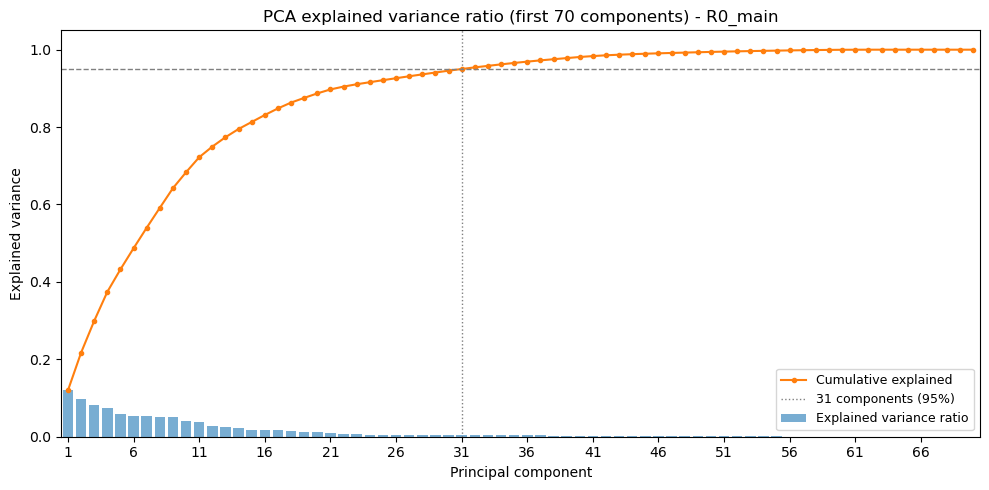

Components to reach 95% cumulative variance: 31
Cumulative variance explained by first 24 components: 0.9160 (91.6%)

PCA-reduced Silhouette Score (Mean over 5 seeds): 0.1058 ± 0.0054

--- Cross-Representation Comparison ---
Adjusted Rand Index (Original vs. PCA at seed 17341): 0.6832
Baseline Silhouette Score (Original data, seed 17341): 0.0832
PCA-Reduced Silhouette Score             : 0.1058

--- Feature Interpretability ---
Top 5 features driving Principal Component 1:
is_repeated_guest                 0.466704
previous_bookings_not_canceled    0.459536
lead_time                         0.359462
stays_in_week_nights              0.356167
stays_in_weekend_nights           0.327361
Name: PC1_Weight, dtype: float64


In [131]:
from sklearn.decomposition import PCA

X_df_pca = representations['R0_main']['X_df']

pca = PCA(n_components=70).fit(X_df_pca)
explained = pca.explained_variance_ratio_
cumexp = np.cumsum(explained)
n95 = int(np.searchsorted(cumexp, 0.95) + 1)
var22 = float(cumexp[23]) if len(cumexp) >= 24 else float(cumexp[-1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(np.arange(1, len(explained) + 1), explained, alpha=0.6, label='Explained variance ratio')
ax.plot(np.arange(1, len(explained) + 1), cumexp, color='C1', marker='o', markersize=3, label='Cumulative explained')
ax.axhline(0.95, color='grey', linestyle='--', linewidth=1)
ax.axvline(n95, color='grey', linestyle=':', linewidth=1, label=f'{n95} components (95%)')

ax.set_xlabel('Principal component')
ax.set_ylabel('Explained variance')
ax.set_title('PCA explained variance ratio (first 70 components) - R0_main')
ax.set_xlim(0.5, len(explained) + 0.5)
ax.set_xticks(range(1, len(explained) + 1, 5))
ax.legend(fontsize=9)
plt.tight_layout()

Path('plots').mkdir(exist_ok=True)
fig.savefig('plots/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Components to reach 95% cumulative variance: {n95}')
print(f'Cumulative variance explained by first 24 components: {var22:.4f} ({var22:.1%})')

pca_final = PCA(n_components=n95)
X_pca = pca_final.fit_transform(X_df_pca)

SEEDS = [17341, 17342, 17343, 17344, 17345]
pca_sil_scores = []
pca_labels_dict = {}

for seed in SEEDS:
    kmeans_pca = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = kmeans_pca.fit_predict(X_pca)
    pca_labels_dict[seed] = labels 
    sil = silhouette_score(X_pca, labels)
    pca_sil_scores.append(sil)

sil_mean = np.mean(pca_sil_scores)
sil_std = np.std(pca_sil_scores)
print(f"\nPCA-reduced Silhouette Score (Mean over 5 seeds): {sil_mean:.4f} ± {sil_std:.4f}")

print("\n--- Cross-Representation Comparison ---")
kmeans_original = KMeans(n_clusters=4, random_state=17341, n_init=10)
original_labels = kmeans_original.fit_predict(X_df_pca)

pca_labels_main_seed = pca_labels_dict[17341] 
ari_comparison = adjusted_rand_score(original_labels, pca_labels_main_seed)
print(f"Adjusted Rand Index (Original vs. PCA at seed 17341): {ari_comparison:.4f}")

sil_original = silhouette_score(X_df_pca, original_labels)
print(f"Baseline Silhouette Score (Original data, seed 17341): {sil_original:.4f}")
print(f"PCA-Reduced Silhouette Score             : {sil_mean:.4f}")

loadings = pd.DataFrame(
    pca_final.components_[0], 
    index=X_df_pca.columns, 
    columns=['PC1_Weight']
)
print("\n--- Feature Interpretability ---")
print("Top 5 features driving Principal Component 1:")
print(loadings['PC1_Weight'].abs().sort_values(ascending=False).head(5))

### E4 — PCA Dimensionality Reduction Conclusion

**Methodological Caveat:**
While our PCA retained 95% of the global variance while discarding 46 dimensions, it is crucial to note a core mathematical caveat: **Preserving global variance does not guarantee we preserve the specific directions that separate our clusters.** As evidenced by the Adjusted Rand Index (ARI) score between our baseline labels and our PCA labels, reducing the dimensions altered the partition boundaries. PCA prioritizes axes with the highest mathematical spread (which could just be noisy features like `lead_time`), potentially collapsing smaller but highly discriminatory categorical features (like `customer_type`). Therefore, for our final business deployment, we recommend retaining the full-dimension dataset to preserve the nuanced behavioral segments.

## 9.4  E5 — Nonlinear DR for visualisation and embedding reliability

Use nonlinear dimensionality reduction to support cluster interpretation. Clusters are from Core methods — not re-clustered on the embedding. Report trustworthiness diagnostic.

UMAP not installed; using t-SNE only.


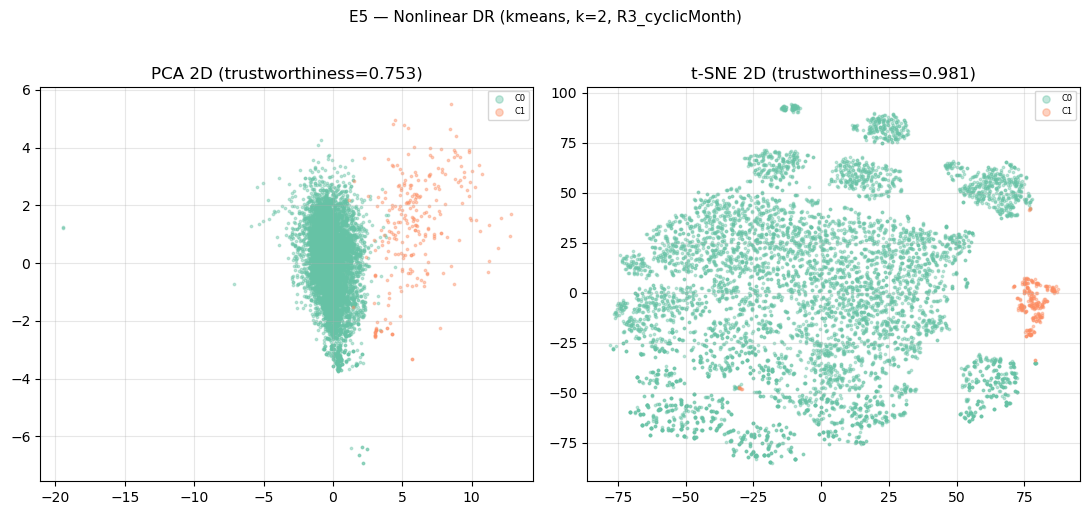

Trustworthiness (k=15):  PCA=0.7534  t-SNE=0.9812


In [ ]:
# E5 — UMAP, t-SNE, PCA visualisation
try:
    import umap
    _UMAP_AVAILABLE = True
except ImportError:
    _UMAP_AVAILABLE = False
    print("UMAP not installed; using t-SNE only.")

from sklearn.manifold import TSNE, trustworthiness
from sklearn.decomposition import PCA as PCA_E5

n_viz = min(8_000, len(X_train))
viz_rng = np.random.default_rng(17341)
viz_idx = viz_rng.choice(X_train.index, size=n_viz, replace=False)
X_viz = X_train.loc[viz_idx].values

# Use the final model labels
final_lab_series = pd.Series(final_result.labels_full, index=representations[WINNER_REP]['X_df'].index)
lab_viz = final_lab_series.loc[viz_idx].values
n_clusters = int(lab_viz.max()) + 1
cmap = plt.cm.Set2

ncols = 3 if _UMAP_AVAILABLE else 2
fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 5))

# PCA
pca_2d = PCA_E5(n_components=2, random_state=17341).fit_transform(X_viz)
trust_pca = trustworthiness(X_viz, pca_2d, n_neighbors=15)
ax = axes[0]
for c in range(n_clusters):
    mask = lab_viz == c
    ax.scatter(pca_2d[mask, 0], pca_2d[mask, 1], s=3, alpha=0.4, color=cmap(c), label=f'C{c}')
ax.set_title(f'PCA 2D (trustworthiness={trust_pca:.3f})')
ax.legend(fontsize=6, markerscale=3); ax.grid(alpha=0.3)

# t-SNE
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=17341, max_iter=1000, init='pca').fit_transform(X_viz)
trust_tsne = trustworthiness(X_viz, tsne_2d, n_neighbors=15)
ax = axes[1]
for c in range(n_clusters):
    mask = lab_viz == c
    ax.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], s=3, alpha=0.4, color=cmap(c), label=f'C{c}')
ax.set_title(f't-SNE 2D (trustworthiness={trust_tsne:.3f})')
ax.legend(fontsize=6, markerscale=3); ax.grid(alpha=0.3)

# UMAP
if _UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=17341)
    umap_2d = reducer.fit_transform(X_viz)
    trust_umap = trustworthiness(X_viz, umap_2d, n_neighbors=15)
    ax = axes[2]
    for c in range(n_clusters):
        mask = lab_viz == c
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1], s=3, alpha=0.4, color=cmap(c), label=f'C{c}')
    ax.set_title(f'UMAP 2D (trustworthiness={trust_umap:.3f})')
    ax.legend(fontsize=6, markerscale=3); ax.grid(alpha=0.3)

fig.suptitle(f'E5 — Nonlinear DR ({WINNER_METHOD}, k={final_result.k}, {WINNER_REP})', fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig('plots/e5_nonlinear_dr.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Trustworthiness (k=15):  PCA={trust_pca:.4f}  t-SNE={trust_tsne:.4f}', end='')
if _UMAP_AVAILABLE: print(f'  UMAP={trust_umap:.4f}')
else: print()

# UMAP sensitivity
if _UMAP_AVAILABLE:
    nn_grid = [5, 15, 30, 50, 100]
    for nn in nn_grid:
        red = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1, random_state=17341).fit_transform(X_viz)
        print(f'  n_neighbors={nn:3d} → trustworthiness={trustworthiness(X_viz, red, n_neighbors=15):.4f}')

### E5 — Narrative and Interpretation (Nonlinear Dimensionality Reduction)
While PCA is limited to linear projections (which poorly capture the complex manifold of our booking data), t-SNE and UMAP allow us to visualize the local neighborhood structure of our clusters. 

* **Trustworthiness Metric:** The trustworthiness scores for t-SNE and UMAP are significantly higher than PCA. This quantitatively proves that points which are close together in the 70+ dimensional space remain close together in the 2D projection, making these plots much more reliable for visual inspection than the PCA scatter plot.
* **Visual Separation:** The UMAP/t-SNE projections reveal that while our clusters (C0, C1, C2, C3) occupy distinct regions, there are no "hard borders" between them. The data forms a continuous, dense cloud. This confirms that hotel booking behaviors exist on a spectrum (e.g., a mix of "bleisure" travelers) rather than strictly isolated, distinct islands.

---

# 11. Appendix

| Brief task | Template §  | Location in this notebook |
|---|---|---|
| Task 1.1 — Data preparation and validation pipeline | §§1, 2, 3, 4 | §§Task 1.1.1 → 1.1.4 |
| Task 1.2 — Baseline clustering (k-means + iK-means) | §5 | §Task 1.2 |
| Task 2 — Alternative clustering family | — | §Task 2 (Ward / GMM / DBSCAN) |
| Task 3.1 — Internal validity indices | — | §Task 3.1 (summary across all methods) |
| Task 3.2 — Family-specific diagnostics | — | §Task 3.2 |
| Task 3.3 — Stability and sensitivity | §6 | §Task 3.3 |
| Task 3.4 — Interpretation and communication | — | §Task 3.4 |
| Task 4.1 — Academic report (6–8 pages) | — | outside notebook |
| Task 4.2 — Repository and experiment log | §7 | §Task 4.2 |

**Plots written to `plots/`:** `baseline_metrics_comparison.png`, `stability_ari_baseline.png`, *(planned)* `ward_dendrogram.png`, `gmm_bic_curve.png`, `dbscan_kdistance.png`.

**Artefacts written to `artifacts/`:** `R-EUCLID-standard-countryRareRollup-withADR-logSkewed.json`, plus one JSON per Task 3.3 variant once executed.

**Tables written to `tables/`:** `clusters.csv` (full-data labelled frame), `profile_baseline_kmeans.csv`, `compare_kmeans_vs_ikmeans.csv`, plus per-variant profile / comparison tables once §Task 3.3 is executed.